> **Primary analysis is temporal (Parts 6b, 6c, 7 and the H2 temporal section).** Each run is split
> into an Early snapshot (simulation days 1–2) and a Late snapshot (days 4–5); Day 3 is kept out of
> the comparison. Agent attitudes, agent embeddings and the interaction graph are rebuilt inside each
> window, every component gets its own window-specific null, and the run-level change
> Δ = Late − Early carries the emergence question. The full-run analysis below (Parts 6, 7b, 8 and the
> full-run H2 tests) is kept as descriptive context and robustness. It averages over the whole run
> and cannot show when structure appeared.

# H1: Dose-response of stance priors on echo chamber intensity

**Hypothesis:** Echo chamber intensity increases with the extremity of the injected stance prior
(none < moderate < extreme). With no stance prior, the components should not exceed a
permutation-null level.

**batchA design:** 6 runs = 2 seeds × {none, moderate, extreme}, all-llama, everything else held constant.

## Measurement: a component vector, reported separately

No weighted composite. A composite assumes its components are interchangeable indicators of one
latent construct, which you cannot test with this number of runs, and any weighting (the original
0.3/0.3/0.2/0.2, or per-run PCA, which refits different loadings per seed and so yields scores that
aren't comparable across runs) buries the divergences worth reporting.

| | Component | Definition | Bounded on | Temporal testing role |
|---|---|---|---|---|
| **P** | Polarization | Variance (or Sarle's bimodality coefficient) of agent mean attitude | [0, 1] | primary |
| **S** | Separation | Louvain modularity *Q* of the **weighted** interaction graph | [0, 1] after clipping | primary |
| **N** | NCI | Mean local semantic alignment, rescaled from [−1, 1] | [0, 1] | primary |
| **NC** | Neighbors correlation | Pearson r between agent attitude and mean neighbour attitude, rescaled | [0, 1] | primary |
| **D** | Inverted diversity | 1 − mean neighborhood attitude std | [0, 1] | secondary |

D is secondary because it is not normalized by the spread of attitudes: as camps separate,
neighbourhood SD rises mechanically, so raw D can fall while homophily grows, and an ordered
prediction on ΔD is not theoretically clean. NC, being a correlation, is self-normalizing and takes
its place in the primary family. D is still computed, null-tested and reported, in its own BH family.

Each is bounded on [0, 1] **by construction** given attitudes on [−1, 1], not by a chosen
normalizing constant. The redundancy is resolved by substrate: **D** is neighborhood similarity in
*attitude* space, **N** in *semantic embedding* space, **S** is topology alone. A correlation matrix
is printed in Part 8 so you can report the overlap rather than assume independence.

## Three cross-run comparability fixes

Everything below exists because H1 compares *across runs*, and the original pipeline had three
places where a quantity was defined relative to each run's own data. Any one of them would let a
"difference between conditions" be an artifact of the instrument.

**1. Anchor-based prototypes (replaces data-derived prototypes).** The original Step 4 built the
pro/anti prototypes by averaging embeddings of tweets with `roberta_compound` above/below ±0.3.
That is per-run (so the stance axis differs run to run) and it defines *stance* using *sentiment*,
conflating two things the pipeline otherwise treats as separate. Prototypes are now built by
embedding the `PRO_ANCHORS` / `ANTI_ANCHORS` sentences directly. Fixed, external, identical across
every run, model, and seed, and stance no longer borrows its definition from sentiment. This also
makes the old `compute_shared_prototypes()` helper unnecessary; it's gone.

**2. Global normalization (replaces per-run MinMaxScaler).** Fixed anchors alone don't finish the
job. The original fits `MinMaxScaler` *per run*, mapping each run's own min to −1 and max to +1, so
every run's stance distribution gets stretched to fill the same range regardless of how polarized it
actually was. That directly suppresses the between-condition variance differences H1 is trying to
detect. Scoring is therefore split into two passes: raw features are extracted per run and cached,
then **one** scaler is fitted on all runs pooled and applied to every run. If you'd rather skip
rescaling entirely, set `USE_GLOBAL_SCALING = False`; `tanh` in the attitude score already bounds
the output.

**3. Weighted graph throughout.** `build_graph` accumulates interaction counts as edge weights, and
`community_louvain` uses `weight='weight'` by default, so S was computed on a weighted graph. But
the edge list was persisted without weights, so the reloaded graph used for the null test was
unweighted, and the observed S in the null table didn't match the observed S in the component table.
Weights are now persisted and reloaded. Two related bugs are fixed alongside it:
`DiGraph.to_undirected()` *overwrites* reciprocal edge weights instead of summing them (a↔b with 3
and 7 gives 7, not 10), and `nx.double_edge_swap` **drops the weight attribute** on every edge it
rewires, which would have left the null graph nearly unweighted while the observed graph was
weighted. The rewiring null now reassigns the original weight multiset after swapping.

## Statistical approach

Three kinds of evidence are kept apart, and each has its own test:

| Evidence | Question | Test | Unit |
|---|---|---|---|
| A. Emergence | Is X higher in Days 4–5 than in Days 1–2? | exact paired sign-flip on Δ = Late − Early | run |
| B. Non-randomness | Is X above its window's randomized null? | component-specific permutation null, Early and Late separately | snapshot |
| C. Condition-dependent emergence | Is Δ ordered none < moderate < extreme? | Jonckheere-Terpstra on Δ | run |

"High", "above the null", "increased from Early to Late" and "increased more under extreme priors"
are different findings and are reported separately.

- **BH-FDR families** are listed by the notebook in `temporal_testing_families.csv`. Within a family,
  BH is applied separately to the primary components (P, S, N, NC) and to the secondary component (D).
  Null-test p-values are never pooled with JT or sign-flip p-values; they only feed descriptive labels.
- **`scipy.stats.jonckheere` does not exist** in any scipy version, including 1.17. This notebook uses
  its own implementation: exact enumeration when the design has at most `MAX_EXACT_RELABELINGS`
  (2,000,000) size-preserving relabelings, otherwise `N_MONTE_CARLO` (200,000) random relabelings.
  The normal approximation is never used. H1 has 5 seeds per condition, giving 756,756 relabelings,
  so its p-values are exact.
- **Sign-flip floor:** with 5 runs per condition the smallest paired p is 1/32 ≈ 0.031.
- The full-run tests (Parts 7b and 8, and the full-run H2 test) are unchanged robustness checks and
  still apply BH across all five components.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup

Same dependencies as your original notebook.

H3c's POS, dependency and clause-complexity families need spaCy:

```
!pip install spacy
!python -m spacy download en_core_web_sm
```

If it isn't available the notebook still runs; those three families are skipped and the ablation reports the remaining ones.


In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 97.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import skew, kurtosis, entropy, rankdata, kruskal, chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import community.community_louvain as community_louvain
import seaborn as sns
from sentence_transformers import SentenceTransformer, CrossEncoder
from tqdm.auto import tqdm
import warnings
import re
import json
from pathlib import Path
from itertools import combinations
warnings.filterwarnings('ignore')

print("Libraries imported.")


Libraries imported.


## Configuration

All runs used by **any** hypothesis are listed together, because the global scaler must be fitted
across every run that will ever be compared. Fitting it on batchA alone and then applying it to
batchB would put the two batches on different footings, which is exactly the problem the global
scaler exists to prevent.

Each hypothesis then selects its own subset:

- **H1** — batchA, llama only, stance varies (none / moderate / extreme).
- **H2** — homogeneous runs at *moderate* stance, model varies (llama / deepseek / gemma). The llama
  arm is batchA's moderate runs, reused; batchB supplies the other two.

`n_agents_configured` is needed for the participation rate, which is H2's gating diagnostic. Set it
to whatever `population size` each run was configured with (100 in the standard configs).


In [ ]:
# Same discovery logic as the extraction pipeline (1_EDA / 2_Sentiment / batch
# runner notebook): scan BASE_EXPERIMENTS_DIR for seed folders, parse
# batch/model/condition/seed from the folder name, and only include a run if
# that pipeline has actually produced its sentiment_results.csv for it. This
# replaces the hand-written BATCH_SPEC / dir_fmt table -- no per-run path to
# maintain, and a seed that hasn't been processed yet (or came back empty,
# e.g. a participation failure) is skipped with a clear reason instead of
# silently entering the analysis as a missing-file error three cells later.
#
# The agents roster is read straight from the simulation's own agents JSON
# (no separate agents.csv conversion step) -- see load_agents_table() below.

BASE_EXPERIMENTS_DIR = '/content/drive/MyDrive/thesis/Experiments'   # same folder the extraction pipeline writes into

SEED_DIR_PATTERN = re.compile(
    r"^\d+\s*-\s*(?P<full>(?P<batch>batch[A-Za-z0-9]+)_(?P<model>[A-Za-z0-9]+)"
    r"_(?P<condition>[A-Za-z0-9]+)_seed(?P<seed>\d+))$"
)


def discover_seed_dirs(base_dir):
    """Folders that don't match the naming pattern are skipped here (unlike the
    extraction pipeline, which still processes them with blank metadata) --
    a run can't be placed into H1/H2/H3 without a parsed batch/model/condition/seed,
    so there's nothing useful this notebook can do with one."""
    base = Path(base_dir)
    if not base.exists():
        raise FileNotFoundError(f"Experiments base directory not found: {base_dir}")
    seeds = []
    for entry in sorted(base.iterdir()):
        if not entry.is_dir():
            continue
        m = SEED_DIR_PATTERN.match(entry.name)
        if not m:
            continue
        agent_candidates = sorted(entry.glob("*_agents.json"))
        seeds.append({"name": entry.name, "path": entry,
                       "agents_path": agent_candidates[0] if agent_candidates else None,
                       **m.groupdict()})
    return seeds


from collections import Counter as Counter_

N_AGENTS_CONFIGURED = 100   # shared assumption across runs; the real per-run roster size is in the agents JSON if you'd rather use that

_discovered = discover_seed_dirs(BASE_EXPERIMENTS_DIR)

# run_id must be unique across every discovered folder, because it is also the cache
# folder name: two runs sharing an id would overwrite each other's cached features and
# silently collapse into one. Which fields are needed to make it unique depends on what
# actually varies within a batch, so it is derived from the discovered folders rather
# than assumed. batchC in particular varies BOTH model composition and stance
# condition, so naming it by model and seed alone would collide across the two stance
# arms.
_varies = {}
for _b in {d["batch"] for d in _discovered}:
    _in_batch = [d for d in _discovered if d["batch"] == _b]
    _varies[_b] = {'model': len({d["model"] for d in _in_batch}) > 1,
                   'condition': len({d["condition"] for d in _in_batch}) > 1}


def _make_run_id(d):
    batch_letter = d["batch"].replace("batch", "") if d["batch"] else None
    v = _varies.get(d["batch"], {'model': True, 'condition': True})
    parts = [f"batch{batch_letter}"]
    if v['model'] or batch_letter != 'A':
        parts.append(d["model"])
    if v['condition'] or batch_letter == 'A':
        parts.append(d["condition"])
    parts.append(f"seed{d['seed']}")
    return "_".join(parts)


ALL_RUN_CONFIGS = []
skipped = []
for s in _discovered:
    csv_dir = s["path"] / "csv"
    batch_letter = s["batch"].replace("batch", "") if s["batch"] else None
    run_id = _make_run_id(s)

    if not (csv_dir / "sentiment_results.csv").exists():
        skipped.append((s["name"], "sentiment_results.csv not found -- run the extraction "
                                    "pipeline for this seed first"))
        continue
    if s["agents_path"] is None:
        skipped.append((s["name"], "no *_agents.json found in this seed folder -- "
                                    "participation-denominator analyses will be unavailable"))
        # not fatal: extract_raw_features_for_run only needs sentiment_results.csv,
        # so still include the run; load_agents_table() will just return None for it.

    ALL_RUN_CONFIGS.append({
        'run_id': run_id, 'seed': int(s['seed']), 'batch': batch_letter, 'model': s['model'],
        'stance_condition': s['condition'], 'n_agents_configured': N_AGENTS_CONFIGURED,
        'run_dir': str(csv_dir),
        'agents_path': str(s['agents_path']) if s['agents_path'] else None})

_dupes = [rid for rid, n in Counter_(c['run_id'] for c in ALL_RUN_CONFIGS).items() if n > 1]
if _dupes:
    raise ValueError(
        f"run_id collision: {_dupes}. Two seed folders produced the same identifier, which "
        f"would make them share a cache folder. Check the folder naming under "
        f"{BASE_EXPERIMENTS_DIR}.")

if skipped:
    print(f"Notes on {len(skipped)} seed folder(s):")
    for name, reason in skipped:
        print(f"  - {name}: {reason}")
    print()

# ---- hypothesis subsets (same selection logic as before) ----
# H1: all of batchA. 5 seeds x 3 ordered stance levels.
H1_RUNS = [r for r in ALL_RUN_CONFIGS if r['batch'] == 'A']

# H2: model varies at moderate stance. The llama arm is drawn from batchA's moderate runs.
#
# H2_LLAMA_SEEDS controls how many of the 5 available llama seeds are used. Setting it to
# all five gives an UNBALANCED 5/3/3 design, which is not a compromise -- it is better.
# Kruskal-Wallis is invariant to which group receives which label only when groups are
# EQUALLY sized, so a balanced 3/3/3 design has all 3! = 6 label permutations tying the
# maximum H, giving an exact p-value floor of 6/1680 = 0.0036. With 5/3/3 only the two
# equal-sized groups are interchangeable, and the larger enumeration (9,240) puts the
# floor at 0.00065. More data and a lower floor, at no cost: KW handles unequal group
# sizes natively. Set to [1, 2, 3] if you would rather report a balanced design.
H2_LLAMA_SEEDS = [1, 2, 3, 4, 5]
H2_RUNS = ([r for r in ALL_RUN_CONFIGS
            if r['batch'] == 'A' and r['stance_condition'] == 'moderate'
            and r['seed'] in H2_LLAMA_SEEDS]
           + [r for r in ALL_RUN_CONFIGS if r['batch'] == 'B'])

STANCE_ORDER = ['none', 'moderate', 'extreme']   # H1: ORDERED (dose-response)
MODEL_ORDER = ['llama', 'deepseek', 'gemma']     # H2: unordered, display order only

# H3: mixed populations, across every stance arm present.
#
# The none-stance arm is better described as a CONTROL than as a second condition. With
# no stance prior injected there is no seeded disagreement for agents to sort on, so
# attitude-driven homophily has little to work with. Model assortativity appearing there
# is much harder to explain as a by-product of opinion sorting than the same finding
# under a moderate prior, and it is the closest this design comes to a clean test of
# H3's central claim.
H3_RUNS = [r for r in ALL_RUN_CONFIGS if r['batch'] == 'C']
H3_STANCE_ARMS = sorted({r['stance_condition'] for r in H3_RUNS},
                         key=lambda x: STANCE_ORDER.index(x) if x in STANCE_ORDER else 99)

MODEL_COLUMN = 'type'    # model column, in BOTH the posts table and the agents table

PERSONA_CATEGORICAL = ['leaning', 'education_level', 'gender', 'nationality', 'language', 'toxicity']
PERSONA_BIG_FIVE = ['oe', 'co', 'ex', 'ag', 'ne']
ACTIVITY_FIELDS = ['round_actions', 'daily_activity_level']
EXCLUDE_PAGES = True     # `is_page` agents are broadcast entities, not persona agents

SAVE_DIR = Path("/content/drive/MyDrive/thesis/code/")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RECOMPUTE = False   # True = ignore the cache and rescore everything

from collections import Counter
print(f"{len(ALL_RUN_CONFIGS)} runs discovered and ready for analysis.")
print(f"  H1: {len(H1_RUNS)} runs, "
      f"{dict(Counter(r['stance_condition'] for r in H1_RUNS))} (ordered)")
print(f"  H2: {len(H2_RUNS)} runs, {dict(Counter(r['model'] for r in H2_RUNS))} (unordered)")
print(f"  H3: {len(H3_RUNS)} runs, mixed populations across {H3_STANCE_ARMS} "
      f"({dict(Counter(r['stance_condition'] for r in H3_RUNS))})")
print(f"Results cache: {SAVE_DIR}")


29 runs discovered and ready for analysis.
  H1: 15 runs, {'none': 5, 'moderate': 5, 'extreme': 5} (ordered)
  H2: 11 runs, {'llama': 5, 'gemma': 3, 'deepseek': 3} (unordered)
  H3: 8 runs, mixed populations across ['none', 'moderate'] ({'none': 4, 'moderate': 4})
Results cache: /content/drive/MyDrive/thesis/code


## Part 1: Attitude scoring (your Steps 1–8, restructured into two passes)

Scoring is split because normalization has to be global:

- **Pass A, `extract_raw_features_for_run()`** — the expensive part. Embeddings, anchor stance
  similarity, cross-encoder stance. Produces *unnormalized* features. This is what gets cached.
- **Pass B, `finalize_attitude_scores()`** — cheap. Applies the globally-fitted scalers, fuses the
  ensemble, computes `attitude_score`. Runs every session; nothing to cache.

The anchors do double duty now: they define the stance prototypes (Step 4) *and* remain the
cross-encoder comparison targets (Step 5.2), so both halves of the ensemble are anchored to the same
external reference instead of one being anchored and the other floating.


In [ ]:
def preprocess_text(text):
    """Clean and normalize text (unchanged from your Step 2)"""
    if pd.isna(text) or text == '':
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


PRO_ANCHORS = [
    "Artificial intelligence and automation will eliminate millions of jobs, causing widespread unemployment and leaving many workers without viable employment opportunities.",
    "The rapid adoption of AI systems will replace human labor across industries, creating a future where unemployment becomes a major global economic crisis.",
    "AI-driven automation will disproportionately harm workers by making many occupations obsolete and increasing long-term job insecurity worldwide."
]
ANTI_ANCHORS = [
    "Artificial intelligence will not cause mass unemployment because it will create new industries, generate new jobs, and transform existing roles rather than replace workers entirely.",
    "AI adoption will increase productivity and complement human workers, allowing people to focus on higher-value tasks instead of causing widespread job losses.",
    "Historical technological revolutions show that automation and AI can lead to economic growth, new employment opportunities, and improved working conditions."
]

BETA = 0.5  # unchanged from your Step 8


def build_anchor_prototypes(embedding_model):
    """REPLACES your Step 4. The stance axis is now defined by the anchor sentences
    themselves, embedded once, rather than by averaging embeddings of whichever
    tweets in a given run happened to score past a sentiment threshold.

    Two problems this removes:
      - The old prototypes were per-run, so the stance axis moved between runs and
        cross-run comparisons of stance magnitude weren't strictly valid.
      - The old prototypes were seeded by `roberta_compound`, i.e. stance was being
        defined by sentiment, which the pipeline elsewhere treats as a separate
        construct that merely amplifies stance (Step 8).

    Returns (pro_matrix, anti_matrix), each n_anchors x embedding_dim.
    """
    pro_matrix = embedding_model.encode(PRO_ANCHORS, show_progress_bar=False)
    anti_matrix = embedding_model.encode(ANTI_ANCHORS, show_progress_bar=False)
    print(f"Anchor prototypes built: {len(PRO_ANCHORS)} pro, {len(ANTI_ANCHORS)} anti, "
          f"dim {pro_matrix.shape[1]}. Identical for every run.")
    return np.asarray(pro_matrix), np.asarray(anti_matrix)


def calculate_stance_similarity(embeddings, pro_matrix, anti_matrix,
                                 aggregation='mean_similarity'):
    """Vectorized replacement for your Step 5.1, now over anchors rather than
    data-derived prototype vectors. Returns one score per row of `embeddings`.

    aggregation:
      'mean_similarity' (default) - mean cosine to each pro anchor, minus mean cosine
          to each anti anchor. Chosen as the default because it mirrors exactly what
          the cross-encoder step already does (it averages predictions over the anchor
          list), so both halves of the ensemble aggregate over anchors the same way.
      'mean_embedding' - cosine to the mean pro vector, minus cosine to the mean anti
          vector. Closer to the original "prototype" framing. Similarity-to-the-mean
          and mean-of-similarities are not the same quantity, so this is a real choice,
          not a formatting one; worth reporting which you used.
    """
    embeddings = np.asarray(embeddings)
    if aggregation == 'mean_embedding':
        proto_pro = pro_matrix.mean(axis=0, keepdims=True)
        proto_anti = anti_matrix.mean(axis=0, keepdims=True)
        sim_pro = cosine_similarity(embeddings, proto_pro).mean(axis=1)
        sim_anti = cosine_similarity(embeddings, proto_anti).mean(axis=1)
    elif aggregation == 'mean_similarity':
        sim_pro = cosine_similarity(embeddings, pro_matrix).mean(axis=1)
        sim_anti = cosine_similarity(embeddings, anti_matrix).mean(axis=1)
    else:
        raise ValueError(f"unknown aggregation: {aggregation!r}")
    return sim_pro - sim_anti


def calculate_attitude_score(stance, sentiment):
    """Unchanged from your Step 8 (sentiment amplifies the stance, never flips it)"""
    amplifier = 1 + (BETA * abs(sentiment))
    return np.clip(np.tanh(stance * amplifier), -1, 1)

print("Preprocessing, anchors, anchor-based prototypes, and attitude score defined.")


Preprocessing, anchors, anchor-based prototypes, and attitude score defined.


In [ ]:
def extract_raw_features_for_run(run_dir, embedding_model, cross_encoder,
                                  pro_matrix, anti_matrix, aggregation='mean_similarity'):
    """PASS A -- the expensive part, cached. Steps 1, 2, 3, 5.1, 5.2, 7 of your
    notebook. Deliberately stops short of normalization and fusion, because those
    must be fitted globally across runs (see PASS B).

    Returns (df, user_embeddings, post_embeddings). The post-level embedding matrix is
    returned as well because the trajectory analysis needs to rebuild agent means from
    a subset of posts. `stance_similarity` and `cross_encoder_score` are RAW -- not
    rescaled.
    """
    run_dir = Path(run_dir)

    # Step 1/2: load + clean
    df = pd.read_csv(run_dir / 'sentiment_results.csv')
    df['processed_text'] = df['clean_text'].apply(preprocess_text)
    df = df[df['processed_text'].str.len() >= 10].copy().reset_index(drop=True)

    # Canonical node identity. user_id must be a STRING everywhere downstream, because
    # graph nodes, the agents-table join key, and the cached edge list all have to agree.
    # Leaving it numeric lets pandas silently turn 1 into 1.0 (see build_graph), after
    # which the agents join matches nothing and assortativity comes back NaN.
    df['user_id'] = df['user_id'].astype(str)

    # Step 3: embeddings (row-aligned with df after the reset_index above)
    embeddings = embedding_model.encode(df['clean_text'].tolist(),
                                         show_progress_bar=False, batch_size=32)
    embeddings = np.asarray(embeddings)

    # Step 5.1: anchor stance similarity (vectorized)
    df['stance_similarity'] = calculate_stance_similarity(
        embeddings, pro_matrix, anti_matrix, aggregation=aggregation)

    # Step 5.2: cross-encoder stance against the same anchors
    cross_encoder_scores = []
    for text in df['clean_text']:
        score_pro = np.mean(cross_encoder.predict([(text, a) for a in PRO_ANCHORS]))
        score_anti = np.mean(cross_encoder.predict([(text, a) for a in ANTI_ANCHORS]))
        cross_encoder_scores.append(score_pro - score_anti)
    df['cross_encoder_score'] = cross_encoder_scores

    # Raw post text, kept ONLY for H3c stylometry. `clean_text` is the right input for
    # stance (lowercased, stripped), but lowercasing and stripping @/#/URLs/emoji deletes
    # most of what identifies a model's writing. The raw column is carried alongside; if
    # the cache predates this, H3c re-reads it from the CSV itself (see prepare_h3c_text).
    _raw_col = next((c for c in ['text', 'tweet', 'raw_text', 'post_text', 'original_text',
                                 'tweet_text', 'content', 'body', 'message', 'post']
                     if c in df.columns and c != 'clean_text'), None)
    df['raw_text'] = df[_raw_col] if _raw_col else df['clean_text']

    # Step 7: sentiment is already in the dataset
    df['sentiment_score'] = df['roberta_compound']

    # Model identity per post. YSocial records the generating model in `type`.
    if MODEL_COLUMN in df.columns:
        df['agent_model'] = df[MODEL_COLUMN].astype(str)
    else:
        df['agent_model'] = 'unknown'

    # user-level mean embeddings, needed later for NCI
    user_embeddings = {}
    positions = pd.Series(np.arange(len(df)), index=df.index)
    for uid, rows in df.groupby('user_id').groups.items():
        user_embeddings[uid] = embeddings[positions.loc[rows].to_numpy()].mean(axis=0)

    return df, user_embeddings, embeddings


def fit_global_scalers(raw_dfs):
    """Fits ONE scaler per feature across all runs pooled, so a given raw stance
    value maps to the same normalized value no matter which run it came from.

    The original fitted MinMaxScaler separately per run, which forced every run's
    stance distribution to span the full [-1, 1] range regardless of how spread out
    it actually was -- suppressing exactly the between-condition variance differences
    H1 exists to measure.
    """
    pooled_stance = np.concatenate([d['stance_similarity'].to_numpy() for d in raw_dfs]).reshape(-1, 1)
    pooled_ce = np.concatenate([d['cross_encoder_score'].dropna().to_numpy() for d in raw_dfs]).reshape(-1, 1)

    scaler_stance = MinMaxScaler(feature_range=(-1, 1)).fit(pooled_stance)
    scaler_ce = MinMaxScaler(feature_range=(-1, 1)).fit(pooled_ce) if len(pooled_ce) else None

    print(f"Global scalers fitted on {len(pooled_stance)} pooled posts across {len(raw_dfs)} runs.")
    print(f"  raw stance_similarity range:  [{pooled_stance.min():.4f}, {pooled_stance.max():.4f}]")
    if scaler_ce is not None:
        print(f"  raw cross_encoder_score range: [{pooled_ce.min():.4f}, {pooled_ce.max():.4f}]")
    return scaler_stance, scaler_ce


def finalize_attitude_scores(df, scaler_stance, scaler_ce, use_global_scaling=True):
    """PASS B -- cheap, runs every session. Steps 6 and 8 of your notebook, using
    the globally-fitted scalers.

    use_global_scaling=False skips rescaling entirely and fuses the raw values;
    tanh in calculate_attitude_score already bounds the result to [-1, 1]. That is
    the most conservative option for cross-run comparability, at the cost of the
    ensemble weights (0.6/0.4) acting on two features with different natural spreads.
    """
    df = df.copy()

    if use_global_scaling:
        df['stance_similarity_norm'] = scaler_stance.transform(df[['stance_similarity']]).ravel()
        df['cross_encoder_norm'] = np.nan
        mask = df['cross_encoder_score'].notna()
        if mask.sum() > 0 and scaler_ce is not None:
            df.loc[mask, 'cross_encoder_norm'] = scaler_ce.transform(
                df.loc[mask, ['cross_encoder_score']]).ravel()
    else:
        df['stance_similarity_norm'] = df['stance_similarity']
        df['cross_encoder_norm'] = df['cross_encoder_score']

    # Step 6: ensemble fusion
    df['stance_ensemble'] = df['stance_similarity_norm']
    ce_available = df['cross_encoder_norm'].notna()
    df.loc[ce_available, 'stance_ensemble'] = (
        0.6 * df.loc[ce_available, 'stance_similarity_norm'] +
        0.4 * df.loc[ce_available, 'cross_encoder_norm'])

    # Step 8: attitude score
    df['attitude_score'] = df.apply(
        lambda row: calculate_attitude_score(row['stance_ensemble'], row['sentiment_score']), axis=1)
    return df

print("extract_raw_features_for_run() / fit_global_scalers() / finalize_attitude_scores() defined.")


extract_raw_features_for_run() / fit_global_scalers() / finalize_attitude_scores() defined.


## Part 2: The four components (revised from your Steps 9–16)

Carried over unchanged: user aggregation (Step 9), graph construction (Step 10), polarization
(Step 12), Louvain (Step 15).

Changed: diversity (Step 14) is now plain mean neighborhood attitude std, rather than the
`(std + entropy/2 + range)/3` combination — that mixed three differently-scaled quantities under
implicit equal weights, the same problem being removed from the composite.

New: NCI (mean local semantic alignment).

Removed: attitude-homophily (Step 13) and the weighted composite (Step 16).


In [ ]:
def aggregate_user_attitudes(user_df):
    """Unchanged from your Step 9"""
    attitudes = user_df['attitude_score'].values
    days = user_df['day'].values
    mean_attitude = np.mean(attitudes)
    weights = np.exp(days - days.max())
    weighted_attitude = np.average(attitudes, weights=weights)
    engagement = user_df['like'].values + 1
    engagement_weighted = np.average(attitudes, weights=engagement)
    return pd.Series({
        'mean_attitude': mean_attitude, 'weighted_attitude': weighted_attitude,
        'engagement_weighted_attitude': engagement_weighted, 'attitude_std': np.std(attitudes),
        'num_posts': len(attitudes), 'total_likes': user_df['like'].sum(),
        'total_reactions': user_df['reaction_count'].sum()
    })


def to_undirected_summed(G):
    """REPLACES G.to_undirected(). networkx's version keeps the data dict of ONE of
    the two reciprocal edges, so if a replied to b with weight 3 and b replied to a
    with weight 7, the undirected edge silently becomes 7 instead of 10 -- one
    direction of the interaction is discarded. This sums them, which is what an
    undirected tie strength should mean.
    """
    U = nx.Graph()
    U.add_nodes_from(G.nodes(data=True))
    for u, v, data in G.edges(data=True):
        w = data.get('weight', 1)
        if U.has_edge(u, v):
            U[u][v]['weight'] += w
        else:
            U.add_edge(u, v, weight=w)
    return U


def build_graph(df, user_attitudes, tweet_owner=None, add_passive_targets=False):
    """Your Step 10, with the undirected projection fixed to sum reciprocal weights.

    Temporal extension (only used by the windowed analysis; defaults reproduce the
    full-run behaviour exactly):

    tweet_owner: post id -> author lookup. By default it is built from `df` itself,
        which is correct for a full run. For a time window, `df` holds only the posts
        inside the window, so a Day-4 reply to a Day-3 post would find no owner and be
        dropped. Passing the owner lookup of the WHOLE run keeps that interaction: it
        occurred inside the window (the reply was written then), only its target post
        is older.
    add_passive_targets: if True, an agent who is replied to inside the window but did
        not post in it is added as a node without an attitude. If False (default), the
        node set is the agents with valid posts in the window, as in the full run.
    """
    G = nx.DiGraph()
    for _, user in user_attitudes.iterrows():
        G.add_node(user['user_id'], attitude=user['mean_attitude'],
                   num_posts=user['num_posts'], attitude_std=user['attitude_std'])

    if tweet_owner is None:
        tweet_owner = df.set_index('id')['user_id'].astype(str).to_dict()

    # NOTE: the edge attribute is `interaction_type`, not `type`. YSocial's post-level
    # `type` column holds the generating MODEL, and reusing the name on edges invites
    # confusion between "this tie is a reply" and "this agent is llama".
    #
    # NOTE: zip over columns rather than df.iterrows(). iterrows() coerces each row to a
    # single dtype, so a float `comment_to` column silently turns an int user_id 1 into
    # 1.0 -- producing float graph nodes that no longer match the string keys used by the
    # agents table, which is how H3 assortativity ends up NaN. It is also much faster.
    for col, edge_type in [('comment_to', 'reply'), ('shared_from', 'retweet')]:
        sub = df[df[col] != -1]
        for source, ref in zip(sub['user_id'].astype(str), sub[col]):
            target = tweet_owner.get(ref)
            if target is None or source == target:
                continue
            if add_passive_targets and source in G.nodes() and target not in G.nodes():
                G.add_node(target, attitude=np.nan, num_posts=0, attitude_std=np.nan,
                           passive=True)
            if source in G.nodes() and target in G.nodes():
                if G.has_edge(source, target):
                    G[source][target]['weight'] += 1
                else:
                    G.add_edge(source, target, weight=1, interaction_type=edge_type)

    return G, to_undirected_summed(G)


def measure_polarization(attitudes):
    """Unchanged from your Step 12. Both sub-metrics are bounded on [0, 1] for
    attitudes on [-1, 1]: variance maxes at 1.0 (two point masses at +/-1), and
    Sarle's bimodality coefficient is bounded on [0, 1] by construction (uniform
    = 5/9 ~ 0.555, the conventional threshold)."""
    attitudes_array = np.array(list(attitudes.values()))
    n = len(attitudes_array)
    if n == 0:
        return {'variance': 0, 'bimodality': 0, 'inter_group_distance': 0}
    variance = np.var(attitudes_array)
    sk, kurt = skew(attitudes_array), kurtosis(attitudes_array)
    bimodality = (sk**2 + 1) / (kurt + 3 * (n-1)**2 / ((n-2) * (n-3))) if n > 3 else 0
    pos = attitudes_array[attitudes_array > 0]
    neg = attitudes_array[attitudes_array < 0]
    inter_group_distance = np.mean(pos) - np.mean(neg) if len(pos) > 0 and len(neg) > 0 else 0
    return {'variance': variance, 'bimodality': bimodality, 'inter_group_distance': inter_group_distance}


LOUVAIN_SEED = 42   # Louvain is stochastic; without this, S is not reproducible


def canonicalize_graph(G):
    """Returns a copy of G with nodes and edges inserted in sorted order.

    Louvain's result depends on the graph's internal iteration order, not just on
    its topology. Two graphs with an identical edge set but different insertion
    order produce different partitions and Q values differing by ~0.015 in testing
    -- comparable to the between-condition effects being measured. This bites
    whenever a graph is rebuilt from a saved edge list rather than used in memory.
    Canonicalizing before partitioning makes Q a function of the graph alone.
    """
    H = nx.Graph()
    # carry node DATA across, not just the ids -- partition_modularity and the
    # assortativity helpers read node attributes off the canonicalized copy
    H.add_nodes_from(sorted(G.nodes(data=True), key=lambda nd: str(nd[0])))
    for u, v, data in sorted(G.edges(data=True), key=lambda e: (str(e[0]), str(e[1]))):
        H.add_edge(u, v, **data)
    return H


def detect_communities(G, random_state=None):
    """Your Step 15. Three things worth knowing:

    1. community_louvain uses weight='weight' by default, so this is a weighted
       partition whenever the graph carries weights.
    2. best_partition is STOCHASTIC. Called repeatedly on the identical graph it
       returned Q values varying by ~0.02 in testing -- larger than some of the
       between-condition differences this notebook is trying to detect. random_state
       is therefore fixed by default.
    3. It is also sensitive to node insertion order, so the graph is canonicalized
       first (see canonicalize_graph).

    Together these make S reproducible across calls, across sessions, and between
    the in-memory graph and one reloaded from edges.csv.

    If you want to report Louvain's own instability as a source of uncertainty,
    call this across a range of random_state values and report the spread of Q.
    """
    if G.number_of_edges() == 0:
        return {node: 0 for node in G.nodes()}
    return community_louvain.best_partition(
        canonicalize_graph(G),
        random_state=LOUVAIN_SEED if random_state is None else random_state)


def graph_modularity(G, random_state=None):
    """Louvain modularity Q of G: weighted, deterministic, insertion-order independent."""
    if G.number_of_edges() == 0:
        return 0.0
    H = canonicalize_graph(G)
    return community_louvain.modularity(detect_communities(H, random_state), H)


def calculate_neighborhood_diversity(G, attitudes, min_neighbors=1):
    """REVISED from your Step 14. The original combined three quantities as
    (std + entropy/2 + range)/3, mixing different scales under implicit equal
    weights -- the same problem being removed from the composite. This is the plain
    quantity: per agent, the standard deviation of its neighbors' attitudes; the
    run-level score is the mean over agents.

    Bounded on [0, 1] for attitudes on [-1, 1] (max std = 1.0, half the neighbors
    at -1 and half at +1), so no rescaling constant is needed.

    min_neighbors: an agent with one neighbor gets std = 0, which is substantively
    correct (it is exposed to exactly one opinion), so the default keeps them.
    Set to 2 to confirm the result isn't driven by degree-1 nodes.

    Note this is unweighted by design: it asks who an agent is exposed to, not how
    often. Weighting by interaction count would be a defensible alternative.
    """
    per_agent = {}
    for node in G.nodes():
        neighbor_attitudes = [attitudes[n] for n in G.neighbors(node) if n in attitudes]
        if len(neighbor_attitudes) < max(1, min_neighbors):
            per_agent[node] = np.nan
            continue
        per_agent[node] = float(np.std(neighbor_attitudes))
    return per_agent


def calculate_neighbor_correlation(G, attitudes, min_nodes=3):
    """NC: the Neighbors Correlation of \citet{cinus2021} as used by \citet{wang2025}.

    A SINGLE Pearson correlation computed ACROSS agents, between each agent's attitude
    and the mean attitude of its neighbors. This is the reading the source's prose
    supports ("the correlation between the opinion of a_i and the average opinion of
    its neighbors") and the only one consistent with the single bounded value per run
    reported in that paper's results. The formula as printed there,
    NCI_i = sum_j rho(v_i, v_j), is not computable for scalar opinions -- a Pearson
    correlation between two single numbers is undefined -- and a sum over neighbors
    would grow with degree, which a correlation coefficient cannot do.

    Being a correlation, it is SELF-NORMALIZING: it standardizes by the variance of
    attitudes, so it reports local alignment relative to how spread out the population
    is. That is the property D lacks, and the reason NC and D are not interchangeable
    despite both measuring local attitude similarity.

    Returns a value on [-1, 1]; nan if fewer than `min_nodes` agents have a neighbor,
    or if either series is constant (correlation undefined).
    """
    xs, ys = [], []
    for node in G.nodes():
        if node not in attitudes or pd.isna(attitudes[node]):
            continue
        neighbor_vals = [attitudes[n] for n in G.neighbors(node)
                         if n in attitudes and pd.notna(attitudes[n])]
        if not neighbor_vals:
            continue
        xs.append(attitudes[node])
        ys.append(float(np.mean(neighbor_vals)))
    if len(xs) < min_nodes or np.std(xs) == 0 or np.std(ys) == 0:
        return np.nan
    return float(np.corrcoef(xs, ys)[0, 1])


def calculate_nci(G, user_embeddings):
    """Mean local semantic alignment: for agent i, the average Pearson correlation
    between i's mean embedding and each neighbor's. Returns per-agent NCI on [-1, 1].

    Two notes on the definition you supplied:

    1. Your written formula is a SUM over neighbors; your code takes the MEAN. The
       mean is correct and is what's implemented -- a sum grows with degree, so
       well-connected agents would score higher purely for being well-connected,
       confounding NCI with centrality.

    2. Pearson correlation between two embedding vectors (across dimensions) equals
       cosine similarity of the mean-centered vectors. This centers and L2-normalizes
       every user vector once, then reads correlations off as dot products. Verified
       equal to scipy.stats.pearsonr to ~1e-10, and far faster than looping over edges.

    Pass the UNDIRECTED graph: on a DiGraph, .neighbors() returns successors only, so
    an agent who was replied to but never replied would register as isolated.
    """
    node_list = [n for n in G.nodes() if n in user_embeddings]
    if len(node_list) == 0:
        return {}
    idx = {n: i for i, n in enumerate(node_list)}

    M = np.vstack([user_embeddings[n] for n in node_list]).astype(float)
    M = M - M.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    M = M / norms

    per_agent = {}
    for node in G.nodes():
        if node not in idx:
            per_agent[node] = np.nan
            continue
        neighbors = [n for n in G.neighbors(node) if n in idx]
        if len(neighbors) == 0:
            per_agent[node] = np.nan
            continue
        per_agent[node] = float(np.mean(M[[idx[n] for n in neighbors]] @ M[idx[node]]))
    return per_agent


def compute_component_scores(user_attitudes, modularity_score, neighbor_correlation,
                              polarization_metric='variance'):
    """The four components, each bounded on [0, 1] by construction. No weights,
    no composite -- reported as a vector.

    Q can be slightly negative (worse-than-random community structure); clipped at 0,
    since a negative value carries no echo chamber interpretation.
    """
    attitudes = {k: v for k, v in zip(user_attitudes['user_id'], user_attitudes['mean_attitude'])
                 if pd.notna(v)}
    pol = measure_polarization(attitudes)
    P = pol[polarization_metric]
    S = max(0.0, float(modularity_score))

    mean_neighborhood_std = user_attitudes['neighborhood_diversity'].dropna().mean()
    D = 1.0 - mean_neighborhood_std if pd.notna(mean_neighborhood_std) else np.nan

    mean_nci = user_attitudes['NCI'].dropna().mean()
    N = (mean_nci + 1.0) / 2.0 if pd.notna(mean_nci) else np.nan

    # NC rescaled [-1,1] -> [0,1] by the same fixed affine map used for N
    NC = (neighbor_correlation + 1.0) / 2.0 if pd.notna(neighbor_correlation) else np.nan

    return {
        'P_polarization': float(P),
        'S_separation': float(S),
        'D_inverted_diversity': float(D) if pd.notna(D) else np.nan,
        'N_nci': float(N) if pd.notna(N) else np.nan,
        'NC_neighbor_correlation': float(NC) if pd.notna(NC) else np.nan,
        'raw_neighbor_correlation': float(neighbor_correlation) if pd.notna(neighbor_correlation) else np.nan,
        'raw_variance': float(pol['variance']),
        'raw_bimodality': float(pol['bimodality']),
        'raw_inter_group_distance': float(pol['inter_group_distance']),
        'raw_modularity': float(modularity_score),
        'raw_mean_neighborhood_std': float(mean_neighborhood_std) if pd.notna(mean_neighborhood_std) else np.nan,
        'raw_mean_nci': float(mean_nci) if pd.notna(mean_nci) else np.nan,
    }


def analyze_structure(df, user_embeddings, polarization_metric='variance', min_neighbors=1,
                      owner_df=None, add_passive_targets=False):
    """Structural analysis for one run, given a df that already has attitude_score.

    `owner_df` / `add_passive_targets` exist for the temporal windows (Part 6b) and are
    passed straight to build_graph; see its docstring. Left at their defaults, the
    full-run analysis is unchanged.

    Note: your original computed polarization on `propagated_attitude` (the final-day
    snapshot). At the final day that groupby covers every row in the run, so it equals
    `mean_attitude` agent for agent. This uses `mean_attitude` directly, as specified.
    """
    df = df.copy()
    df['user_id'] = df['user_id'].astype(str)
    user_attitudes = df.groupby('user_id').apply(aggregate_user_attitudes).reset_index()
    user_attitudes.loc[user_attitudes['num_posts'] < 2, 'attitude_std'] = np.nan

    tweet_owner = (owner_df.set_index('id')['user_id'].astype(str).to_dict()
                   if owner_df is not None else None)
    G_directed, G = build_graph(df, user_attitudes, tweet_owner=tweet_owner,
                                add_passive_targets=add_passive_targets)
    attitudes = dict(zip(user_attitudes['user_id'], user_attitudes['mean_attitude']))

    modularity_score = graph_modularity(G)
    user_attitudes['community'] = user_attitudes['user_id'].map(detect_communities(G))

    agent_models, _ = derive_agent_models(df)
    user_attitudes['model_raw'] = user_attitudes['user_id'].map(agent_models)
    user_attitudes['model'] = user_attitudes['model_raw'].map(
        lambda v: normalize_model_name(v) if pd.notna(v) else np.nan)
    nx.set_node_attributes(G, {n: user_attitudes.set_index('user_id')['model'].get(n, np.nan)
                                for n in G.nodes()}, 'model')

    user_attitudes['neighborhood_diversity'] = user_attitudes['user_id'].map(
        calculate_neighborhood_diversity(G, attitudes, min_neighbors))
    user_attitudes['NCI'] = user_attitudes['user_id'].map(calculate_nci(G, user_embeddings))

    neighbor_correlation = calculate_neighbor_correlation(G, attitudes)
    components = compute_component_scores(user_attitudes, modularity_score,
                                           neighbor_correlation,
                                           polarization_metric=polarization_metric)

    return {'user_attitudes': user_attitudes, 'G_undirected': G, 'G_directed': G_directed,
            'components': components, 'modularity_score': modularity_score,
            'user_embeddings': user_embeddings, 'attitudes': attitudes, 'posts': df}

print("Part 2: weighted-graph structure pipeline defined.")


Part 2: weighted-graph structure pipeline defined.


In [ ]:
def derive_agent_models(df, model_col='agent_model'):
    """One model label per agent, from the post-level column.

    An agent should be generated by exactly one model for the whole run, so this
    also checks that assumption instead of silently taking a majority. If an agent
    shows more than one value the run's configuration is suspect and it says so
    rather than papering over it; the modal value is used so the analysis can
    continue, but the warning should be resolved before anything is reported.
    """
    if model_col not in df.columns:
        return {}, []

    per_agent, inconsistent = {}, []
    for uid, grp in df.groupby('user_id')[model_col]:
        values = grp.dropna().unique()
        if len(values) == 0:
            continue
        if len(values) > 1:
            inconsistent.append((uid, sorted(map(str, values))))
        per_agent[uid] = grp.mode().iloc[0]
    return per_agent, inconsistent


def normalize_model_name(raw):
    """Maps a raw Ollama tag to a short family name, so 'llama3:latest',
    'deepseek-r1:14b' and 'gemma3n:e4b' group as llama / deepseek / gemma.

    Deliberately conservative: an unrecognized tag is returned lowercased and
    unchanged rather than forced into a bucket, so a typo'd or unexpected tag
    stays visible in the composition table instead of being absorbed silently.
    """
    s = str(raw).strip().lower()
    for family in ('llama', 'deepseek', 'gemma', 'qwen', 'mistral', 'phi'):
        if s.startswith(family):
            return family
    return s


def run_model_composition(df, model_col='agent_model'):
    """Agent counts and post counts per model within one run."""
    per_agent, _ = derive_agent_models(df, model_col)
    if not per_agent:
        return pd.DataFrame(columns=['model_raw', 'model', 'n_agents', 'n_posts'])
    agents = pd.DataFrame({'user_id': list(per_agent.keys()),
                            'model_raw': list(per_agent.values())})
    agents['model'] = agents['model_raw'].map(normalize_model_name)
    posts = df[['user_id']].merge(agents, on='user_id', how='left')
    out = (agents.groupby(['model_raw', 'model']).size().rename('n_agents').reset_index()
           .merge(posts.groupby(['model_raw', 'model']).size().rename('n_posts').reset_index(),
                   on=['model_raw', 'model'], how='left'))
    return out.sort_values('n_agents', ascending=False).reset_index(drop=True)


def validate_run_model(df, expected_model, run_id, homogeneous=True):
    """Checks the model actually present in the data against what the config claims.

    This is the check that catches a misconfigured model tag: if a run was launched
    with `gemma4:e4b` when the installed tag was `gemma3n:e4b`, the config says
    'gemma' but the data will say something else (or the run will be near-empty).
    Returns a dict of findings; prints nothing.
    """
    per_agent, inconsistent = derive_agent_models(df)
    observed_raw = sorted({str(v) for v in per_agent.values()})
    observed = sorted({normalize_model_name(v) for v in per_agent.values()})

    findings = {'run_id': run_id, 'expected_model': expected_model,
                 'observed_models': ','.join(observed) if observed else 'NONE',
                 'observed_raw_tags': ','.join(observed_raw) if observed_raw else 'NONE',
                 'n_distinct_models': len(observed),
                 'agents_with_mixed_labels': len(inconsistent),
                 'matches_config': (observed == [expected_model]) if observed else False,
                 'is_homogeneous': len(observed) <= 1}

    problems = []
    if not observed:
        problems.append("no model label found (is the 'type' column present?)")
    elif homogeneous and len(observed) > 1:
        problems.append(f"expected one model, found {len(observed)}: {observed}")
    elif observed and not findings['matches_config']:
        problems.append(f"config says '{expected_model}', data says {observed}")
    if inconsistent:
        problems.append(f"{len(inconsistent)} agent(s) carry more than one model label")
    findings['problems'] = '; '.join(problems) if problems else ''
    return findings

print("Model-identity helpers defined (MODEL_COLUMN = 'type').")


Model-identity helpers defined (MODEL_COLUMN = 'type').


## Part 3: Save/load

The cache holds **raw features only** (unnormalized stance scores plus user-level mean embeddings),
because normalization is global and can't be baked into a per-run cache without reintroducing the
per-run scaling problem. Everything downstream of the cache is fast enough to recompute each session.

Derived artifacts (component scores, the weighted edge list, per-agent tables) are written out at the
end of Part 8 as results, not as cache.

The edge list now carries `weight`, per the fix described at the top. Note that the null tests in
Part 7 use the in-memory graph rather than a reloaded one, so the observed S in the null table is
identical to the observed S in the component table by construction — the persistence fix matters for
reloading the graph later (H3, Gephi, etc.), and `rebuild_graph_from_cache` is verified against the
in-memory graph in Part 6.


In [ ]:
RAW_POST_COLUMNS = ['id', 'user_id', 'day', 'comment_to', 'shared_from', 'like',
                     'reaction_count', 'stance_similarity', 'cross_encoder_score',
                     'sentiment_score', 'agent_model', 'clean_text',  # clean_text kept for H1/H2
                     'raw_text']       # raw post text, H3c stylometry only


def _edges_to_df(G):
    """Persists edge weights. The explicit `columns=` matters: for a graph with no
    edges, pd.DataFrame([]) has no columns at all, and from_pandas_edgelist then
    raises NetworkXError on the missing 'weight' column when reloading."""
    return pd.DataFrame(
        [{'source': u, 'target': v, 'weight': data.get('weight', 1)}
         for u, v, data in G.edges(data=True)],
        columns=['source', 'target', 'weight'])


CACHE_POST_EMBEDDINGS = True   # needed for windowed N / NCI; see note below


def save_raw_features(run_id, seed, stance_condition, df, user_embeddings, save_dir=SAVE_DIR,
                       post_embeddings=None):
    """Caches the expensive, normalization-independent part of a run.

    Post-level embeddings are cached as float32 when CACHE_POST_EMBEDDINGS is set.
    They are needed by the trajectory analysis, which recomputes each agent's mean
    embedding from only the posts inside a given time window; the whole-run user means
    cannot be windowed after the fact. Cost is roughly 1.5 MB per thousand posts.
    Set the flag to False to skip them, in which case the trajectory analysis falls
    back to whole-run embeddings for N and says so.
    """
    run_dir = Path(save_dir) / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    cols = [c for c in RAW_POST_COLUMNS if c in df.columns]
    df[cols].to_csv(run_dir / 'posts_raw.csv', index=False)

    emb_ids = list(user_embeddings.keys())
    emb_matrix = np.vstack([user_embeddings[u] for u in emb_ids]) if emb_ids else np.zeros((0, 0))
    np.savez_compressed(run_dir / 'user_embeddings.npz',
                        user_ids=np.array(emb_ids, dtype=object), embeddings=emb_matrix)

    if CACHE_POST_EMBEDDINGS and post_embeddings is not None:
        np.savez_compressed(run_dir / 'post_embeddings.npz',
                            post_ids=df['id'].to_numpy(),
                            embeddings=np.asarray(post_embeddings, dtype=np.float32))

    with open(run_dir / 'meta_raw.json', 'w') as f:
        json.dump({'run_id': run_id, 'seed': seed, 'stance_condition': stance_condition,
                    'n_posts': int(len(df)), 'n_users': int(df['user_id'].nunique())},
                   f, indent=2, default=float)

    print(f"  cached raw features for {run_id} ({len(df)} posts, {df['user_id'].nunique()} users)")
    return run_dir


def load_raw_features(run_id, save_dir=SAVE_DIR):
    """Returns (df, user_embeddings, meta) or None if not cached."""
    run_dir = Path(save_dir) / run_id
    if not (run_dir / 'meta_raw.json').exists():
        return None
    with open(run_dir / 'meta_raw.json') as f:
        meta = json.load(f)
    df = pd.read_csv(run_dir / 'posts_raw.csv')
    z = np.load(run_dir / 'user_embeddings.npz', allow_pickle=True)
    user_embeddings = {u: v for u, v in zip(z['user_ids'], z['embeddings'])}

    post_embeddings = None
    pe_path = run_dir / 'post_embeddings.npz'
    if pe_path.exists():
        zp = np.load(pe_path, allow_pickle=True)
        # keyed by post id so a windowed subset can be selected by id, not by row order
        post_embeddings = {int(pid): vec for pid, vec in zip(zp['post_ids'], zp['embeddings'])}
    meta['has_post_embeddings'] = post_embeddings is not None
    return df, user_embeddings, meta, post_embeddings


def save_run_outputs(run_id, seed, stance_condition, result, save_dir=SAVE_DIR):
    """Writes the derived artifacts for one run: agent table, WEIGHTED edge list,
    and the component scores."""
    run_dir = Path(save_dir) / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    result['user_attitudes'].to_csv(run_dir / 'user_attitudes.csv', index=False)
    _edges_to_df(result['G_undirected']).to_csv(run_dir / 'edges.csv', index=False)
    with open(run_dir / 'meta.json', 'w') as f:
        json.dump({'run_id': run_id, 'seed': seed, 'stance_condition': stance_condition,
                    'components': result['components'],
                    'n_agents': int(len(result['user_attitudes'])),
                    'n_edges': int(result['G_undirected'].number_of_edges())},
                   f, indent=2, default=float)
    return run_dir


def window_dir(run_id, window, save_dir=SAVE_DIR):
    """Per-window outputs live under <run>/windows/<window>/, next to the full-run files."""
    return Path(save_dir) / run_id / 'windows' / window


def save_window_outputs(run_id, window, result, info, save_dir=SAVE_DIR):
    """Same artifacts as save_run_outputs, for one temporal snapshot."""
    wdir = window_dir(run_id, window, save_dir)
    wdir.mkdir(parents=True, exist_ok=True)
    result['user_attitudes'].to_csv(wdir / 'user_attitudes.csv', index=False)
    _edges_to_df(result['G_undirected']).to_csv(wdir / 'edges.csv', index=False)
    with open(wdir / 'meta.json', 'w') as f:
        json.dump({'run_id': run_id, 'window': window, **info,
                   'components': result['components']}, f, indent=2, default=float)
    return wdir


def rebuild_graph_from_cache(run_id, save_dir=SAVE_DIR, window=None):
    """Reloads the WEIGHTED undirected graph from edges.csv, re-adding isolated
    nodes (an edge list alone would drop them). `window` reloads a temporal snapshot."""
    run_dir = Path(save_dir) / run_id if window is None else window_dir(run_id, window, save_dir)
    edges = pd.read_csv(run_dir / 'edges.csv')
    if len(edges) == 0:
        G = nx.Graph()
    else:
        edges = edges.copy()
        edges['source'] = edges['source'].astype(str)   # keep node identity as string,
        edges['target'] = edges['target'].astype(str)   # matching the in-memory graph
        G = nx.from_pandas_edgelist(edges, source='source', target='target', edge_attr='weight')
    user_attitudes = pd.read_csv(run_dir / 'user_attitudes.csv')
    for n in user_attitudes['user_id'].astype(str):
        if n not in G:
            G.add_node(n)
    return G

print("save_raw_features() / load_raw_features() / save_run_outputs() / save_window_outputs() / "
      "rebuild_graph_from_cache() defined.")


save_raw_features() / load_raw_features() / save_run_outputs() / save_window_outputs() / rebuild_graph_from_cache() defined.


## Part 4: None-condition null tests

For the two no-stance-prior runs: does anything exceed chance? H1 predicts these p-values should
**not** be small. A significant result would be a finding in its own right — structure emerging with
no injected prior.

Each component gets the null that actually varies for it:

- **P (polarization)** — post-level shuffle. Reassign which agent each *post* belongs to (scores
  untouched), re-aggregate to agent means, recompute. An agent-level shuffle can't work here:
  variance and bimodality depend only on the *multiset* of agent-level values, so permuting which
  agent holds which value leaves them unchanged.
- **S (separation)** — degree-preserving rewiring, with the weight multiset reassigned afterward.
  Modularity is a pure graph property, so shuffling attitudes does nothing; the network itself must
  be randomized. `nx.double_edge_swap` drops the `weight` attribute on every edge it touches, so
  without the reassignment step the null graph would be effectively unweighted while the observed
  graph is weighted, making the comparison meaningless.
- **D (inverted diversity)** and **N (NCI)** — agent-level shuffle. Both measure agent-to-neighbor
  similarity, so permuting which agent occupies which network position breaks exactly the structure
  under test while holding the graph and the value distribution fixed.

**Temporal use.** These functions are applied unchanged to each temporal snapshot in Part 6c, with
the Early and Late windows tested against their own nulls. The run-level `none`-condition test in
Part 7b is the full-run robustness version.


In [ ]:
def empirical_p_value(observed, null_dist):
    """One-sided: P(null >= observed). The +1/+1 avoids reporting p = 0 exactly."""
    null_dist = np.asarray(null_dist, dtype=float)
    null_dist = null_dist[np.isfinite(null_dist)]
    if len(null_dist) == 0 or not np.isfinite(observed):
        return np.nan
    return float((np.sum(null_dist >= observed) + 1) / (len(null_dist) + 1))


def _summarize(observed, null_dist):
    finite = np.asarray(null_dist, dtype=float)
    finite = finite[np.isfinite(finite)]
    return {'observed': float(observed) if pd.notna(observed) else np.nan,
            'null_mean': float(np.mean(finite)) if len(finite) else np.nan,
            'null_sd': float(np.std(finite)) if len(finite) else np.nan,
            'p_value': empirical_p_value(observed, null_dist)}


def weighted_double_edge_swap(G, n_swaps=None, seed=None):
    """Degree-preserving rewiring that KEEPS the graph weighted.

    nx.double_edge_swap removes and re-adds edges without carrying the 'weight'
    attribute across, so swapped edges come back bare and community_louvain then
    treats them as weight 1. On a moderately dense graph that silently converts most
    of the null graph to unweighted while the observed graph stays weighted.

    Fix: after swapping, randomly reassign the ORIGINAL multiset of weights across
    the new edge set. Degree sequence and weight distribution are both preserved;
    only which pairs are tied, and which tie carries which strength, is randomized.
    """
    H = G.copy()
    weights = [d.get('weight', 1) for _, _, d in H.edges(data=True)]
    if n_swaps is None:
        n_swaps = max(10, 4 * H.number_of_edges())
    try:
        nx.double_edge_swap(H, nswap=n_swaps, max_tries=n_swaps * 20, seed=seed)
    except nx.NetworkXError:
        pass  # too sparse to complete every swap; keep what succeeded

    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(weights)
    for (u, v), w in zip(list(H.edges()), shuffled):
        H[u][v]['weight'] = float(w)
    return H


def null_test_polarization(posts_df, polarization_metric='variance', n_permutations=1000, rng=None):
    """P: post-level shuffle -> null for variance / bimodality of agent-level means."""
    rng = rng or np.random.default_rng()
    d = posts_df[['user_id', 'attitude_score']].dropna().reset_index(drop=True)
    observed = measure_polarization(
        d.groupby('user_id')['attitude_score'].mean().to_dict())[polarization_metric]

    agent_ids = d['user_id'].to_numpy()
    tmp = pd.DataFrame({'user_id': agent_ids, 'attitude_score': d['attitude_score'].to_numpy()})

    null = []
    for _ in range(n_permutations):
        tmp['user_id'] = rng.permutation(agent_ids)
        null.append(measure_polarization(
            tmp.groupby('user_id')['attitude_score'].mean().to_dict())[polarization_metric])
    return _summarize(observed, null)


def null_test_separation(G, n_permutations=200, rng_seed=None):
    """S: weight-preserving degree-preserving rewiring -> null for Louvain modularity.

    Fewer permutations by default than the others because each draw re-runs Louvain,
    which is the slow step. Raise it if the p-value lands near your threshold.
    """
    observed = graph_modularity(G)
    if G.number_of_edges() < 2:
        return _summarize(observed, [])
    null = [graph_modularity(weighted_double_edge_swap(
                G, seed=None if rng_seed is None else rng_seed + i))
            for i in range(n_permutations)]
    return _summarize(observed, null)


def null_test_diversity(user_attitudes, G, min_neighbors=1, n_permutations=1000, rng=None):
    """D: agent-level attitude shuffle -> null for inverted neighborhood diversity."""
    rng = rng or np.random.default_rng()
    ua = user_attitudes.dropna(subset=['mean_attitude'])
    ids, values = ua['user_id'].to_numpy(), ua['mean_attitude'].to_numpy()

    def inverted_diversity(attitude_map):
        vals = [v for v in calculate_neighborhood_diversity(G, attitude_map, min_neighbors).values()
                if pd.notna(v)]
        return 1.0 - float(np.mean(vals)) if vals else np.nan

    observed = inverted_diversity(dict(zip(ids, values)))
    null = [inverted_diversity(dict(zip(ids, rng.permutation(values)))) for _ in range(n_permutations)]
    return _summarize(observed, null)


def null_test_neighbor_correlation(user_attitudes, G, n_permutations=1000, rng=None):
    """NC: agent-level attitude shuffle. Permuting which agent holds which attitude
    breaks the ego-neighborhood relationship while holding the graph and the attitude
    distribution fixed, which is exactly the structure NC measures."""
    rng = rng or np.random.default_rng()
    ua = user_attitudes.dropna(subset=['mean_attitude'])
    ids, values = ua['user_id'].to_numpy(), ua['mean_attitude'].to_numpy()

    def scaled(attitude_map):
        r = calculate_neighbor_correlation(G, attitude_map)
        return (r + 1.0) / 2.0 if pd.notna(r) else np.nan

    observed = scaled(dict(zip(ids, values)))
    null = [scaled(dict(zip(ids, rng.permutation(values)))) for _ in range(n_permutations)]
    return _summarize(observed, null)


def null_test_nci(user_embeddings, G, n_permutations=1000, rng=None):
    """N: shuffle embedding vectors across network positions -> null for NCI.
    Reported on the rescaled [0, 1] scale, matching the component score."""
    rng = rng or np.random.default_rng()
    ids = [n for n in G.nodes() if n in user_embeddings]
    if len(ids) == 0:
        return _summarize(np.nan, [])
    vectors = [user_embeddings[n] for n in ids]

    def mean_nci_scaled(emb_map):
        vals = [v for v in calculate_nci(G, emb_map).values() if pd.notna(v)]
        return (float(np.mean(vals)) + 1.0) / 2.0 if vals else np.nan

    observed = mean_nci_scaled(dict(zip(ids, vectors)))
    null = []
    for _ in range(n_permutations):
        perm = rng.permutation(len(ids))
        null.append(mean_nci_scaled({ids[i]: vectors[perm[i]] for i in range(len(ids))}))
    return _summarize(observed, null)

print("Four component-specific null tests defined (S uses weight-preserving rewiring).")


Four component-specific null tests defined (S uses weight-preserving rewiring).


## Part 5: Jonckheere-Terpstra trend test + FDR

`scipy.stats.jonckheere` doesn't exist in any scipy version, so this is an own implementation. It
reports per component:

- **J**, the raw JT statistic (0 to 75 for a 5/5/5 design; 75 = perfect monotone increase).
- **T_JT**, the standardized statistic (J − E[J]) / SD[J], with mean and SD taken from the null
  actually used (`null_mean`, `null_sd`), not from the asymptotic formula.
- **p**, the proportion of relabelings with J ≥ observed, and **p_value_floor**, the smallest p the
  design can produce.
- **exact / monte_carlo_se.** Exact enumeration up to `MAX_EXACT_RELABELINGS` (2,000,000); above it,
  `N_MONTE_CARLO` random relabelings with a +1/+1 correction and a Monte Carlo SE.

For H1 (5 seeds per condition) there are 756,756 relabelings, so p is exact.

In the primary temporal analysis the values entering JT are the run-level **Δ = Late − Early**, and
the test answers only whether emergence is ordered by the stance prior. Benjamini-Hochberg is applied
within an explicitly defined family and within a role: primary (P, S, N, NC) and secondary (D) are
corrected separately. BH controls the expected share of false positives among the tests called
significant, which fits a handful of related tests better than Bonferroni.

**Why run-level.** Each run contributes one value per component. Agents within a run share a
simulation, a seed and a network, so a per-agent test would be pseudoreplication and give
meaningless p-values. P and S have no agent-level version at all.


In [ ]:
MAX_EXACT_RELABELINGS = 2_000_000   # above this, switch to Monte Carlo sampling
N_MONTE_CARLO = 200_000


def jt_statistic(groups):
    """Sum over ordered group pairs (i<j) of the Mann-Whitney U count; ties count 0.5.
    Larger J = stronger evidence that later groups hold larger values.

    Vectorized with searchsorted rather than a double loop over values: at n=15 the
    enumeration below evaluates this ~757,000 times, and the naive form makes that
    noticeably slower. Verified to match the double-loop form exactly, ties included.
    """
    total = 0.0
    for i in range(len(groups)):
        gi = np.sort(np.asarray(groups[i], dtype=float))
        for j in range(i + 1, len(groups)):
            gj = np.asarray(groups[j], dtype=float)
            lt = np.searchsorted(gi, gj, side='left')    # count of gi strictly below each gj
            le = np.searchsorted(gi, gj, side='right')   # ... at or below
            total += float(lt.sum()) + 0.5 * float((le - lt).sum())
    return total


def n_relabelings(group_sizes):
    """How many size-preserving relabelings exist, without enumerating them."""
    from math import comb
    remaining, total = sum(group_sizes), 1
    for s in group_sizes:
        total *= comb(remaining, s)
        remaining -= s
    return total


def _all_relabelings(values, group_sizes):
    """Every way to partition `values` into ordered groups of the given sizes."""
    def recurse(remaining, sizes):
        if not sizes:
            yield []
            return
        size, rest_sizes = sizes[0], sizes[1:]
        for combo in combinations(remaining, size):
            combo_set = set(combo)
            rest = [i for i in remaining if i not in combo_set]
            for tail in recurse(rest, rest_sizes):
                yield [combo] + tail
    for combo_list in recurse(list(range(len(values))), group_sizes):
        yield [values[list(c)] for c in combo_list]


def _sampled_relabelings(values, group_sizes, n_samples, rng):
    """Random size-preserving relabelings, for designs too large to enumerate."""
    idx = np.arange(len(values))
    bounds = np.cumsum([0] + list(group_sizes))
    for _ in range(n_samples):
        perm = rng.permutation(idx)
        yield [values[perm[bounds[k]:bounds[k + 1]]] for k in range(len(group_sizes))]


def jonckheere_terpstra_exact(groups, max_exact=MAX_EXACT_RELABELINGS,
                               n_monte_carlo=N_MONTE_CARLO, rng_seed=0):
    """One-sided JT test for an increasing trend across `groups`, given in the
    hypothesized order.

    Uses full enumeration when the design permits it and falls back to Monte Carlo
    sampling when it does not. The threshold matters because the enumeration grows
    explosively: 3 groups of 2 gives 90 relabelings, 3 of 5 gives 756,756, and 3 of 6
    gives over 17 million. The asymptotic normal approximation is not used at any size,
    since it is unreliable at these sample sizes, which is the reason for enumerating
    in the first place.

    `jt_standardized` (T_JT) is computed against the mean and SD of the null actually
    used, so it is comparable across both modes.
    """
    group_sizes = [len(g) for g in groups]
    all_values = np.concatenate(groups)
    observed = jt_statistic(groups)
    total = n_relabelings(group_sizes)
    exact = total <= max_exact

    if exact:
        null_stats = np.fromiter(
            (jt_statistic(r) for r in _all_relabelings(all_values, group_sizes)),
            dtype=float, count=total)
    else:
        rng = np.random.default_rng(rng_seed)
        null_stats = np.fromiter(
            (jt_statistic(r) for r in _sampled_relabelings(
                all_values, group_sizes, n_monte_carlo, rng)),
            dtype=float, count=n_monte_carlo)

    null_mean, null_sd = float(null_stats.mean()), float(null_stats.std())
    if exact:
        p_value = float(np.mean(null_stats >= observed))
        p_floor = float(np.mean(null_stats >= null_stats.max()))
        mc_se = 0.0
    else:
        # +1/+1 keeps a sampled p-value away from exactly zero, which would overstate
        # the resolution the sample actually supports
        p_value = float((np.sum(null_stats >= observed) + 1) / (len(null_stats) + 1))
        p_floor = 1.0 / (len(null_stats) + 1)
        mc_se = float(np.sqrt(max(p_value * (1 - p_value), 1e-12) / len(null_stats)))

    return {'jt_statistic': observed,
            'jt_standardized': (observed - null_mean) / null_sd if null_sd > 0 else np.nan,
            'jt_max_possible': float(null_stats.max()),
            'n_relabelings': int(total),
            'n_null_draws': int(len(null_stats)),
            'exact': bool(exact),
            'null_mean': null_mean,
            'null_sd': null_sd,
            'p_value': p_value,
            'p_value_floor': p_floor,
            'monte_carlo_se': mc_se}


def benjamini_hochberg(pvals):
    """BH step-up FDR adjustment. Returns q-values in the input order."""
    p = np.asarray(pvals, dtype=float)
    ok = np.isfinite(p)
    q = np.full(len(p), np.nan)
    if ok.sum() == 0:
        return q
    p_ok = p[ok]
    n = len(p_ok)
    order = np.argsort(p_ok)
    ranked = p_ok[order]
    adj = ranked * n / (np.arange(n) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(adj, 0, 1)
    q[ok] = out
    return q

print("jonckheere_terpstra_exact() (auto exact/Monte-Carlo) and benjamini_hochberg() defined.")


jonckheere_terpstra_exact() (auto exact/Monte-Carlo) and benjamini_hochberg() defined.


## Part 6: Run the pipeline over all 6 batchA runs

Three passes:

1. **Raw features** per run (cached; the expensive step).
2. **Fit global scalers** on all runs pooled.
3. **Finalize + analyze** each run with those shared scalers.

Set `FORCE_RECOMPUTE = True` in the config cell to ignore the cache.

Part 6 is the full-run (all five days) pass. It stays because Parts 6b and 6c reuse its scored posts,
its cached post embeddings and its graph-building code, and because its component table is still
reported as a descriptive robustness check. It is not the primary evidence for H1 or H2.


In [ ]:
POLARIZATION_METRIC = 'variance'          # or 'bimodality' (Sarle's coefficient)
MIN_NEIGHBORS = 1                         # see calculate_neighborhood_diversity docstring
ANCHOR_AGGREGATION = 'mean_similarity'    # or 'mean_embedding'
USE_GLOBAL_SCALING = True                 # False = fuse raw values, tanh does the bounding

# Five are COMPUTED so D and NC can be compared on real data; the final report is meant
# to carry four. Drop one name from this list and every downstream test, FDR correction
# and figure follows automatically -- nothing else needs editing.
COMPONENTS = ['P_polarization', 'S_separation', 'D_inverted_diversity',
              'NC_neighbor_correlation', 'N_nci']
COMPONENT_LABELS = {'P_polarization': 'Polarization (P)',
                    'S_separation': 'Separation (S)',
                    'D_inverted_diversity': 'Inverted Diversity (D)',
                    'NC_neighbor_correlation': 'Neighbors Correlation (NC)',
                    'N_nci': 'Local Semantic Alignment (N)'}

print("Loading models (once for every run)...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('cross-encoder/stsb-roberta-base')

pro_matrix, anti_matrix = build_anchor_prototypes(embedding_model)

# ------------------------------------------- pass 1: raw features for EVERY run
print("\n--- Pass 1: raw features ---")
raw_data = {}
for cfg in ALL_RUN_CONFIGS:
    run_id = cfg['run_id']
    cached = None if FORCE_RECOMPUTE else load_raw_features(run_id)
    if cached is None:
        print(f"  scoring {run_id} (not cached)")
        df, user_embeddings, post_embeddings = extract_raw_features_for_run(
            cfg['run_dir'], embedding_model, cross_encoder, pro_matrix, anti_matrix,
            aggregation=ANCHOR_AGGREGATION)
        save_raw_features(run_id, cfg['seed'], cfg['stance_condition'], df, user_embeddings,
                           post_embeddings=post_embeddings)
        cached = load_raw_features(run_id)
        df, user_embeddings, _, post_embeddings = cached
    else:
        df, user_embeddings, _, post_embeddings = cached
        print(f"  [cached] {run_id}")
    raw_data[run_id] = (df, user_embeddings, post_embeddings)

# ------------------------------------------- pass 2: ONE scaler across all runs
print("\n--- Pass 2: global scalers (fitted across ALL runs, so batchA and batchB "
      "sit on the same scale) ---")
scaler_stance, scaler_ce = fit_global_scalers([raw_data[r['run_id']][0] for r in ALL_RUN_CONFIGS])

# ------------------------------------------- pass 3: analyze every run
print("\n--- Pass 3: structure analysis ---")
analysis_results, summary_rows = {}, []
for cfg in ALL_RUN_CONFIGS:
    run_id = cfg['run_id']
    df_raw, user_embeddings, post_embeddings = raw_data[run_id]
    df = finalize_attitude_scores(df_raw, scaler_stance, scaler_ce, USE_GLOBAL_SCALING)
    result = analyze_structure(df, user_embeddings,
                                polarization_metric=POLARIZATION_METRIC,
                                min_neighbors=MIN_NEIGHBORS)
    result['post_embeddings'] = post_embeddings
    analysis_results[run_id] = result
    save_run_outputs(run_id, cfg['seed'], cfg['stance_condition'], result)

    n_active = int(result['user_attitudes']['user_id'].nunique())
    summary_rows.append({
        'run_id': run_id, 'seed': cfg['seed'], 'batch': cfg['batch'], 'model': cfg['model'],
        'stance_condition': cfg['stance_condition'],
        **result['components'],
        'n_agents_active': n_active,
        'n_agents_configured': cfg['n_agents_configured'],
        'participation_rate': n_active / cfg['n_agents_configured'],
        'n_posts': int(len(df)),
        'n_edges': int(result['G_undirected'].number_of_edges()),
    })
    print(f"  analyzed {run_id}  ({n_active}/{cfg['n_agents_configured']} agents active, "
          f"{len(df)} posts)")

metrics_all = pd.DataFrame(summary_rows)

# --------------------------- verify each run ran the model its config claims
print("\n--- Model identity check (config vs. the data's `type` column) ---")
model_validation = pd.DataFrame([
    validate_run_model(analysis_results[c['run_id']]['posts'], c['model'], c['run_id'],
                        homogeneous=(c['batch'] in ('A', 'B')))
    for c in ALL_RUN_CONFIGS])
print(model_validation[['run_id', 'expected_model', 'observed_models', 'observed_raw_tags',
                         'matches_config', 'problems']].to_string(index=False))
_bad_models = model_validation[model_validation['problems'] != '']
if len(_bad_models):
    print(f"\n  *** {len(_bad_models)} run(s) do not match their configuration. ***")
    print("  A mismatch here usually means the run was launched with a model tag that")
    print("  isn't the one installed (e.g. gemma4:e4b vs gemma3n:e4b), in which case the")
    print("  arm is not measuring what the config says it is. Resolve before interpreting.")
else:
    print("\n  All runs match their configured model.")

print("\n--- Model composition per run ---")
for cfg in ALL_RUN_CONFIGS:
    comp = run_model_composition(analysis_results[cfg['run_id']]['posts'])
    tags = ", ".join(f"{r['model']}[{r['model_raw']}]: {r['n_agents']}ag/{r['n_posts']}p"
                      for _, r in comp.iterrows()) if len(comp) else "no model labels"
    print(f"  {cfg['run_id']:26s} {tags}")

# ------------------------------- verify the weighted edge round-trip is lossless
print("\n--- Verifying edges.csv round-trip preserves weights and Q ---")
bad = []
for run_id, result in analysis_results.items():
    G_mem, G_disk = result['G_undirected'], rebuild_graph_from_cache(run_id)
    same_edges = set(map(frozenset, G_mem.edges())) == set(map(frozenset, G_disk.edges()))
    same_w = all(G_disk[u][v]['weight'] == d.get('weight', 1)
                 for u, v, d in G_mem.edges(data=True)) if G_mem.number_of_edges() else True
    same_Q = abs(graph_modularity(G_mem) - graph_modularity(G_disk)) < 1e-9
    if not (same_edges and same_w and same_Q):
        bad.append(run_id)
print(f"  {len(analysis_results) - len(bad)}/{len(analysis_results)} runs round-trip exactly"
      + (f" -- MISMATCH: {bad}" if bad else ""))

metrics_by_run = metrics_all[metrics_all['batch'] == 'A'].reset_index(drop=True)   # H1 subset

print("\n=== All runs: component vector (bounded [0, 1]) + participation ===")
print(metrics_all[['run_id', 'batch', 'model', 'stance_condition'] + COMPONENTS +
                   ['n_agents_active', 'participation_rate', 'n_posts']].to_string(index=False))


Loading models (once for every run)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

Anchor prototypes built: 3 pro, 3 anti, dim 384. Identical for every run.

--- Pass 1: raw features ---
  [cached] batchA_none_seed1
  [cached] batchA_moderate_seed5
  [cached] batchA_extreme_seed1
  [cached] batchA_extreme_seed2
  [cached] batchA_extreme_seed3
  [cached] batchA_extreme_seed4
  [cached] batchA_extreme_seed5
  [cached] batchB_gemma_seed1
  [cached] batchB_gemma_seed2
  [cached] batchB_gemma_seed3
  [cached] batchB_deepseek_seed1
  [cached] batchA_none_seed2
  [cached] batchB_deepseek_seed2
  [cached] batchB_deepseek_seed3
  [cached] batchC_mixed_none_seed1
  [cached] batchC_mixed_none_seed2
  [cached] batchC_mixed_none_seed3
  [cached] batchC_mixed_none_seed4
  [cached] batchC_mixed_moderate_seed1
  [cached] batchC_mixed_moderate_seed2
  [cached] batchC_mixed_moderate_seed3
  [cached] batchC_mixed_moderate_seed4
  [cached] batchA_none_seed3
  [cached] batchA_none_seed4
  [cached] batchA_none_seed5
  [cached] batchA_moderate_seed1
  [cached] batchA_moderate_seed2
  [cach

## Part 6a: Data-quality audit, duplicate posts and platform text cleaning

Two properties of the stored text affect the analyses, in different places.

**Exact duplicate posts.** About one post in five is character-identical to another post in the
same run. Where a duplicate came from decides what it means:

| Kind | What it is | Where it matters |
|---|---|---|
| same agent, repeated | an agent producing the same text twice | real agent behaviour; it does weight that agent's mean attitude and its embedding |
| different agents, same model | the model emitting the same completion twice | still model output, but the classifier can see the same string in train and test |
| different agents, different models | the same string attributed to two models | label noise for H3c, since the string cannot signal a model |
| a share / repost | text authored by someone else | not a text sample of the resharing agent's model at all |

The audit counts each kind, per run and pooled, and also reports duplicates that repeat **across**
runs, since H3c pools runs and the leave-one-run-out variant relies on runs being distinct samples.

Policy. Duplicates stay in H1 and H2, because a repeated post is a real event in the simulation:
it was posted, it can be replied to, and it is part of the agent's output. Dropping it would
silently rewrite the interaction record. A sensitivity check recomputes the Early/Late components
and every Δ with duplicates removed, so the choice can be defended with numbers instead of an
assumption. H3c is different: there a post is a text sample of a model, so duplicates and shares
are removed before any classifier sees them.

**Platform cleaning of the stored text.** The platform stores post text with hyphens deleted and
the space after sentence punctuation removed, which is where strings such as
`job displacement.Balancing` come from. Consequences:

- `surf_punct_dash` is structurally zero for every post and every model. It cannot carry a model
  signature, and it is reported and dropped instead of sitting in the feature matrix as a dead column.
- Deleted hyphens merge compound words (`AI-driven` becomes one token), which shifts mean word
  length and type-token ratio. This is not recoverable from the stored text.
- The missing space merges a sentence-final token with the next sentence's first token. The word
  regex still splits on the period, but capitalization and sentence statistics are distorted, so a
  spacing repair is applied before style features are extracted: a lowercase letter, then `.`, `!`
  or `?`, then an uppercase letter, gets one space inserted. Abbreviations and decimals are left
  alone because they do not match that pattern.

The cleaning applies to every model equally, so it cannot invent a difference between models. It can
hide one, which makes the H3c result conservative. The audit prints the per-model rates so this can
be stated rather than assumed.


In [ ]:
# ============================================================================
# Part 6a: data-quality audit (duplicate posts, platform text cleaning)
# ============================================================================
DUPLICATE_TEXT_COL = 'clean_text'      # the stored post text
DEDUP_NORMALIZE = True                 # case- and whitespace-insensitive matching


def normalize_text_for_dedup(text):
    if pd.isna(text):
        return ''
    t = re.sub(r'\s+', ' ', str(text)).strip()
    return t.lower() if DEDUP_NORMALIZE else t


def duplicate_flags(df, text_col=DUPLICATE_TEXT_COL):
    """Adds `dup_key`, `is_duplicate` (any member of a repeated-text group) and
    `is_repeat` (every occurrence after the first). Order follows the frame, which is
    day-then-id, so the first occurrence is the earliest post."""
    out = df.copy()
    out['dup_key'] = out[text_col].map(normalize_text_for_dedup)
    counts = out['dup_key'].map(out['dup_key'].value_counts())
    out['is_duplicate'] = (counts > 1) & (out['dup_key'] != '')
    out['is_repeat'] = out['is_duplicate'] & out.duplicated('dup_key', keep='first')
    return out


def classify_duplicate_groups(df, text_col=DUPLICATE_TEXT_COL):
    """One row per repeated-text group, labelled by what kind of duplicate it is."""
    d = duplicate_flags(df, text_col)
    d = d[d['is_duplicate']]
    if len(d) == 0:
        return pd.DataFrame(columns=['dup_key', 'n_posts', 'n_agents', 'n_models', 'kind'])
    rows = []
    has_share = 'shared_from' in d.columns
    for key, grp in d.groupby('dup_key'):
        n_agents = grp['user_id'].astype(str).nunique()
        n_models = grp['agent_model'].nunique() if 'agent_model' in grp.columns else 1
        shares = int((grp['shared_from'] != -1).sum()) if has_share else 0
        if shares == len(grp):
            kind = 'share_repost'
        elif n_agents == 1:
            kind = 'same_agent_repeat'
        elif n_models > 1:
            kind = 'cross_model'
        else:
            kind = 'cross_agent_same_model'
        rows.append({'dup_key': key, 'n_posts': len(grp), 'n_agents': n_agents,
                     'n_models': n_models, 'n_shares': shares, 'kind': kind,
                     'example': str(grp[text_col].iloc[0])[:80]})
    return pd.DataFrame(rows)


# ---------------------------------------------------------------- duplicates per run
AUDIT_RUNS = list({r['run_id']: r for r in ALL_RUN_CONFIGS}.values())
dup_rows, group_frames = [], []
for cfg in AUDIT_RUNS:
    res = analysis_results.get(cfg['run_id'])
    if res is None or DUPLICATE_TEXT_COL not in res['posts'].columns:
        continue
    posts = res['posts']
    flagged = duplicate_flags(posts)
    groups = classify_duplicate_groups(posts)
    kinds = groups.groupby('kind')['n_posts'].sum() if len(groups) else pd.Series(dtype=int)
    dup_rows.append({'run_id': cfg['run_id'], 'batch': cfg['batch'], 'model': cfg['model'],
                     'stance_condition': cfg['stance_condition'], 'n_posts': len(posts),
                     'n_posts_in_dup_group': int(flagged['is_duplicate'].sum()),
                     'n_repeats_droppable': int(flagged['is_repeat'].sum()),
                     'pct_repeats': 100 * flagged['is_repeat'].mean(),
                     'n_dup_groups': len(groups),
                     **{f'posts_{k}': int(kinds.get(k, 0)) for k in
                        ['same_agent_repeat', 'cross_agent_same_model', 'cross_model', 'share_repost']}})
    group_frames.append(groups.assign(run_id=cfg['run_id'], model=cfg['model']))

duplicate_audit = pd.DataFrame(dup_rows)
duplicate_groups = pd.concat(group_frames, ignore_index=True) if group_frames else pd.DataFrame()
print("=== Exact duplicate posts, per run ===")
print(duplicate_audit[['run_id', 'n_posts', 'n_posts_in_dup_group', 'n_repeats_droppable',
                       'pct_repeats', 'posts_same_agent_repeat', 'posts_cross_agent_same_model',
                       'posts_cross_model', 'posts_share_repost']].round(1).to_string(index=False))
_tot, _rep = duplicate_audit['n_posts'].sum(), duplicate_audit['n_repeats_droppable'].sum()
print(f"\n  pooled: {_rep} of {_tot} posts ({100 * _rep / max(_tot, 1):.1f}%) repeat text already "
      f"posted earlier in the same run")
if len(duplicate_groups):
    print("  duplicate groups by kind (pooled):")
    print(duplicate_groups.groupby('kind').agg(groups=('n_posts', 'size'),
                                               posts=('n_posts', 'sum')).to_string())
    print("\n  Longest-repeated strings (top 5):")
    print(duplicate_groups.nlargest(5, 'n_posts')[['run_id', 'n_posts', 'n_agents', 'n_models',
                                                   'kind', 'example']].to_string(index=False))

# ---------------------------------------------------------------- duplicates across runs
if len(AUDIT_RUNS) > 1:
    pooled = pd.concat([analysis_results[c['run_id']]['posts'].assign(run_id=c['run_id'])
                        for c in AUDIT_RUNS
                        if DUPLICATE_TEXT_COL in analysis_results.get(c['run_id'], {'posts': pd.DataFrame()})['posts'].columns],
                       ignore_index=True)
    pooled['dup_key'] = pooled[DUPLICATE_TEXT_COL].map(normalize_text_for_dedup)
    cross = (pooled[pooled['dup_key'] != ''].groupby('dup_key')
             .agg(n_posts=('run_id', 'size'), n_runs=('run_id', 'nunique')))
    cross_run = cross[cross['n_runs'] > 1]
    print(f"\n  strings repeated in MORE THAN ONE run: {len(cross_run)} distinct strings, "
          f"{int(cross_run['n_posts'].sum())} posts "
          f"({100 * cross_run['n_posts'].sum() / max(len(pooled), 1):.1f}% of pooled posts)")
    print("  These matter for H3c, which pools runs: an identical string in two runs can put the "
          "same text\n  in train and test even under leave-one-run-out.")

# ---------------------------------------------------------------- platform text cleaning
CLEANING_PATTERNS = {
    'hyphen': r'-',
    'sentence_break_merged': r'[a-z][.!?][A-Z]',     # "displacement.Balancing"
    'sentence_break_spaced': r'[a-z][.!?]\s+[A-Za-z]',
    'comma_merged': r'[a-z],[A-Za-z]',
    'double_space': r'  +',
}
clean_rows = []
for cfg in AUDIT_RUNS:
    res = analysis_results.get(cfg['run_id'])
    if res is None or DUPLICATE_TEXT_COL not in res['posts'].columns:
        continue
    texts = res['posts'][DUPLICATE_TEXT_COL].fillna('').astype(str)
    chars = max(int(texts.str.len().sum()), 1)
    row = {'run_id': cfg['run_id'], 'model': cfg['model'], 'n_posts': len(texts)}
    for name, pat in CLEANING_PATTERNS.items():
        hits = texts.str.count(pat)
        row[f'{name}_per_1k_chars'] = 1000 * hits.sum() / chars
        row[f'{name}_posts_affected_pct'] = 100 * (hits > 0).mean()
    clean_rows.append(row)
text_cleaning_audit = pd.DataFrame(clean_rows)
print("\n=== Platform text cleaning: surface markers per model ===")
_show = ['hyphen_per_1k_chars', 'sentence_break_merged_per_1k_chars',
         'sentence_break_spaced_per_1k_chars', 'sentence_break_merged_posts_affected_pct',
         'comma_merged_per_1k_chars', 'double_space_per_1k_chars']
print(text_cleaning_audit.groupby('model')[_show].mean().round(3).to_string())

_hyphen = text_cleaning_audit['hyphen_per_1k_chars'].sum()
_merged = text_cleaning_audit['sentence_break_merged_per_1k_chars'].mean()
_spaced = text_cleaning_audit['sentence_break_spaced_per_1k_chars'].mean()
print(f"\n  hyphens in the stored text: {'NONE -- deleted upstream' if _hyphen == 0 else f'{_hyphen:.3f} per 1k chars'}"
      f"  ->  surf_punct_dash {'carries no information and is dropped' if _hyphen == 0 else 'is usable'}")
print(f"  sentence boundaries merged vs spaced: {_merged:.3f} vs {_spaced:.3f} per 1k chars"
      + ("  -> the space after sentence punctuation is being stripped; style features use the "
         "spacing repair" if _merged > _spaced else ""))
_by_model = text_cleaning_audit.groupby('model')['sentence_break_merged_per_1k_chars'].mean()
if len(_by_model) > 1:
    _spread = float(_by_model.max() - _by_model.min())
    print(f"  spread across models: {_spread:.3f} per 1k chars. Cleaning applies to every model, so "
          f"it cannot\n  invent a model difference; it can erase one, which makes H3c conservative.")

duplicate_audit.to_csv(SAVE_DIR / 'data_quality_duplicates.csv', index=False)
if len(duplicate_groups):
    duplicate_groups.to_csv(SAVE_DIR / 'data_quality_duplicate_groups.csv', index=False)
text_cleaning_audit.to_csv(SAVE_DIR / 'data_quality_text_cleaning.csv', index=False)
print(f"\nSaved the data-quality audit to {SAVE_DIR}")


=== Exact duplicate posts, per run ===
                     run_id  n_posts  n_posts_in_dup_group  n_repeats_droppable  pct_repeats  posts_same_agent_repeat  posts_cross_agent_same_model  posts_cross_model  posts_share_repost
          batchA_none_seed1      344                   118                   76         22.1                      112                             6                  0                   0
      batchA_moderate_seed5      333                   119                   74         22.2                      117                             2                  0                   0
       batchA_extreme_seed1      371                   103                   63         17.0                       95                             8                  0                   0
       batchA_extreme_seed2      389                   100                   59         15.2                       88                            12                  0                   0
       batchA_extreme_seed

## Part 6b: Temporal snapshots, Early (Days 1–2) vs Late (Days 4–5). PRIMARY analysis for H1 and H2

Part 6 averages each agent's posts over all five days into one `mean_attitude` and builds one graph
from all interactions. That describes an average state. It cannot show emergence: an agent who
moves from neutral to strongly polarized over the run averages out to a moderate value, and a
graph that segregates late looks like a graph that was mildly segregated throughout.

The primary analysis therefore adds a time dimension **before** agent aggregation and network
construction, and changes nothing else. Scoring, global normalization, the attitude score, graph
construction, the component definitions and the null logic are all reused as they are.

| Window | Simulation days | `day` values in the data | Role |
|---|---|---|---|
| `early` | 1–2 | 0–1 | primary |
| `transition` | 3 | 2 | descriptive only (no null tests, no Δ) |
| `late` | 4–5 | 3–4 | primary |

The `day` column in these runs is 0-indexed (the trajectory coverage table shows windows `<=0`
to `<=4`), so `DAY_INDEX_BASE = 0` maps it onto the 1-indexed design. The cell stops with an error
if any run holds a day outside the expected five, rather than silently shifting windows.

For each window, independently:

1. keep the posts written on that window's days;
2. aggregate `mean_attitude` per agent over those posts only (same simple mean as the full run; an
   agent with no valid post in the window is absent, never imputed);
3. rebuild each agent's mean embedding from the cached **post-level** embeddings of those posts;
4. build the directed interaction graph from interactions **written** inside the window, then the
   summed-weight undirected graph, keeping active agents with no edge as isolated nodes;
5. compute P, S, D, N and NC with the unchanged functions.

**Which interactions belong to a window.** An interaction is dated by the reply or share that
creates it. Its target post may be older (a Day-4 reply to a Day-3 post), so the target's author is
looked up in the whole run. Filtering the owner lookup to the window would silently drop every
cross-boundary reply, and the late window would lose edges for a reason unrelated to structure.

**Which agents are nodes.** By default, agents with at least one valid post in the window
(`WINDOW_ADD_PASSIVE_TARGETS = False`). A reply to an agent who did not post in the window is then
not an edge in that snapshot. The number of such interactions is reported per snapshot so you can
see whether this matters. Setting the flag to `True` adds those agents as attitude-less nodes; they
then count for S but are ignored by P, D, NC and N, which need an attitude or an embedding.

**Thresholds.** A snapshot below `TEMPORAL_MIN_AGENTS` active agents gets no components; one below
`TEMPORAL_MIN_EDGES` keeps P (which needs no graph) and reports S, D, N, NC as missing.

**Two things a raw Δ can pick up that are not structure.** Early and late windows can differ in how
many posts each agent contributes and in graph density. Fewer posts per agent inflates the variance
of agent means by sampling alone (moves P), and sparser graphs have higher modularity by chance
(moves S). The window-specific nulls in Part 6c absorb both, so each snapshot also reports
`excess = observed − null mean`, and Δexcess is carried as a robustness check next to the primary Δ.


In [ ]:
# ============================================================================
# Part 6b: temporal snapshots (PRIMARY analysis for H1 and H2)
# ============================================================================
import zlib

DAY_INDEX_BASE = 0            # `day` is 0-indexed in these runs: simulation day 1 is stored as 0
SIMULATION_DAYS = 5

# Windows are written in SIMULATION days (1-indexed), exactly as in the design.
TEMPORAL_WINDOWS = {'early': (1, 2), 'late': (4, 5)}
TRANSITION_DAYS = (3,)
PRIMARY_WINDOWS = ['early', 'late']
COMPUTE_TRANSITION_SNAPSHOT = True     # Day 3, descriptive only

TEMPORAL_MIN_AGENTS = 10               # below this, no components for the snapshot
TEMPORAL_MIN_EDGES = 5                 # below this, graph components (S, D, N, NC) are missing
WINDOW_ADD_PASSIVE_TARGETS = False     # see the markdown above

COMPONENT_SHORT = {'P_polarization': 'P', 'S_separation': 'S', 'D_inverted_diversity': 'D',
                   'N_nci': 'N', 'NC_neighbor_correlation': 'NC'}
GRAPH_COMPONENTS = ['S_separation', 'D_inverted_diversity', 'N_nci', 'NC_neighbor_correlation']

# Testing roles for the temporal analysis. BH-FDR is applied WITHIN a role, never across
# roles, so the secondary component cannot change a primary q-value. D is secondary because
# it is not normalized by attitude spread: when polarization rises, neighbourhood SD rises
# mechanically and raw D can fall even while homophily grows, so an ordered prediction on
# delta_D is not theoretically clean. NC (a correlation) does not have this problem.
PRIMARY_COMPONENTS = ['P_polarization', 'S_separation', 'N_nci', 'NC_neighbor_correlation']
SECONDARY_COMPONENTS = ['D_inverted_diversity']

_unassigned = [c for c in COMPONENTS if c not in PRIMARY_COMPONENTS + SECONDARY_COMPONENTS]
if _unassigned:
    print(f"NOTE: {_unassigned} are in COMPONENTS but have no role; treated as secondary.")
PRIMARY_COMPONENTS = [c for c in PRIMARY_COMPONENTS if c in COMPONENTS]
SECONDARY_COMPONENTS = [c for c in SECONDARY_COMPONENTS if c in COMPONENTS] + _unassigned
TEMPORAL_COMPONENTS = PRIMARY_COMPONENTS + SECONDARY_COMPONENTS      # display order
COMPONENT_ROLE = {**{c: 'primary' for c in PRIMARY_COMPONENTS},
                  **{c: 'secondary' for c in SECONDARY_COMPONENTS}}
print("Temporal testing roles: primary = "
      f"{[COMPONENT_SHORT[c] for c in PRIMARY_COMPONENTS]}, secondary = "
      f"{[COMPONENT_SHORT[c] for c in SECONDARY_COMPONENTS]}")

ALL_WINDOW_DAYS = dict(TEMPORAL_WINDOWS)
if COMPUTE_TRANSITION_SNAPSHOT:
    ALL_WINDOW_DAYS['transition'] = TRANSITION_DAYS
WINDOW_ORDER = [w for w in ['early', 'transition', 'late'] if w in ALL_WINDOW_DAYS]

# H1 and H2 share the batchA moderate runs, so the union is analysed once.
TEMPORAL_RUNS = list({r['run_id']: r for r in H1_RUNS + H2_RUNS}.values())


def simulation_day(day_values):
    """Stored `day` -> 1-indexed simulation day."""
    return pd.to_numeric(day_values, errors='coerce').astype('Int64') - DAY_INDEX_BASE + 1


def stable_seed(*parts):
    """Deterministic per-(run, window) seed. Python's hash() is salted per session."""
    return zlib.crc32('|'.join(map(str, parts)).encode()) % (2**31)


# ---------------------------------------------------------------- day coverage check
_day_problems = []
print("=== Day coverage (simulation days 1..5) ===")
for cfg in TEMPORAL_RUNS:
    d = simulation_day(analysis_results[cfg['run_id']]['posts']['day']).dropna().astype(int)
    observed = sorted(d.unique())
    outside = [x for x in observed if not 1 <= x <= SIMULATION_DAYS]
    missing = [x for x in range(1, SIMULATION_DAYS + 1) if x not in observed]
    counts = d.value_counts().reindex(range(1, SIMULATION_DAYS + 1), fill_value=0)
    print(f"  {cfg['run_id']:26s} posts per day: {counts.tolist()}"
          + (f"  MISSING days {missing}" if missing else ""))
    if outside:
        _day_problems.append((cfg['run_id'], outside))
if _day_problems:
    raise ValueError(
        f"Days outside 1..{SIMULATION_DAYS} after applying DAY_INDEX_BASE={DAY_INDEX_BASE}: "
        f"{_day_problems}. Check the indexing of the `day` column before building windows.")


def temporal_user_embeddings(df_window, post_embeddings):
    """Agent mean embeddings from the cached post-level embeddings of this window's posts.
    Returns (embeddings, n_posts_without_embedding). No fallback to whole-run embeddings:
    that would put Day 4-5 language into the Early N."""
    if post_embeddings is None:
        return {}, len(df_window)
    out, missing = {}, 0
    for uid, grp in df_window.groupby('user_id'):
        vecs = []
        for pid in grp['id']:
            v = post_embeddings.get(int(pid))
            if v is None:
                missing += 1
            else:
                vecs.append(v)
        if vecs:
            out[uid] = np.mean(np.vstack(vecs), axis=0).astype(float)
    return out, missing


def interaction_accounting(df_window, df_run, active_ids):
    """How the window's interactions were resolved. Mirrors the rules in build_graph."""
    owner = df_run.set_index('id')['user_id'].astype(str).to_dict()
    counts = {'n_interactions': 0, 'n_unresolved_target': 0, 'n_self': 0,
              'n_target_inactive_in_window': 0}
    for col in ['comment_to', 'shared_from']:
        sub = df_window[df_window[col] != -1]
        for source, ref in zip(sub['user_id'].astype(str), sub[col]):
            counts['n_interactions'] += 1
            target = owner.get(ref)
            if target is None:
                counts['n_unresolved_target'] += 1
            elif target == source:
                counts['n_self'] += 1
            elif target not in active_ids:
                counts['n_target_inactive_in_window'] += 1
    return counts


def analyze_temporal_window(df_run, post_embeddings, window, days, df_for_owner=None):
    """One temporal snapshot of one run, built from the window's posts only.

    `df_for_owner` supplies the post-id -> author lookup when `df_run` is a filtered
    copy (the duplicate-removal sensitivity): interactions are still resolved against
    the full post table, so removing a post does not silently delete edges that point
    at it."""
    owner_table = df_run if df_for_owner is None else df_for_owner
    sim_day = simulation_day(df_run['day'])
    sub = df_run[sim_day.isin(list(days)).fillna(False).to_numpy()].copy()
    sub = sub[np.isfinite(sub['attitude_score'].astype(float))]
    active_ids = set(sub['user_id'].astype(str))

    info = {'window': window, 'days': '-'.join(map(str, days)),
            'n_posts': int(len(sub)), 'n_agents': int(len(active_ids)),
            'n_nodes': 0, 'n_edges': 0, 'n_isolated_agents': 0, 'total_edge_weight': 0.0,
            'n_posts_missing_embedding': 0, 'agents_ok': False, 'graph_ok': False}
    info.update(interaction_accounting(sub, owner_table, active_ids))

    if info['n_agents'] < TEMPORAL_MIN_AGENTS:
        return None, info

    emb, n_missing = temporal_user_embeddings(sub, post_embeddings)
    info['n_posts_missing_embedding'] = int(n_missing)

    result = analyze_structure(sub, emb, polarization_metric=POLARIZATION_METRIC,
                               min_neighbors=MIN_NEIGHBORS, owner_df=owner_table,
                               add_passive_targets=WINDOW_ADD_PASSIVE_TARGETS)
    result['user_embeddings'] = emb
    G = result['G_undirected']
    info.update({'agents_ok': True,
                 'n_nodes': int(G.number_of_nodes()),
                 'n_edges': int(G.number_of_edges()),
                 'n_isolated_agents': int(sum(1 for n in active_ids if n in G and G.degree(n) == 0)),
                 'total_edge_weight': float(G.size(weight='weight')),
                 'graph_ok': G.number_of_edges() >= TEMPORAL_MIN_EDGES})
    if not info['graph_ok']:
        for c in GRAPH_COMPONENTS:
            result['components'][c] = np.nan
    return result, info


# ---------------------------------------------------------------- build every snapshot
print(f"\n=== Building temporal snapshots for {len(TEMPORAL_RUNS)} H1/H2 runs ===")
if any(analysis_results[c['run_id']].get('post_embeddings') is None for c in TEMPORAL_RUNS):
    print("  WARNING: some runs have no cached post-level embeddings, so their windowed N is "
          "missing.\n  Set CACHE_POST_EMBEDDINGS = True and FORCE_RECOMPUTE = True for those runs.")

temporal_results = {}          # (run_id, window) -> {'result': ..., 'info': ...}
window_rows = []
for cfg in TEMPORAL_RUNS:
    run_id = cfg['run_id']
    full = analysis_results[run_id]
    for window in WINDOW_ORDER:
        result, info = analyze_temporal_window(full['posts'], full.get('post_embeddings'),
                                               window, ALL_WINDOW_DAYS[window])
        temporal_results[(run_id, window)] = {'result': result, 'info': info}
        comps = result['components'] if result is not None else {}
        if result is not None:
            save_window_outputs(run_id, window, result, info)
        window_rows.append({'run_id': run_id, 'seed': cfg['seed'], 'batch': cfg['batch'],
                            'model': cfg['model'], 'stance_condition': cfg['stance_condition'],
                            **info, **{c: comps.get(c, np.nan) for c in COMPONENTS},
                            'raw_modularity': comps.get('raw_modularity', np.nan)})
    e = temporal_results[(run_id, 'early')]['info']
    l = temporal_results[(run_id, 'late')]['info']
    print(f"  {run_id:26s} early: {e['n_agents']:3d} agents {e['n_edges']:4d} edges | "
          f"late: {l['n_agents']:3d} agents {l['n_edges']:4d} edges")

temporal_snapshots = pd.DataFrame(window_rows)
temporal_snapshots['window'] = pd.Categorical(temporal_snapshots['window'], WINDOW_ORDER, ordered=True)

# ---------------------------------------------------------------- snapshot quality
print("\n=== Snapshot size and interaction accounting ===")
acc_cols = ['n_posts', 'n_agents', 'n_edges', 'n_isolated_agents', 'n_interactions',
            'n_unresolved_target', 'n_target_inactive_in_window', 'n_posts_missing_embedding']
print(temporal_snapshots.groupby('window', observed=True)[acc_cols].mean().round(1).to_string())
bad = temporal_snapshots[~temporal_snapshots['graph_ok'] &
                         temporal_snapshots['window'].isin(PRIMARY_WINDOWS)]
if len(bad):
    print(f"\n  {len(bad)} primary snapshot(s) below threshold "
          f"({TEMPORAL_MIN_AGENTS} agents / {TEMPORAL_MIN_EDGES} edges):")
    print(bad[['run_id', 'window', 'n_agents', 'n_edges']].to_string(index=False))
else:
    print("\n  All primary snapshots meet the agent and edge thresholds.")
share_inactive = (temporal_snapshots['n_target_inactive_in_window'].sum()
                  / max(1, temporal_snapshots['n_interactions'].sum()))
print(f"  Interactions whose target did not post in the same window: {share_inactive:.1%} "
      f"(not edges while WINDOW_ADD_PASSIVE_TARGETS = {WINDOW_ADD_PASSIVE_TARGETS}).")

# ---------------------------------------------------------------- agent panel (documented, not required)
panel_rows = []
for cfg in TEMPORAL_RUNS:
    ids = {w: set(temporal_results[(cfg['run_id'], w)]['result']['user_attitudes']['user_id'])
           if temporal_results[(cfg['run_id'], w)]['result'] is not None else set()
           for w in PRIMARY_WINDOWS}
    both = ids['early'] & ids['late']
    union = ids['early'] | ids['late']
    panel_rows.append({'run_id': cfg['run_id'], 'n_agents_early': len(ids['early']),
                       'n_agents_late': len(ids['late']), 'n_agents_both': len(both),
                       'n_agents_early_only': len(ids['early'] - ids['late']),
                       'n_agents_late_only': len(ids['late'] - ids['early']),
                       'jaccard_early_late': len(both) / len(union) if union else np.nan})
temporal_agent_panel = pd.DataFrame(panel_rows)
print("\n=== Agent overlap between Early and Late (metrics use each window's own active agents) ===")
print(temporal_agent_panel.round(3).to_string(index=False))

# ---------------------------------------------------------------- round-trip check
bad_rt = []
for (run_id, window), entry in temporal_results.items():
    if entry['result'] is None:
        continue
    G_mem = entry['result']['G_undirected']
    G_disk = rebuild_graph_from_cache(run_id, window=window)
    same_nodes = set(G_mem.nodes()) == set(G_disk.nodes())
    same_edges = set(map(frozenset, G_mem.edges())) == set(map(frozenset, G_disk.edges()))
    same_Q = abs(graph_modularity(G_mem) - graph_modularity(G_disk)) < 1e-9
    if not (same_nodes and same_edges and same_Q):
        bad_rt.append((run_id, window))
n_rt = sum(1 for e in temporal_results.values() if e['result'] is not None)
print(f"\nWindow edges.csv round-trip (nodes incl. isolates, edges, Q): {n_rt - len(bad_rt)}/{n_rt} exact"
      + (f" -- MISMATCH: {bad_rt}" if bad_rt else ""))

print("\n=== Component means by window (descriptive; transition shown for context only) ===")
print(temporal_snapshots.groupby(['batch', 'stance_condition', 'model', 'window'], observed=True)
      [COMPONENTS].mean().round(4).to_string())
temporal_snapshots.to_csv(SAVE_DIR / 'temporal_snapshots_all_windows.csv', index=False)
temporal_agent_panel.to_csv(SAVE_DIR / 'temporal_agent_panel.csv', index=False)


Temporal testing roles: primary = ['P', 'S', 'N', 'NC'], secondary = ['D']
=== Day coverage (simulation days 1..5) ===
  batchA_none_seed1          posts per day: [43, 56, 66, 93, 86]
  batchA_moderate_seed5      posts per day: [42, 73, 72, 67, 79]
  batchA_extreme_seed1       posts per day: [43, 78, 69, 93, 88]
  batchA_extreme_seed2       posts per day: [43, 67, 87, 96, 96]
  batchA_extreme_seed3       posts per day: [50, 50, 67, 80, 66]
  batchA_extreme_seed4       posts per day: [68, 56, 57, 80, 95]
  batchA_extreme_seed5       posts per day: [34, 64, 74, 76, 68]
  batchA_none_seed2          posts per day: [48, 65, 68, 97, 104]
  batchA_none_seed3          posts per day: [54, 60, 56, 64, 74]
  batchA_none_seed4          posts per day: [52, 52, 57, 78, 61]
  batchA_none_seed5          posts per day: [51, 65, 65, 65, 68]
  batchA_moderate_seed1      posts per day: [67, 69, 71, 67, 62]
  batchA_moderate_seed2      posts per day: [43, 80, 80, 92, 81]
  batchA_moderate_seed3      posts 

## Part 6c: Window-specific null tests, the run-level Δ table, and the paired test

Temporal comparison and null testing answer different questions, so both are run:

- **Existence:** is a snapshot's structure stronger than its own randomized null?
- **Emergence:** is the structure stronger in the late snapshot than in the early one?

Each snapshot gets its **own** null, built from that window's posts, attitudes, graph and
embeddings with the Part 4 functions, unchanged. The Early observed value is never compared with
the Late null or the reverse, since the two windows differ in active agents, posts per agent and
graph density.

| Component | Null, within the window |
|---|---|
| P | post-to-agent shuffle of the window's attitude scores, re-aggregated to agent means |
| S | degree-preserving rewiring of the window graph, original weight multiset reassigned |
| D | agent attitudes shuffled over the fixed window graph |
| NC | agent attitudes shuffled over the fixed window graph |
| N | agent mean embeddings shuffled over network positions of the window graph |

S is tested on raw Louvain Q (as in Part 4); the S column itself is the component, clipped at 0.
Null results are cached per snapshot under `<run>/windows/<window>/null_tests.json` and reused only
when the permutation settings and every observed value still match, so a change to the scalers or
the data forces a recompute.

**Testing families.** The cell prints and saves `temporal_testing_families.csv`, which defines every
BH family used in Parts 7 and the H2 temporal section. BH is applied within a family and, inside it,
separately for primary components (P, S, N, NC) and the secondary component (D). The window-null
p-values are not corrected and not pooled with any family; they only feed the pattern labels.

**Outputs.**

- `temporal_window_table`: one row per run × window with the observed components, null mean, null
  SD, p-value and excess over the null.
- `temporal_run_summary`: one row per run with `X_early`, `X_late` and `delta_X = X_late − X_early`
  (plus the excess-over-null versions).
- `temporal_emergence_patterns`: per run and component, a descriptive label from the two window
  p-values and the sign of Δ. The labels use unadjusted p < 0.05 and are **not** a test; they sort
  runs into the pattern the design is looking for (Early ≈ null, Late > null, Late > Early).

**Paired Early vs Late test.** Each run contributes one Δ, so the unit is the run, as in Parts 5
and 8. `paired_sign_flip_exact` enumerates all 2ⁿ sign assignments of the run-level Δ values and
reports the one-sided p for mean Δ > 0. Only runs with both snapshots available enter it. With 5
runs the smallest possible p is 1/32 ≈ 0.031; with 3 runs it is 1/8 = 0.125, so a 3-seed arm
cannot reach significance on this test by itself.

A positive Δ is read as "higher in the late stage than in the early stage". Two windows cannot say
whether the change was gradual, monotonic or abrupt, and a significant Δ alone does not show
emergence: it is read together with the window nulls.


In [ ]:
# ============================================================================
# Part 6c: null tests per temporal window + run-level temporal tables
# ============================================================================
TEMPORAL_N_PERMUTATIONS = 1000
TEMPORAL_N_PERMUTATIONS_MODULARITY = 200    # each draw re-runs Louvain
REUSE_TEMPORAL_NULL_CACHE = True
EMERGENCE_ALPHA = 0.05                      # for the descriptive pattern labels only


def _null_params(run_id, window):
    return {'n_permutations': TEMPORAL_N_PERMUTATIONS,
            'n_permutations_modularity': TEMPORAL_N_PERMUTATIONS_MODULARITY,
            'polarization_metric': POLARIZATION_METRIC, 'min_neighbors': MIN_NEIGHBORS,
            'use_global_scaling': USE_GLOBAL_SCALING, 'components': list(COMPONENTS),
            'days': list(ALL_WINDOW_DAYS[window]), 'day_index_base': DAY_INDEX_BASE,
            'add_passive_targets': WINDOW_ADD_PASSIVE_TARGETS, 'louvain_seed': LOUVAIN_SEED,
            'min_edges': TEMPORAL_MIN_EDGES, 'seed': stable_seed(run_id, window)}


def _observed_for_null(result, component):
    """The quantity each null test reports as `observed`. S is tested on raw Q."""
    if component == 'S_separation':
        return result['components']['raw_modularity']
    return result['components'][component]


def run_window_null_tests(run_id, window, entry):
    """All null tests for one snapshot, using ONLY that snapshot's data."""
    result, info = entry['result'], entry['info']
    seed = stable_seed(run_id, window)
    rng = np.random.default_rng(seed)
    G = result['G_undirected']
    # D and NC read only agents that hold an attitude; restricting to them is a no-op
    # unless passive targets were added, and keeps the null's average over the same
    # agents as the component.
    G_active = G.subgraph([n for n in G.nodes() if n in result['attitudes']]).copy()
    ua = result['user_attitudes']

    tests = {}
    for component in COMPONENTS:
        if component != 'P_polarization' and not info['graph_ok']:
            tests[component] = _summarize(np.nan, [])
        elif component == 'P_polarization':
            tests[component] = null_test_polarization(
                result['posts'], POLARIZATION_METRIC, n_permutations=TEMPORAL_N_PERMUTATIONS, rng=rng)
        elif component == 'S_separation':
            tests[component] = null_test_separation(
                G, n_permutations=TEMPORAL_N_PERMUTATIONS_MODULARITY, rng_seed=seed % 1_000_000)
        elif component == 'D_inverted_diversity':
            tests[component] = null_test_diversity(
                ua, G_active, MIN_NEIGHBORS, n_permutations=TEMPORAL_N_PERMUTATIONS, rng=rng)
        elif component == 'NC_neighbor_correlation':
            tests[component] = null_test_neighbor_correlation(
                ua, G_active, n_permutations=TEMPORAL_N_PERMUTATIONS, rng=rng)
        elif component == 'N_nci':
            tests[component] = null_test_nci(
                result['user_embeddings'], G, n_permutations=TEMPORAL_N_PERMUTATIONS, rng=rng)
    return tests


def load_or_run_window_nulls(run_id, window, entry):
    path = window_dir(run_id, window) / 'null_tests.json'
    params = _null_params(run_id, window)
    observed = {c: _observed_for_null(entry['result'], c) for c in COMPONENTS}
    if REUSE_TEMPORAL_NULL_CACHE and not FORCE_RECOMPUTE and path.exists():
        with open(path) as f:
            cached = json.load(f)
        same_obs = all(np.isclose(cached['observed'].get(c, np.nan), observed[c],
                                  atol=1e-9, equal_nan=True) for c in COMPONENTS)
        if cached.get('params') == params and same_obs:
            return cached['tests'], True
    tests = run_window_null_tests(run_id, window, entry)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        json.dump({'params': params, 'observed': observed, 'tests': tests}, f, indent=2, default=float)
    return tests, False


# ---------------------------------------------------------------- run the nulls
print(f"=== Window-specific null tests ({TEMPORAL_N_PERMUTATIONS} permutations; "
      f"{TEMPORAL_N_PERMUTATIONS_MODULARITY} for S) ===")
temporal_nulls = {}
n_cached = 0
for cfg in tqdm(TEMPORAL_RUNS, desc='runs'):
    for window in PRIMARY_WINDOWS:
        entry = temporal_results[(cfg['run_id'], window)]
        if entry['result'] is None:
            continue
        tests, from_cache = load_or_run_window_nulls(cfg['run_id'], window, entry)
        temporal_nulls[(cfg['run_id'], window)] = tests
        n_cached += int(from_cache)
print(f"  {len(temporal_nulls)} snapshots tested ({n_cached} reused from cache).")

# ---------------------------------------------------------------- long table: run x window
long_rows = []
mismatches = []
for cfg in TEMPORAL_RUNS:
    for window in PRIMARY_WINDOWS:
        entry = temporal_results[(cfg['run_id'], window)]
        info = entry['info']
        row = {'run_id': cfg['run_id'], 'seed': cfg['seed'], 'batch': cfg['batch'],
               'model': cfg['model'], 'stance_condition': cfg['stance_condition'],
               'window': window, 'n_agents': info['n_agents'], 'n_edges': info['n_edges'],
               'n_posts': info['n_posts'], 'graph_ok': info['graph_ok']}
        comps = entry['result']['components'] if entry['result'] is not None else {}
        tests = temporal_nulls.get((cfg['run_id'], window), {})
        for c in COMPONENTS:
            row[COMPONENT_SHORT[c]] = comps.get(c, np.nan)
        for c in COMPONENTS:
            k, t = COMPONENT_SHORT[c], tests.get(c, _summarize(np.nan, []))
            row[f'{k}_null_mean'] = t['null_mean']
            row[f'{k}_null_sd'] = t['null_sd']
            row[f'{k}_p_value'] = t['p_value']
            obs = t['observed']
            row[f'{k}_excess'] = obs - t['null_mean'] if pd.notna(obs) and pd.notna(t['null_mean']) else np.nan
            if entry['result'] is not None and not np.isclose(
                    obs, _observed_for_null(entry['result'], c), atol=1e-9, equal_nan=True):
                mismatches.append((cfg['run_id'], window, c, obs))
        long_rows.append(row)

temporal_window_table = pd.DataFrame(long_rows)
print(f"\nNull-test observed values identical to the snapshot components: {len(mismatches) == 0}"
      + (f"  MISMATCHES: {mismatches[:5]}" if mismatches else ""))

# ---------------------------------------------------------------- wide table: run level
SHORTS = [COMPONENT_SHORT[c] for c in COMPONENTS]
e = temporal_window_table[temporal_window_table['window'] == 'early'].set_index('run_id')
l = temporal_window_table[temporal_window_table['window'] == 'late'].set_index('run_id')
temporal_run_summary = pd.DataFrame(
    [{'run_id': c['run_id'], 'seed': c['seed'], 'batch': c['batch'], 'model': c['model'],
      'stance_condition': c['stance_condition']} for c in TEMPORAL_RUNS]).set_index('run_id')
for k in SHORTS:
    temporal_run_summary[f'{k}_early'] = e[k]
    temporal_run_summary[f'{k}_late'] = l[k]
    temporal_run_summary[f'delta_{k}'] = l[k] - e[k]           # NaN if either window is missing
for k in SHORTS:
    temporal_run_summary[f'{k}_excess_early'] = e[f'{k}_excess']
    temporal_run_summary[f'{k}_excess_late'] = l[f'{k}_excess']
    temporal_run_summary[f'delta_{k}_excess'] = l[f'{k}_excess'] - e[f'{k}_excess']
temporal_run_summary = (temporal_run_summary.reset_index()
                        .merge(temporal_agent_panel, on='run_id', how='left'))

print("\n=== Run-level temporal summary: X_early, X_late, delta_X = late - early ===")
print(temporal_run_summary[['run_id'] + [f'{k}_{s}' for k in SHORTS for s in ('early', 'late')]
                           + [f'delta_{k}' for k in SHORTS]].round(4).to_string(index=False))

# ---------------------------------------------------------------- descriptive pattern labels
def emergence_pattern(p_early, p_late, delta, alpha=EMERGENCE_ALPHA):
    if not (pd.notna(p_early) and pd.notna(p_late) and pd.notna(delta)):
        return 'incomplete'
    early_sig, late_sig = p_early < alpha, p_late < alpha
    if not early_sig and late_sig:
        return 'emergent' if delta > 0 else 'late_above_null_without_increase'
    if early_sig and late_sig:
        return 'present_both_increasing' if delta > 0 else 'present_both_not_increasing'
    if early_sig and not late_sig:
        return 'early_only'
    return 'not_above_null' + ('_increasing' if delta > 0 else '')


pat_rows = []
for _, r in temporal_run_summary.iterrows():
    er = e.loc[r['run_id']]
    lr = l.loc[r['run_id']]
    for c in COMPONENTS:
        k = COMPONENT_SHORT[c]
        pat_rows.append({'run_id': r['run_id'], 'batch': r['batch'], 'model': r['model'],
                         'stance_condition': r['stance_condition'], 'component': k,
                         'early': r[f'{k}_early'], 'late': r[f'{k}_late'], 'delta': r[f'delta_{k}'],
                         'p_early': er[f'{k}_p_value'], 'p_late': lr[f'{k}_p_value'],
                         'pattern': emergence_pattern(er[f'{k}_p_value'], lr[f'{k}_p_value'],
                                                      r[f'delta_{k}'])})
temporal_emergence_patterns = pd.DataFrame(pat_rows)


# ---------------------------------------------------------------- BH within testing role
SHORT_ROLE = {COMPONENT_SHORT[c]: r for c, r in COMPONENT_ROLE.items()}
TEMPORAL_SHORTS = [COMPONENT_SHORT[c] for c in TEMPORAL_COMPONENTS]


def bh_within_role(df, by=None, p_col='p_value'):
    """Adds `role`, `family_size` and `q_value_BH`, with BH applied separately within each
    role (primary / secondary) and within each level of `by`. Expects a short-name
    `component` column."""
    df = df.copy()
    df['role'] = df['component'].map(SHORT_ROLE)
    df['q_value_BH'] = np.nan
    df['family_size'] = 0
    for _, idx in df.groupby((by or []) + ['role'], dropna=False).groups.items():
        p = df.loc[idx, p_col].to_numpy(dtype=float)
        df.loc[idx, 'q_value_BH'] = benjamini_hochberg(p)
        df.loc[idx, 'family_size'] = int(np.isfinite(p).sum())
    return df


# ---------------------------------------------------------------- paired test helper
def paired_sign_flip_exact(deltas, max_exact=2**20, n_monte_carlo=200_000, rng_seed=0):
    """One-sided exact sign-flip permutation test of mean(delta) > 0, over runs.

    Under H0 (no Early->Late change) each run's delta is symmetric about 0, so every
    assignment of signs is equally likely. All 2^n assignments are enumerated when
    feasible. Runs with a missing delta are excluded (paired design: both windows
    required).
    """
    d = np.asarray(deltas, dtype=float)
    d = d[np.isfinite(d)]
    n = len(d)
    base = {'n_runs': n, 'mean_delta': float(d.mean()) if n else np.nan,
            'median_delta': float(np.median(d)) if n else np.nan,
            'n_positive': int((d > 0).sum()), 'n_negative': int((d < 0).sum())}
    if n == 0:
        return {**base, 'p_value': np.nan, 'p_value_floor': np.nan, 'exact': True}
    observed = d.mean()
    tol = 1e-12 * max(1.0, np.abs(d).max())
    if 2**n <= max_exact:
        signs = ((np.arange(2**n)[:, None] >> np.arange(n)) & 1) * 2 - 1
        null = (signs * d).mean(axis=1)
        p = float(np.mean(null >= observed - tol))
        floor = float(np.mean(null >= null.max() - tol))
        exact = True
    else:
        rng = np.random.default_rng(rng_seed)
        null = (rng.choice([-1, 1], size=(n_monte_carlo, n)) * d).mean(axis=1)
        p = float((np.sum(null >= observed - tol) + 1) / (n_monte_carlo + 1))
        floor = 1.0 / (n_monte_carlo + 1)
        exact = False
    return {**base, 'p_value': p, 'p_value_floor': floor, 'exact': exact}


def paired_tests_by_group(summary, group_col, group_order, suffix=''):
    """Early->Late sign-flip test per group and component. BH within group AND role."""
    rows = []
    for g in group_order:
        sub = summary[summary[group_col] == g]
        if len(sub) == 0:
            continue
        g_rows = []
        for c in TEMPORAL_COMPONENTS:
            k = COMPONENT_SHORT[c]
            res = paired_sign_flip_exact(sub[f'delta_{k}{suffix}'])
            g_rows.append({group_col: g, 'component': k, 'label': COMPONENT_LABELS[c], **res})
        rows.extend(g_rows)
    return bh_within_role(pd.DataFrame(rows), by=[group_col])


# ---------------------------------------------------------------- testing families
_prim = ', '.join(COMPONENT_SHORT[c] for c in PRIMARY_COMPONENTS)
_sec = ', '.join(COMPONENT_SHORT[c] for c in SECONDARY_COMPONENTS)
_fam = []
for hyp, grp, between in [('H1', 'stance condition', 'Jonckheere-Terpstra (ordered none < moderate < extreme)'),
                          ('H2', 'model', 'exact Kruskal-Wallis (unordered)')]:
    _fam += [
        {'hypothesis': hyp, 'family': f'{hyp}-emergence', 'evidence': 'A. emergence (Late > Early)',
         'test': 'exact paired sign-flip, one-sided mean delta > 0', 'values': 'delta_X per run',
         'bh_scope': f'per {grp} x role', 'status': 'confirmatory'},
        {'hypothesis': hyp, 'family': f'{hyp}-condition-delta',
         'evidence': 'C. condition-dependent emergence' if hyp == 'H1' else 'C. model-dependent emergence',
         'test': between, 'values': 'delta_X per run', 'bh_scope': 'per role', 'status': 'confirmatory'},
        {'hypothesis': hyp, 'family': f'{hyp}-condition-early', 'evidence': 'supporting: group effect at the start',
         'test': between, 'values': 'X_early per run', 'bh_scope': 'per role', 'status': 'supporting'},
        {'hypothesis': hyp, 'family': f'{hyp}-condition-late', 'evidence': 'supporting: group effect at the end',
         'test': between, 'values': 'X_late per run', 'bh_scope': 'per role', 'status': 'supporting'},
        {'hypothesis': hyp, 'family': f'{hyp}-robustness-excess', 'evidence': 'robustness (density / posts-per-agent)',
         'test': 'sign-flip and ' + between.split(' (')[0], 'values': 'delta_X_excess per run',
         'bh_scope': f'per test x role (sign-flip also per {grp})', 'status': 'robustness'},
    ]
_fam.append({'hypothesis': 'H1, H2', 'family': 'window-null', 'evidence': 'B. non-randomness (observed > null)',
             'test': 'component-specific permutation null, Early and Late separately',
             'values': 'X_early vs Early null; X_late vs Late null', 'bh_scope': 'none (descriptive pattern labels)',
             'status': 'descriptive, never pooled with the families above'})
testing_families = pd.DataFrame(_fam)
testing_families['primary_components'] = _prim
testing_families['secondary_components'] = _sec
print("\n=== Multiple-testing families (BH never crosses a family or a role) ===")
print(testing_families[['family', 'evidence', 'test', 'values', 'bh_scope', 'status']].to_string(index=False))
print(f"  primary components: {_prim}   |   secondary: {_sec} (own BH family; q = p when it is alone)")
testing_families.to_csv(SAVE_DIR / 'temporal_testing_families.csv', index=False)

temporal_window_table.to_csv(SAVE_DIR / 'temporal_window_metrics.csv', index=False)
temporal_run_summary.to_csv(SAVE_DIR / 'temporal_run_summary.csv', index=False)
temporal_emergence_patterns.to_csv(SAVE_DIR / 'temporal_emergence_patterns.csv', index=False)
print(f"\nSaved temporal_window_metrics.csv, temporal_run_summary.csv and "
      f"temporal_emergence_patterns.csv to {SAVE_DIR}")


=== Window-specific null tests (1000 permutations; 200 for S) ===


runs:   0%|          | 0/21 [00:00<?, ?it/s]

  42 snapshots tested (42 reused from cache).

Null-test observed values identical to the snapshot components: True

=== Run-level temporal summary: X_early, X_late, delta_X = late - early ===
               run_id  P_early  P_late  S_early  S_late  D_early  D_late  NC_early  NC_late  N_early  N_late  delta_P  delta_S  delta_D  delta_NC  delta_N
    batchA_none_seed1   0.0547  0.0387   0.6622  0.5270   0.8969  0.9551    0.5127   0.5938   0.8500  0.8810  -0.0159  -0.1352   0.0581    0.0811   0.0311
batchA_moderate_seed5   0.0297  0.0483   0.5872  0.5184   0.9650  0.9142    0.4071   0.5306   0.8630  0.8398   0.0186  -0.0688  -0.0508    0.1235  -0.0231
 batchA_extreme_seed1   0.0501  0.0811   0.3520  0.4741   0.9298  0.8718    0.4248   0.5972   0.8774  0.8919   0.0309   0.1220  -0.0581    0.1723   0.0145
 batchA_extreme_seed2   0.0524  0.0648   0.6583  0.4822   0.8976  0.8559    0.5244   0.6205   0.8792  0.8925   0.0124  -0.1761  -0.0416    0.0961   0.0134
 batchA_extreme_seed3   0.0659  

In [ ]:
# ============================================================================
# Duplicate-removal sensitivity for the temporal components (H1 and H2)
# ============================================================================
# The primary analysis keeps duplicate posts: a repeated post is a real event in the
# simulation and dropping it would rewrite the interaction record. This cell recomputes
# every Early/Late component and every Δ with repeated text removed, so the decision
# rests on how much the numbers actually move.
#
# Interactions are preserved: the owner lookup still uses the FULL post table, so a
# reply whose target post was removed as a duplicate keeps its edge.

def drop_repeat_posts(df, text_col=DUPLICATE_TEXT_COL):
    flagged = duplicate_flags(df, text_col)
    return df[~flagged['is_repeat'].to_numpy()].copy()


dedup_rows = []
for cfg in tqdm(TEMPORAL_RUNS, desc='dedup sensitivity'):
    full = analysis_results[cfg['run_id']]
    if DUPLICATE_TEXT_COL not in full['posts'].columns:
        continue
    deduped = drop_repeat_posts(full['posts'])
    row = {'run_id': cfg['run_id'], 'batch': cfg['batch'], 'model': cfg['model'],
           'stance_condition': cfg['stance_condition'],
           'n_posts_full': len(full['posts']), 'n_posts_dedup': len(deduped)}
    for window in PRIMARY_WINDOWS:
        result, info = analyze_temporal_window(deduped, full.get('post_embeddings'), window,
                                               ALL_WINDOW_DAYS[window], df_for_owner=full['posts'])
        comps = result['components'] if result is not None else {}
        row[f'n_agents_{window}'] = info['n_agents']
        row[f'n_edges_{window}'] = info['n_edges']
        for c in TEMPORAL_COMPONENTS:
            row[f'{COMPONENT_SHORT[c]}_{window}'] = comps.get(c, np.nan)
    for c in TEMPORAL_COMPONENTS:
        k = COMPONENT_SHORT[c]
        row[f'delta_{k}'] = row[f'{k}_late'] - row[f'{k}_early']
    dedup_rows.append(row)

dedup_sensitivity = pd.DataFrame(dedup_rows)
print(f"\n=== Components with repeated posts removed ({len(dedup_sensitivity)} runs) ===")
print(f"  posts kept: {dedup_sensitivity['n_posts_dedup'].sum()} of "
      f"{dedup_sensitivity['n_posts_full'].sum()}")

cmp_rows = []
_merged = temporal_run_summary.merge(dedup_sensitivity, on='run_id', suffixes=('', '_dedup'))
for c in TEMPORAL_COMPONENTS:
    k = COMPONENT_SHORT[c]
    for quantity in [f'{k}_early', f'{k}_late', f'delta_{k}']:
        a, b = _merged[quantity], _merged[f'{quantity}_dedup']
        both = pd.concat([a, b], axis=1).dropna()
        cmp_rows.append({'component': k, 'role': COMPONENT_ROLE[c], 'quantity': quantity,
                         'mean_primary': a.mean(), 'mean_dedup': b.mean(),
                         'mean_abs_change': (a - b).abs().mean(),
                         'max_abs_change': (a - b).abs().max(),
                         'spearman_r': (float(both.iloc[:, 0].corr(both.iloc[:, 1], method='spearman'))
                                        if len(both) > 2 else np.nan),
                         'sign_flips_of_delta': (int(((a > 0) != (b > 0)).sum())
                                                 if quantity.startswith('delta_') else np.nan)})
dedup_comparison = pd.DataFrame(cmp_rows)
print("\n=== Primary (duplicates kept) vs sensitivity (repeats dropped) ===")
print(dedup_comparison.round(4).to_string(index=False))

_delta = dedup_comparison[dedup_comparison['quantity'].str.startswith('delta_')]
_flips = int(_delta['sign_flips_of_delta'].sum())
_worst = _delta.loc[_delta['mean_abs_change'].idxmax()] if len(_delta) else None
print(f"\n  Δ sign changes across all runs and components: {_flips}"
      + ("  -> the direction of every Δ survives removing duplicates" if _flips == 0 else
         "  -> report the affected components as duplicate-sensitive"))
if _worst is not None:
    print(f"  largest mean shift in a Δ: {_worst['component']} "
          f"({_worst['mean_abs_change']:.4f})")
print("  Rank order across runs is what the JT and KW tests use, so the Spearman column is the\n"
      "  one that matters for the between-group results.")

dedup_sensitivity.to_csv(SAVE_DIR / 'temporal_dedup_sensitivity.csv', index=False)
dedup_comparison.to_csv(SAVE_DIR / 'temporal_dedup_comparison.csv', index=False)
print(f"\nSaved the duplicate sensitivity tables to {SAVE_DIR}")


dedup sensitivity:   0%|          | 0/21 [00:00<?, ?it/s]


=== Components with repeated posts removed (21 runs) ===
  posts kept: 6128 of 7765

=== Primary (duplicates kept) vs sensitivity (repeats dropped) ===
component      role quantity  mean_primary  mean_dedup  mean_abs_change  max_abs_change  spearman_r  sign_flips_of_delta
        P   primary  P_early        0.0429      0.0431           0.0010          0.0028      0.9844                  NaN
        P   primary   P_late        0.0431      0.0427           0.0049          0.0121      0.7844                  NaN
        P   primary  delta_P        0.0002     -0.0004           0.0051          0.0121      0.9169                  0.0
        S   primary  S_early        0.4925      0.4929           0.0073          0.0299      0.9909                  NaN
        S   primary   S_late        0.5121      0.5070           0.0111          0.0341      0.9870                  NaN
        S   primary  delta_S        0.0196      0.0141           0.0152          0.0313      0.9805                  0.0


## Part 7: H1, temporal existence and emergence (PRIMARY)

H1 is now read in three steps, all run-level:

1. **Existence per window.** For each stance condition, how many seeds exceed their own window
   null in Early and in Late, and the descriptive pattern labels from Part 6c. The original
   expectation for `none` still applies, now per window: no stance prior should mean little
   structure above chance in either window. Structure above the Late null in `none` runs would be
   emergence without an injected prior.
2. **Emergence within each condition.** Exact paired sign-flip test of Δ > 0 across the 5 seeds of
   a condition (floor 1/32 ≈ 0.031), BH-FDR across components within the condition.
3. **Condition-dependent emergence.** The Part 5 Jonckheere-Terpstra test applied to **Δ** over
   none < moderate < extreme. This asks whether a stronger prior produces a larger Early→Late
   increase. JT on the Early values and on the Late values is reported beside it: a dose effect
   already present in Early points to the initial configuration, one that appears only in Late or
   only in Δ points to interaction.

Each family gets its own BH correction, applied separately to the primary components (P, S, N, NC)
and to the secondary component (D). `h1_condition_summary` puts the per-condition Δ statistics (n,
mean, median, SD) next to the JT result for the same component. The same tests on Δexcess (change in
observed minus null mean) are printed as a robustness check against window differences in posts
per agent and graph density.


=== H1 step 1: observed vs window null, by condition and window ===
stance_condition window component      role  mean_observed  mean_null_mean  mean_excess  n_runs_p<0.05  n_runs_tested  median_p
            none  early         P   primary         0.0451          0.0447       0.0004              0              5    0.5834
            none  early         S   primary         0.5126          0.4939       0.0187              3              5    0.0100
            none  early         N   primary         0.8598          0.8235       0.0362              5              5    0.0010
            none  early        NC   primary         0.5536          0.4708       0.0828              1              5    0.3207
            none  early         D secondary         0.9217          0.9074       0.0143              0              5    0.1429
            none   late         P   primary         0.0343          0.0321       0.0023              0              5    0.3956
            none   late         S   

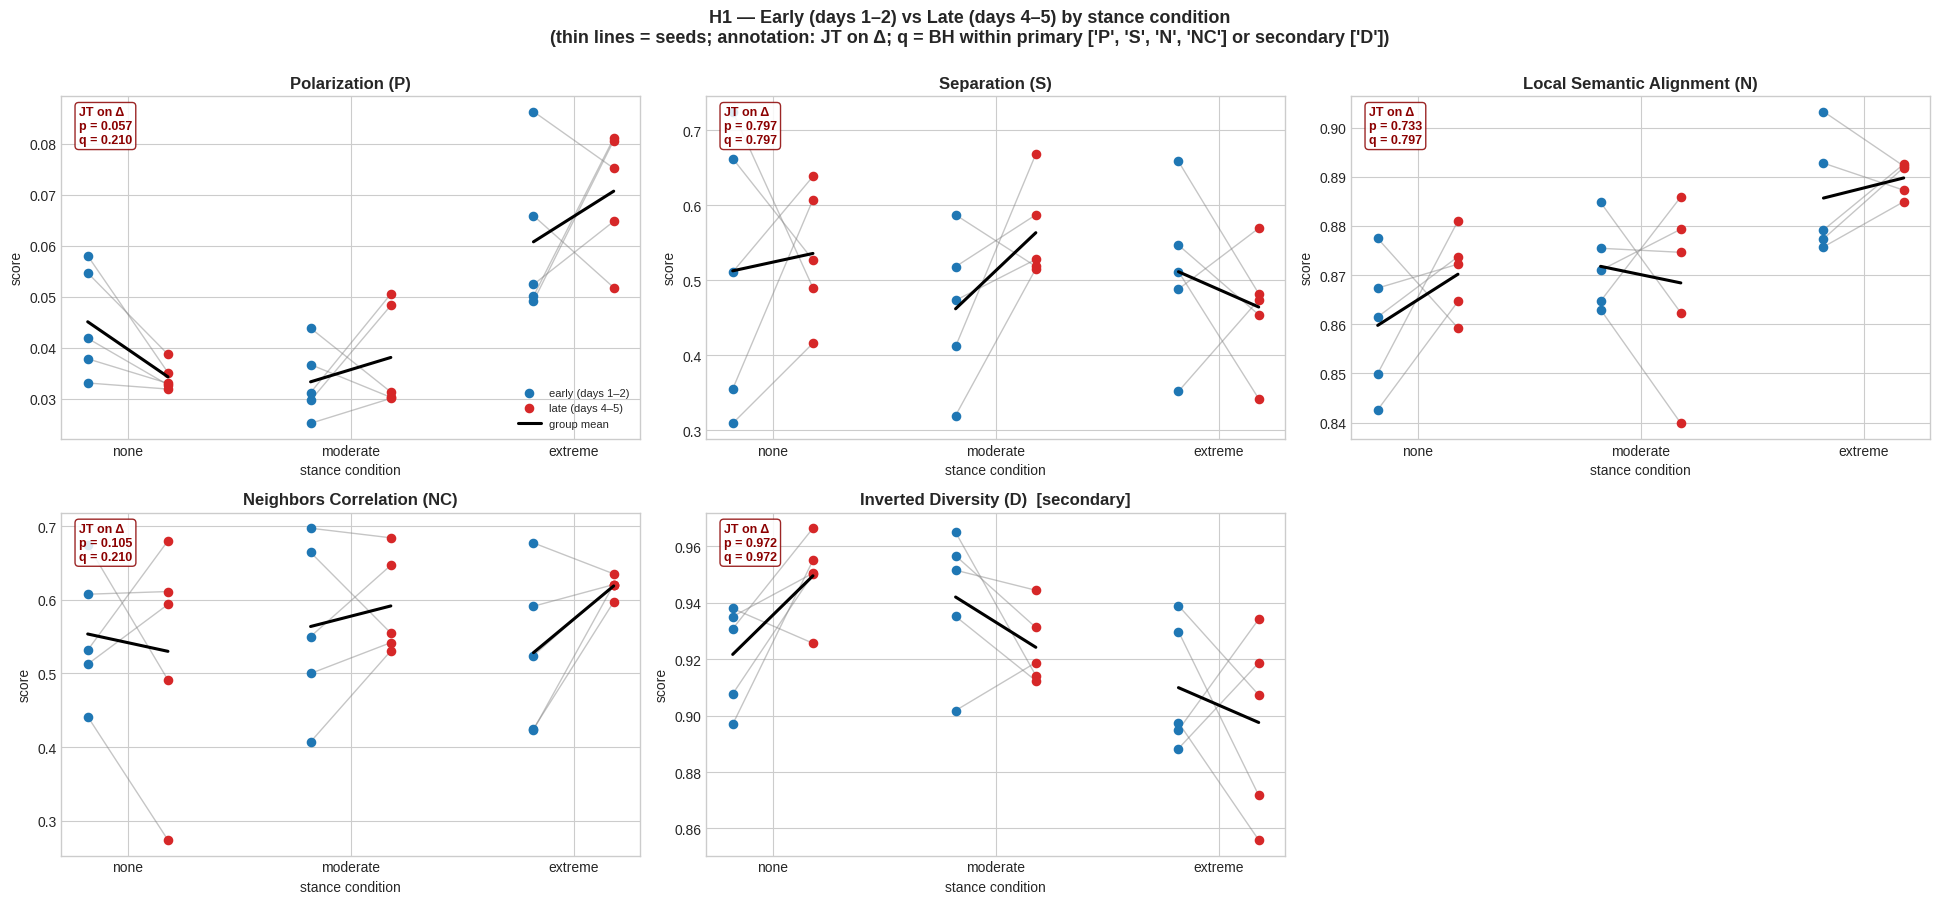


Saved H1 temporal outputs to /content/drive/MyDrive/thesis/code


In [ ]:
# ============================================================================
# Part 7: H1 temporal analysis (primary)
# ============================================================================
def temporal_slope_plot(summary, group_col, group_order, test_df, title, out_path,
                        test_label='JT on Δ'):
    """One panel per component. For each group, Early and Late sit side by side; each seed
    is a thin line from its Early to its Late value, the group mean a thick line."""
    plt.style.use('seaborn-v0_8-whitegrid')
    present = [g for g in group_order if (summary[group_col] == g).any()]
    n_panels = len(TEMPORAL_COMPONENTS)
    ncols = 2 if n_panels <= 4 else 3
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for extra in axes[n_panels:]:
        extra.axis('off')
    colors = {'early': 'tab:blue', 'late': 'tab:red'}
    for panel_i, (ax, c) in enumerate(zip(axes, TEMPORAL_COMPONENTS)):
        k = COMPONENT_SHORT[c]
        for gi, g in enumerate(present):
            sub = summary[summary[group_col] == g]
            x0, x1 = gi - 0.18, gi + 0.18
            for _, r in sub.iterrows():
                ax.plot([x0, x1], [r[f'{k}_early'], r[f'{k}_late']], color='grey', alpha=0.45, lw=1)
            ax.scatter([x0] * len(sub), sub[f'{k}_early'], color=colors['early'], s=35, zorder=3,
                       label='early (days 1–2)' if gi == 0 else None)
            ax.scatter([x1] * len(sub), sub[f'{k}_late'], color=colors['late'], s=35, zorder=3,
                       label='late (days 4–5)' if gi == 0 else None)
            ax.plot([x0, x1], [sub[f'{k}_early'].mean(), sub[f'{k}_late'].mean()],
                    color='black', lw=2.2, zorder=4, label='group mean' if gi == 0 else None)
        ax.set_xticks(range(len(present)))
        ax.set_xticklabels(present)
        ax.set_title(COMPONENT_LABELS[c] + ('' if COMPONENT_ROLE[c] == 'primary' else '  [secondary]'),
                     fontsize=12, fontweight='bold')
        ax.set_xlabel(group_col.replace('_', ' '))
        ax.set_ylabel('score')
        if panel_i == 0:
            ax.legend(fontsize=8, loc='best', framealpha=0.9)
        row = test_df[test_df['component'] == k] if test_df is not None else []
        if len(row) and pd.notna(row.iloc[0]['p_value']):
            r = row.iloc[0]
            color = 'darkgreen' if r['q_value_BH'] < 0.05 else 'darkred'
            fmt = lambda name, v: f"{name} < 0.001" if v < 0.001 else f"{name} = {v:.3f}"
            ax.text(0.03, 0.97, f"{test_label}\n{fmt('p', r['p_value'])}\n{fmt('q', r['q_value_BH'])}",
                    transform=ax.transAxes, va='top', fontsize=9, fontweight='bold', color=color,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor=color))
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()


def between_group_tests(summary, group_col, group_order, value_fmt, test='jt'):
    """JT (ordered) or exact KW (unordered) across groups for a family of run-level values,
    one test per component, BH within role (primary / secondary). `value_fmt` e.g. 'delta_{k}'."""
    rows = []
    for c in TEMPORAL_COMPONENTS:
        k = COMPONENT_SHORT[c]
        col = value_fmt.format(k=k)
        groups = [summary.loc[summary[group_col] == g, col].dropna().to_numpy() for g in group_order]
        groups_present = [g for g in groups if len(g)]
        if any(len(g) == 0 for g in groups) or len(groups_present) < 2:
            rows.append({'component': k, 'label': COMPONENT_LABELS[c], 'value': col,
                         'p_value': np.nan, 'note': 'missing data in a group'})
            continue
        res = jonckheere_terpstra_exact(groups) if test == 'jt' else kruskal_wallis_exact(groups)
        res.update({'component': k, 'label': COMPONENT_LABELS[c], 'value': col,
                    **{f'n_{g}': len(v) for g, v in zip(group_order, groups)},
                    **{f'mean_{g}': float(np.mean(v)) for g, v in zip(group_order, groups)}})
        rows.append(res)
    return bh_within_role(pd.DataFrame(rows))


def delta_group_summary(summary, group_col, group_order, test_df, value_fmt='delta_{k}',
                        increasing=True):
    """One row per component: descriptive statistics of the run-level values per group, next to
    the between-group test for the same values. For H1 this is the condition-level summary."""
    stat_keys = ['jt_statistic', 'jt_max_possible', 'jt_standardized', 'kw_H', 'epsilon_squared',
                 'null_mean', 'null_sd', 'p_value', 'p_value_floor', 'exact', 'n_relabelings',
                 'n_null_draws', 'monte_carlo_se', 'family_size', 'q_value_BH']
    test_idx = test_df.set_index('component')
    rows = []
    for c in TEMPORAL_COMPONENTS:
        k = COMPONENT_SHORT[c]
        row = {'component': k, 'label': COMPONENT_LABELS[c], 'role': COMPONENT_ROLE[c]}
        means = {}
        for g in group_order:
            v = summary.loc[summary[group_col] == g, value_fmt.format(k=k)].dropna()
            row[f'n_{g}'] = int(len(v))
            row[f'mean_{g}'] = float(v.mean()) if len(v) else np.nan
            row[f'median_{g}'] = float(v.median()) if len(v) else np.nan
            row[f'sd_{g}'] = float(v.std(ddof=1)) if len(v) > 1 else np.nan
            means[g] = row[f'mean_{g}']
        for key in stat_keys:
            if k in test_idx.index and key in test_idx.columns:
                row[key] = test_idx.loc[k, key]
        ordered = [g for g, _ in sorted(means.items(), key=lambda kv: (np.nan_to_num(kv[1], nan=-np.inf)))]
        row['observed_order_of_means'] = ' < '.join(ordered)
        if increasing:
            vals = [means[g] for g in group_order]
            row['means_follow_hypothesized_order'] = bool(all(np.isfinite(vals)) and
                                                          all(a < b for a, b in zip(vals, vals[1:])))
        rows.append(row)
    return pd.DataFrame(rows)


h1_ids = [r['run_id'] for r in H1_RUNS]
h1_tw = temporal_window_table[temporal_window_table['run_id'].isin(h1_ids)].copy()
h1_ts = temporal_run_summary[temporal_run_summary['run_id'].isin(h1_ids)].copy()
h1_pat = temporal_emergence_patterns[temporal_emergence_patterns['run_id'].isin(h1_ids)].copy()

# ---------------------------------------------------------------- 1. existence per window
print("=== H1 step 1: observed vs window null, by condition and window ===")
exist_rows = []
for cond in STANCE_ORDER:
    for window in PRIMARY_WINDOWS:
        sub = h1_tw[(h1_tw['stance_condition'] == cond) & (h1_tw['window'] == window)]
        for c in TEMPORAL_COMPONENTS:
            k = COMPONENT_SHORT[c]
            p = sub[f'{k}_p_value']
            exist_rows.append({'stance_condition': cond, 'window': window, 'component': k,
                               'role': COMPONENT_ROLE[c],
                               'mean_observed': sub[k].mean(),
                               'mean_null_mean': sub[f'{k}_null_mean'].mean(),
                               'mean_excess': sub[f'{k}_excess'].mean(),
                               'n_runs_p<0.05': int((p < EMERGENCE_ALPHA).sum()),
                               'n_runs_tested': int(p.notna().sum()),
                               'median_p': p.median()})
h1_existence = pd.DataFrame(exist_rows)
print(h1_existence.round(4).to_string(index=False))

print("\n=== H1: descriptive pattern labels (unadjusted, per run) ===")
h1_pattern_counts = (h1_pat.groupby(['stance_condition', 'component', 'pattern']).size()
                     .unstack(fill_value=0)
                     .reindex(pd.MultiIndex.from_product([STANCE_ORDER, TEMPORAL_SHORTS]), fill_value=0))
print(h1_pattern_counts.to_string())

# ---------------------------------------------------------------- 2. paired early->late
print("\n=== H1 step 2 (A. emergence): Early -> Late within condition (exact sign-flip, one-sided "
      "Δ > 0; BH within condition and role) ===")
h1_paired = paired_tests_by_group(h1_ts, 'stance_condition', STANCE_ORDER)
print(h1_paired[['stance_condition', 'role', 'label', 'n_runs', 'mean_delta', 'median_delta',
                 'n_positive', 'p_value', 'p_value_floor', 'family_size', 'q_value_BH']]
      .round(4).to_string(index=False))

# ---------------------------------------------------------------- 3. dose-response of emergence
print("\n=== H1 step 3 (C. condition-dependent emergence): Jonckheere-Terpstra over "
      "none < moderate < extreme ===")
h1_jt = {name: between_group_tests(h1_ts, 'stance_condition', STANCE_ORDER, fmt, test='jt')
         for name, fmt in [('delta', 'delta_{k}'), ('early', '{k}_early'), ('late', '{k}_late')]}
for name, title in [('delta', 'on Δ (primary: does emergence scale with the prior?)'),
                    ('early', 'on Early values (dose effect already present at the start?)'),
                    ('late', 'on Late values')]:
    print(f"\n-- JT {title}")
    cols = ['role', 'label', 'jt_statistic', 'jt_standardized', 'null_sd', 'p_value', 'family_size',
            'q_value_BH'] + [f'mean_{g}' for g in STANCE_ORDER]
    print(h1_jt[name][[c for c in cols if c in h1_jt[name].columns]].round(4).to_string(index=False))

# ---------------------------------------------------------------- robustness: excess over null
print("\n=== H1 robustness: the same tests on Δexcess (observed - window null mean) ===")
h1_paired_excess = paired_tests_by_group(h1_ts, 'stance_condition', STANCE_ORDER, suffix='_excess')
print(h1_paired_excess[['stance_condition', 'role', 'label', 'n_runs', 'mean_delta', 'n_positive',
                        'p_value', 'q_value_BH']].round(4).to_string(index=False))
h1_jt_excess = between_group_tests(h1_ts, 'stance_condition', STANCE_ORDER,
                                   'delta_{k}_excess', test='jt')
print("\n-- JT on Δexcess")
print(h1_jt_excess[['role', 'label', 'jt_statistic', 'jt_standardized', 'p_value', 'q_value_BH']]
      .round(4).to_string(index=False))

# ---------------------------------------------------------------- condition-level summary
h1_condition_summary = delta_group_summary(h1_ts, 'stance_condition', STANCE_ORDER, h1_jt['delta'])
print("\n=== H1 condition-level summary: Δ by condition + JT on Δ (q within role) ===")
_cs_cols = ['role', 'component'] + [f'{s}_{g}' for g in STANCE_ORDER for s in ('n', 'mean', 'sd')] + \
           ['jt_statistic', 'jt_standardized', 'null_mean', 'null_sd', 'p_value', 'p_value_floor',
            'exact', 'q_value_BH', 'means_follow_hypothesized_order']
print(h1_condition_summary[[c for c in _cs_cols if c in h1_condition_summary.columns]]
      .round(4).to_string(index=False))
print("  JT tests whether Δ is ordered across conditions. It is not itself a test of emergence\n"
      "  (step 2) or of non-randomness (step 1).")

n_incomplete = int(h1_ts[[f'delta_{k}' for k in TEMPORAL_SHORTS]].isna().any(axis=1).sum())
print(f"\nRuns missing a Δ for at least one component (excluded from that component's tests): "
      f"{n_incomplete}/{len(h1_ts)}")
print("Reading: 'higher in the late stage than in the early stage', not a continuous increase.")
print("A significant Δ supports emergence only together with the window nulls in step 1.")

temporal_slope_plot(
    h1_ts, 'stance_condition', STANCE_ORDER, h1_jt['delta'],
    "H1 — Early (days 1–2) vs Late (days 4–5) by stance condition\n"
    f"(thin lines = seeds; annotation: JT on Δ; q = BH within primary "
    f"{[COMPONENT_SHORT[c] for c in PRIMARY_COMPONENTS]} or secondary "
    f"{[COMPONENT_SHORT[c] for c in SECONDARY_COMPONENTS]})",
    SAVE_DIR / 'h1_temporal_early_late.png')

h1_tw.to_csv(SAVE_DIR / 'h1_temporal_window_metrics.csv', index=False)
h1_ts.to_csv(SAVE_DIR / 'h1_temporal_run_summary.csv', index=False)
h1_existence.to_csv(SAVE_DIR / 'h1_temporal_existence.csv', index=False)
h1_condition_summary.to_csv(SAVE_DIR / 'h1_condition_summary.csv', index=False)
h1_pat.to_csv(SAVE_DIR / 'h1_temporal_emergence_patterns.csv', index=False)
h1_paired.to_csv(SAVE_DIR / 'h1_temporal_paired_tests.csv', index=False)
h1_paired_excess.to_csv(SAVE_DIR / 'h1_temporal_paired_tests_excess.csv', index=False)
pd.concat([df.assign(family=name) for name, df in h1_jt.items()] +
          [h1_jt_excess.assign(family='delta_excess')]).to_csv(
    SAVE_DIR / 'h1_temporal_jt_tests.csv', index=False)
print(f"\nSaved H1 temporal outputs to {SAVE_DIR}")


## Part 7b (robustness): H1, full-run none-condition null tests

The original test over all five days pooled. It is kept for comparison with the window-specific
nulls of Part 7. A full-run result mixes Early and Late and should not be read as evidence about
when structure appeared.


In [ ]:
N_PERMUTATIONS = 1000
N_PERMUTATIONS_MODULARITY = 200   # each draw re-runs Louvain, so this one is slower
rng = np.random.default_rng(0)

none_rows = []
for cfg in H1_RUNS:
    if cfg['stance_condition'] != 'none':
        continue
    result = analysis_results[cfg['run_id']]   # in-memory: same weighted graph as the table
    G = result['G_undirected']

    tests = {
        'P_polarization': null_test_polarization(result['posts'], POLARIZATION_METRIC,
                                                  n_permutations=N_PERMUTATIONS, rng=rng),
        'S_separation': null_test_separation(G, n_permutations=N_PERMUTATIONS_MODULARITY,
                                              rng_seed=cfg['seed']),
        'D_inverted_diversity': null_test_diversity(result['user_attitudes'], G, MIN_NEIGHBORS,
                                                     n_permutations=N_PERMUTATIONS, rng=rng),
        'NC_neighbor_correlation': null_test_neighbor_correlation(
            result['user_attitudes'], G, n_permutations=N_PERMUTATIONS, rng=rng),
        'N_nci': null_test_nci(result['user_embeddings'], G,
                                n_permutations=N_PERMUTATIONS, rng=rng),
    }
    for component, vals in tests.items():
        none_rows.append({'run_id': cfg['run_id'], 'seed': cfg['seed'],
                           'component': COMPONENT_LABELS[component], **vals})

none_condition_results = pd.DataFrame(none_rows)
print("=== H1: 'none' condition vs. permutation null ===")
print(none_condition_results.to_string(index=False))

mismatches = 0
for cfg in [c for c in H1_RUNS if c['stance_condition'] == 'none']:
    row = metrics_by_run[metrics_by_run['run_id'] == cfg['run_id']].iloc[0]
    for component in COMPONENTS:
        obs = none_condition_results.loc[
            (none_condition_results['run_id'] == cfg['run_id']) &
            (none_condition_results['component'] == COMPONENT_LABELS[component]), 'observed'].iloc[0]
        if not np.isclose(obs, row[component], atol=1e-9, equal_nan=True):
            print(f"  MISMATCH {cfg['run_id']} {component}: {obs} vs {row[component]}")
            mismatches += 1
print(f"\nObserved values consistent with the component table: {mismatches == 0}")

print("\nH1 predicts these p-values should NOT be small. Anything significant here is emergent"
      "\nstructure arising with no injected stance prior -- a finding in its own right.")


=== H1: 'none' condition vs. permutation null ===
           run_id  seed                    component  observed  null_mean  null_sd  p_value
batchA_none_seed1     1             Polarization (P)  0.041979   0.030637 0.005337 0.026973
batchA_none_seed1     1               Separation (S)  0.523813   0.535456 0.021034 0.736318
batchA_none_seed1     1       Inverted Diversity (D)  0.910279   0.880224 0.013261 0.002997
batchA_none_seed1     1   Neighbors Correlation (NC)  0.655605   0.488140 0.079315 0.013986
batchA_none_seed1     1 Local Semantic Alignment (N)  0.888121   0.851079 0.006420 0.000999
batchA_none_seed2     2             Polarization (P)  0.027889   0.028623 0.004707 0.542458
batchA_none_seed2     2               Separation (S)  0.499177   0.465460 0.016721 0.014925
batchA_none_seed2     2       Inverted Diversity (D)  0.932390   0.893712 0.011233 0.000999
batchA_none_seed2     2   Neighbors Correlation (NC)  0.675202   0.484100 0.075268 0.001998
batchA_none_seed2     2 Local 

## Part 8 (robustness): H1, full-run dose-response trend, FDR, and the component grid

Full-run component values, as before. The primary H1 evidence is the temporal analysis in
Part 7; this part shows whether the pooled five-day picture agrees with it.

**On the x-axis.** The ordered factor for H1 is the **stance condition**, so that's what the axis
shows and what the JT statistic is computed over. Each condition shows its 2 seeds as points plus the
condition mean. A round-by-round trajectory is a different question (within-run temporal dynamics,
one test per run over days) and would need its own figure.

The correlation matrix underneath reports how much the four components actually move together,
rather than leaving independence implied.


=== H1: Jonckheere-Terpstra (exact, one-sided increasing) + BH-FDR ===
                       label  jt_statistic  jt_max_possible  jt_standardized  p_value  q_value_BH  exact  monte_carlo_se
            Polarization (P)          61.0             75.0         2.482872 0.006261    0.015652   True             0.0
              Separation (S)          39.0             75.0         0.158481 0.458884    0.573605   True             0.0
      Inverted Diversity (D)          11.0             75.0        -2.799834 0.998664    0.998664   True             0.0
  Neighbors Correlation (NC)          39.0             75.0         0.158481 0.458884    0.573605   True             0.0
Local Semantic Alignment (N)          67.0             75.0         3.116796 0.000526    0.002630   True             0.0

Null: full enumeration over 756,756 possible relabelings.
Smallest p this design can produce: 1.32e-06


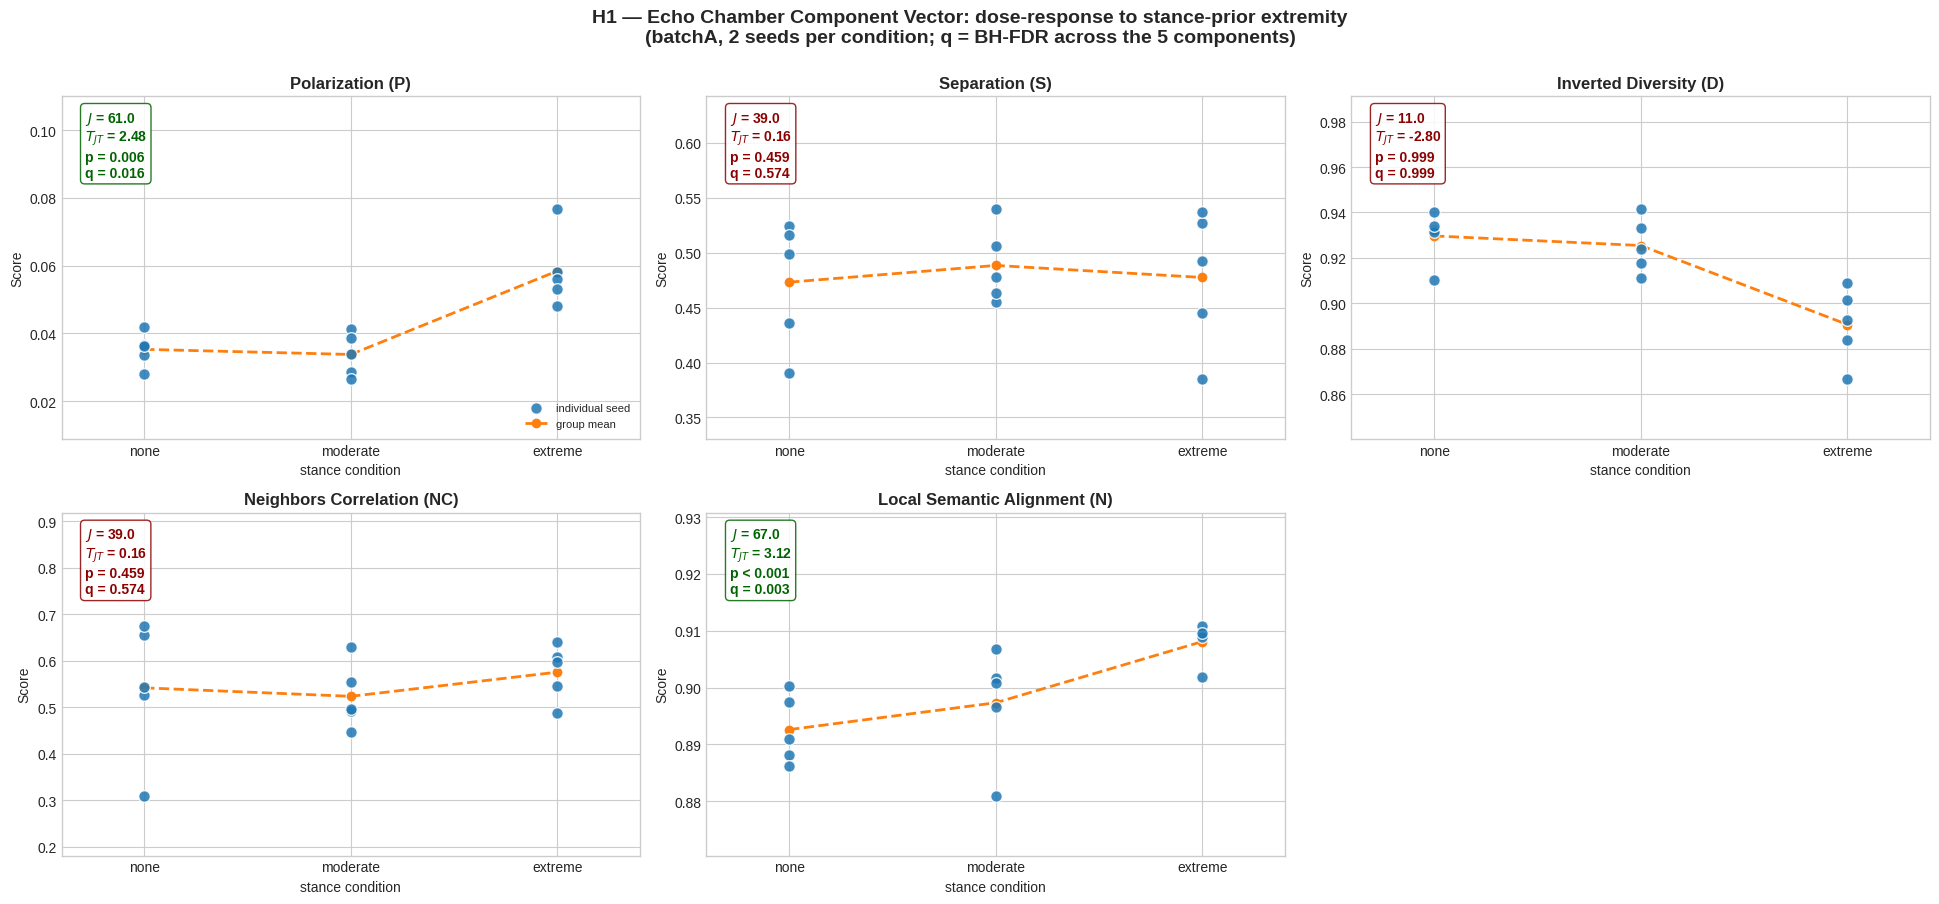


=== H1: correlation between components across the 6 batchA runs ===
                         P_polarization  S_separation  D_inverted_diversity  NC_neighbor_correlation  N_nci
P_polarization                    1.000         0.139                -0.808                    0.196  0.325
S_separation                      0.139         1.000                -0.051                    0.394 -0.006
D_inverted_diversity             -0.808        -0.051                 1.000                   -0.346 -0.493
NC_neighbor_correlation           0.196         0.394                -0.346                    1.000  0.251
N_nci                             0.325        -0.006                -0.493                    0.251  1.000

=== Redundancy diagnostic: which component is most restated by another? ===
                   component  max_|r|_with_another       most_correlated_with  mean_|r|_with_others
            Polarization (P)                 0.808     Inverted Diversity (D)                 0.367
      

In [ ]:
import seaborn as sns


def component_grid_plot(metrics_df, group_col, group_order, test_df, title, out_path,
                         annotate_fields, fixed_ylim=False):
    """Shared 2x2 facet grid for H1 and H2. `test_df` must have one row per component
    with a 'component' column; `annotate_fields` is a list of (label, key, format)."""
    plt.style.use('seaborn-v0_8-whitegrid')
    n_panels = len(COMPONENTS)
    ncols = 2 if n_panels <= 4 else 3
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for extra in axes[n_panels:]:
        extra.axis('off')
    x_pos = {g: i for i, g in enumerate(group_order)}

    for panel_i, (ax, component) in enumerate(zip(axes, COMPONENTS)):
        rows = test_df[test_df['component'] == component]
        row = rows.iloc[0] if len(rows) else None

        for point_i, (_, r) in enumerate(metrics_df.iterrows()):
            if r[group_col] not in x_pos:
                continue
            ax.scatter(x_pos[r[group_col]], r[component], s=70, color='tab:blue', zorder=3,
                        alpha=0.85, edgecolors='white', linewidth=1,
                        label='individual seed' if point_i == 0 else None)
        means = metrics_df.groupby(group_col)[component].mean().reindex(group_order)
        ax.plot(range(len(group_order)), means.values, color='tab:orange', marker='o',
                linewidth=2, linestyle='--', zorder=2, label='group mean')

        ax.set_title(f"{COMPONENT_LABELS[component]}", fontsize=12, fontweight='bold')
        ax.set_xlabel(group_col.replace('_', ' '), fontsize=10)
        ax.set_ylabel("Score", fontsize=10)
        ax.set_xticks(range(len(group_order)))
        ax.set_xticklabels(group_order)
        ax.set_xlim(-0.4, len(group_order) - 0.6)

        if fixed_ylim:
            ax.set_ylim(-0.05, 1.05)
        else:
            vals = metrics_df[component].dropna()
            lo, hi = float(vals.min()), float(vals.max())
            pad = max((hi - lo) * 0.35, 0.01)
            ax.set_ylim(lo - pad, hi + pad * 1.9)

        if panel_i == 0:
            ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

        if row is not None and pd.notna(row.get('p_value')):
            lines = [fmt.format(row[key]) for label, key, fmt in annotate_fields if pd.notna(row.get(key))]
            p_text = "p < 0.001" if row['p_value'] < 0.001 else f"p = {row['p_value']:.3f}"
            q_text = "q < 0.001" if row['q_value_BH'] < 0.001 else f"q = {row['q_value_BH']:.3f}"
            lines += [p_text, q_text]
            color = "darkgreen" if row['q_value_BH'] < 0.05 else "darkred"
            ax.text(0.04, 0.96, "\n".join(lines), transform=ax.transAxes, fontsize=10,
                    fontweight='bold', color=color, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor=color))

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()


# ---------------------------------------------------------------- H1 trend tests
trend_rows = []
for component in COMPONENTS:
    groups = [metrics_by_run.loc[metrics_by_run['stance_condition'] == cond, component].dropna().to_numpy()
              for cond in STANCE_ORDER]
    if any(len(g) == 0 for g in groups):
        trend_rows.append({'component': component, 'label': COMPONENT_LABELS[component],
                           'p_value': np.nan, 'note': 'missing data in a condition'})
        continue
    res = jonckheere_terpstra_exact(groups)
    res.update({'component': component, 'label': COMPONENT_LABELS[component]})
    trend_rows.append(res)

dose_response_trend = pd.DataFrame(trend_rows)
dose_response_trend['q_value_BH'] = benjamini_hochberg(dose_response_trend['p_value'].to_numpy())

print("=== H1: Jonckheere-Terpstra (exact, one-sided increasing) + BH-FDR ===")
cols = ['label', 'jt_statistic', 'jt_max_possible', 'jt_standardized', 'p_value', 'q_value_BH']
cols += [c for c in ['exact', 'monte_carlo_se'] if c in dose_response_trend.columns]
print(dose_response_trend[cols].to_string(index=False))

if 'n_relabelings' in dose_response_trend.columns:
    row = dose_response_trend.dropna(subset=['p_value']).head(1)
    if len(row):
        r = row.iloc[0]
        mode = "full enumeration" if r.get('exact', True) else \
               f"Monte Carlo, {int(r['n_null_draws']):,} draws"
        print(f"\nNull: {mode} over {int(r['n_relabelings']):,} possible relabelings.")
        print(f"Smallest p this design can produce: {r['p_value_floor']:.2e}")
        if not r.get('exact', True):
            print(f"Monte Carlo standard error on p: ~{r['monte_carlo_se']:.4f}. Raise "
                  "N_MONTE_CARLO if a\np-value sits near your threshold.")

component_grid_plot(
    metrics_by_run, 'stance_condition', STANCE_ORDER, dose_response_trend,
    f"H1 — Echo Chamber Component Vector: dose-response to stance-prior extremity\n"
    f"(batchA, 2 seeds per condition; q = BH-FDR across the {len(COMPONENTS)} components)",
    SAVE_DIR / 'h1_component_grid.png',
    annotate_fields=[('J', 'jt_statistic', '$J$ = {:.1f}'),
                      ('T', 'jt_standardized', '$T_{{JT}}$ = {:.2f}')])

print("\n=== H1: correlation between components across the 6 batchA runs ===")
component_corr = metrics_by_run[COMPONENTS].corr()
print(component_corr.round(3).to_string())

# ---------------------------------------------------------------- redundancy check
# Five components are computed; four are meant to be reported. This is the evidence for
# which to drop. On synthetic data D correlated -0.80 with P (D is unnormalized, so it
# partly restates polarization) while tracking true homophily only +0.21, and NC -- being
# a correlation, and therefore self-normalizing -- tracked homophily far better. Whether
# that reproduces here is what decides the choice; it is NOT settled by the simulation.
print("\n=== Redundancy diagnostic: which component is most restated by another? ===")
red_rows = []
for c in COMPONENTS:
    others = [o for o in COMPONENTS if o != c]
    cors = component_corr.loc[c, others].abs()
    red_rows.append({'component': COMPONENT_LABELS[c],
                      'max_|r|_with_another': float(cors.max()),
                      'most_correlated_with': COMPONENT_LABELS[cors.idxmax()],
                      'mean_|r|_with_others': float(cors.mean())})
redundancy = pd.DataFrame(red_rows).sort_values('max_|r|_with_another', ascending=False)
print(redundancy.round(3).to_string(index=False))

if {'D_inverted_diversity', 'P_polarization'}.issubset(set(COMPONENTS)):
    r_dp = component_corr.loc['D_inverted_diversity', 'P_polarization']
    print(f"\n  D vs P: r = {r_dp:+.3f}")
    if abs(r_dp) > 0.7:
        print("  D is largely an inverse restatement of P here, which is the expected")
        print("  behaviour of an unnormalized local measure: as camps separate, neighbourhood")
        print("  standard deviation rises mechanically. This is the case for dropping D and")
        print("  reporting NC in its place.")
    else:
        print("  D is NOT strongly tied to P in these runs, so it is carrying independent")
        print("  information and the case for dropping it is weaker than the synthetic")
        print("  simulation suggested. Decide on this table, not on that simulation.")
if {'NC_neighbor_correlation', 'D_inverted_diversity'}.issubset(set(COMPONENTS)):
    print(f"  NC vs D: r = {component_corr.loc['NC_neighbor_correlation', 'D_inverted_diversity']:+.3f}"
          "   (both local + attitude-based; high |r| would mean keeping both is wasteful)")
if {'NC_neighbor_correlation', 'N_nci'}.issubset(set(COMPONENTS)):
    print(f"  NC vs N : r = {component_corr.loc['NC_neighbor_correlation', 'N_nci']:+.3f}"
          "   (local attitude vs local language -- expected to be related, not identical)")

print("\nWith n=6 runs these correlations are very noisy; treat the table as one input")
print("to the decision, alongside which components actually separate the conditions.")
redundancy.to_csv(SAVE_DIR / 'h1_component_redundancy.csv', index=False)

metrics_all.to_csv(SAVE_DIR / 'components_by_run_all.csv', index=False)
none_condition_results.to_csv(SAVE_DIR / 'h1_none_condition_null_tests.csv', index=False)
dose_response_trend.to_csv(SAVE_DIR / 'h1_dose_response_trend.csv', index=False)
component_corr.to_csv(SAVE_DIR / 'h1_component_correlations.csv')
print(f"\nSaved H1 outputs to {SAVE_DIR}")


---

# H2: Model-dependent polarization across homogeneous populations

**Hypothesis:** Echo chamber intensity differs by foundation model, with persona assignment and all
other parameters held constant.

**Design:** 6 runs at *moderate* stance = 3 models × 2 seeds. The llama arm is batchA's moderate
runs, reused rather than re-scored; batchB supplies deepseek and gemma. Because every run went
through the same anchor prototypes and the same globally-fitted scaler, the attitude scale is
identical across models — which is the whole reason those changes were made.

## Two things to settle before reading any result

**1. The test changes.** Models are *unordered*. Jonckheere-Terpstra exists to exploit ordering, so
using it here would mean inventing a rank among llama, deepseek and gemma that no theory supports.
H2 uses **Kruskal-Wallis**, again with an exact permutation p-value from enumerating all 90
relabelings, and reports **ε²** (epsilon-squared) as the effect size.

**2. There is a hard power ceiling, and at 2 seeds it sits above 0.05.** Kruskal-Wallis is invariant
to which group gets which label, so all 3! = 6 relabelings of the model labels produce the identical
H statistic. Even under *perfect* separation, at least 6 of the 90 relabelings tie the observed
value, giving an **exact p-value floor of 6/90 = 0.0667**. That is above α = 0.05 before any FDR
correction is applied.

Concretely: **as designed, H2 cannot produce a significant result.** Not "probably won't" — cannot.
The cell below computes this floor from your actual design and warns if it exceeds 0.05.

The fix is cheap. A third seed per model takes the floor to 6/1680 ≈ 0.0036, comfortably below any
threshold. If a third seed isn't possible, H2 has to be reported descriptively — effect sizes,
component vectors per model, and the observed ordering — with the power limitation stated plainly
rather than a non-significant p-value presented as evidence of no difference.

## The participation gate

This is the diagnostic that decides whether H2 is interpretable at all. If deepseek or gemma agents
mechanically under-participated, then a "model effect" on any component may be an effect of
**effective N** rather than of model identity: fewer active agents means a sparser graph, which
moves S, D and N directly, independent of anything about how the model writes.

The next cell reports participation per run and flags runs below a usable threshold. Given the
`gemma4:e4b` / `gemma3n:e4b` tag issue and the deepseek token-cap issue, expect this to bite. Read
it before reading the test results.

## Temporal design for H2

The primary H2 analysis is the temporal section after the full-run Kruskal-Wallis cell: the same
Early/Late snapshots and window-specific nulls as H1, then exact Kruskal-Wallis on Δ across models.
The full-run gate and test below are kept as the robustness version.


In [ ]:
MIN_ACTIVE_AGENTS = 20     # below this, graph-based components (S, D, N) are not trustworthy
MIN_PARTICIPATION = 0.30   # below this, treat the arm as failed rather than merely noisy

h2_metrics = metrics_all[metrics_all['run_id'].isin([r['run_id'] for r in H2_RUNS])].copy()
h2_metrics = h2_metrics.reset_index(drop=True)

print("=== H2 GATE: participation by run ===")
participation = h2_metrics[['run_id', 'model', 'seed', 'n_agents_active', 'n_agents_configured',
                             'participation_rate', 'n_posts', 'n_edges']].copy()
participation['posts_per_active_agent'] = (participation['n_posts'] /
                                            participation['n_agents_active'].replace(0, np.nan))
print(participation.to_string(index=False))

print("\n=== Homogeneity check (H2 arms must be single-model) ===")
h2_validation = model_validation[model_validation['run_id'].isin(h2_metrics['run_id'])]
print(h2_validation[['run_id', 'expected_model', 'observed_models',
                      'is_homogeneous', 'matches_config']].to_string(index=False))
if not h2_validation['is_homogeneous'].all():
    print("  WARNING: an H2 arm contains more than one model. H2 assumes homogeneous")
    print("  populations; a mixed arm belongs in H3, not here.")

print("\n=== Participation by model ===")
by_model = h2_metrics.groupby('model').agg(
    runs=('run_id', 'count'),
    mean_active=('n_agents_active', 'mean'),
    mean_participation=('participation_rate', 'mean'),
    mean_posts=('n_posts', 'mean')).reindex([m for m in MODEL_ORDER if m in set(h2_metrics['model'])])
print(by_model.round(3).to_string())

# ---- flags ----
failed = participation[(participation['n_agents_active'] < MIN_ACTIVE_AGENTS) |
                        (participation['participation_rate'] < MIN_PARTICIPATION)]
print("\n=== Gate verdict ===")
if len(failed) == 0:
    print(f"PASS: every H2 run has >= {MIN_ACTIVE_AGENTS} active agents and "
          f">= {MIN_PARTICIPATION:.0%} participation.")
else:
    print(f"FAIL: {len(failed)} of {len(participation)} runs fall below the thresholds "
          f"({MIN_ACTIVE_AGENTS} active agents, {MIN_PARTICIPATION:.0%} participation):")
    for _, r in failed.iterrows():
        print(f"   {r['run_id']:26s} model={r['model']:9s} "
              f"active={r['n_agents_active']:3.0f}/{r['n_agents_configured']:.0f} "
              f"({r['participation_rate']:.1%}), posts={r['n_posts']:.0f}")
    print("\n  Any model difference below is confounded with effective N. A model arm with a")
    print("  handful of active agents produces a sparse graph, which moves S, D and N directly,")
    print("  regardless of how that model actually writes. Fix the runs before interpreting H2.")

# ---- how strongly does participation track each component across these runs? ----
print("\n=== Participation confound check: correlation with each component ===")
print("(across H2 runs; a large |r| means the component tracks activity level, not model identity)")
conf_rows = []
for component in COMPONENTS:
    sub = h2_metrics[['participation_rate', component]].dropna()
    if len(sub) >= 3 and sub['participation_rate'].nunique() > 1:
        r_pearson = float(sub['participation_rate'].corr(sub[component]))
        r_spearman = float(sub['participation_rate'].corr(sub[component], method='spearman'))
    else:
        r_pearson = r_spearman = np.nan
    conf_rows.append({'component': COMPONENT_LABELS[component],
                       'pearson_r_with_participation': r_pearson,
                       'spearman_r_with_participation': r_spearman})
participation_confound = pd.DataFrame(conf_rows)
print(participation_confound.round(3).to_string(index=False))
print(f"\nWith n={len(h2_metrics)} runs these correlations are very unstable -- treat them as a")
print("warning light, not an estimate. They cannot statistically adjust for the confound;")
print("only balanced participation can.")


=== H2 GATE: participation by run ===
               run_id    model  seed  n_agents_active  n_agents_configured  participation_rate  n_posts  n_edges  posts_per_active_agent
batchA_moderate_seed5    llama     5               81                  100                0.81      333      103                4.111111
   batchB_gemma_seed1    gemma     1               90                  100                0.90      533      267                5.922222
   batchB_gemma_seed2    gemma     2               91                  100                0.91      516      265                5.670330
   batchB_gemma_seed3    gemma     3               92                  100                0.92      505      214                5.489130
batchB_deepseek_seed1 deepseek     1               83                  100                0.83      357      135                4.301205
batchB_deepseek_seed2 deepseek     2               84                  100                0.84      312      112                3.714286
bat

In [ ]:
def kruskal_wallis_H(groups):
    """Kruskal-Wallis H, computed directly so it can be evaluated inside the exact
    permutation loop. Matches scipy.stats.kruskal on the same input (verified);
    scipy is not used here only because we need the statistic without its
    asymptotic chi-square p-value, which is invalid at these sample sizes."""
    all_values = np.concatenate(groups)
    n = len(all_values)
    ranks = rankdata(all_values)
    total, pos = 0.0, 0
    for g in groups:
        r = ranks[pos:pos + len(g)]
        pos += len(g)
        total += len(g) * (r.mean() - (n + 1) / 2) ** 2
    return 12.0 / (n * (n + 1)) * total


def epsilon_squared(H, n, k):
    """Effect size for Kruskal-Wallis: the proportion of rank variance explained by
    group membership. eps^2 = (H - k + 1) / (n - k), clipped at 0.
    Conventional reading: ~0.01 small, ~0.08 medium, ~0.26 large. Report this
    alongside p, and *especially* when p can't clear the design's floor."""
    if n <= k:
        return np.nan
    return max(0.0, float((H - k + 1) / (n - k)))


def kruskal_wallis_exact(groups):
    """Exact Kruskal-Wallis by enumerating every relabeling that preserves group sizes.

    Also returns `p_value_floor`: the smallest p this DESIGN can produce, obtained by
    evaluating the enumeration against the maximum attainable H. Because KW is
    invariant to which group receives which label, at least k! relabelings always tie
    the maximum, so the floor is k!/n_relabelings when groups are EQUALLY sized.

    Group sizes matter here in a way that is easy to get backwards. With equal sizes
    every one of the k! label permutations ties the maximum: 3 groups of 2 gives
    6/90 = 0.0667 (above alpha, so nothing can be significant), and 3 groups of 3 gives
    6/1680 = 0.0036. With UNEQUAL sizes only the equally-sized groups are
    interchangeable, so fewer permutations tie and the floor drops further: 5/3/3 gives
    0.00065 over 9,240 relabelings. An unbalanced design is therefore not a compromise
    for this test -- it is strictly better, and Kruskal-Wallis handles unequal n natively.
    """
    group_sizes = [len(g) for g in groups]
    all_values = np.concatenate(groups)
    n, k = len(all_values), len(groups)
    observed = kruskal_wallis_H(groups)

    null_stats = np.array([kruskal_wallis_H(r) for r in _all_relabelings(all_values, group_sizes)])
    max_H = null_stats.max()

    return {'kw_H': observed,
            'kw_H_max_possible': float(max_H),
            'epsilon_squared': epsilon_squared(observed, n, k),
            'n_relabelings': int(len(null_stats)),
            'null_mean': float(null_stats.mean()),
            'p_value': float(np.mean(null_stats >= observed)),
            'p_value_floor': float(np.mean(null_stats >= max_H))}


# ---- verify against scipy, and report this design's power ceiling ----
_check = [np.array([0.1, 0.2]), np.array([0.5, 0.6]), np.array([0.9, 1.0])]
_scipy_H = kruskal(*_check).statistic
_ours = kruskal_wallis_exact(_check)
print(f"Implementation check vs scipy.stats.kruskal: ours={_ours['kw_H']:.6f} "
      f"scipy={_scipy_H:.6f} match={np.isclose(_ours['kw_H'], _scipy_H)}")

# The floor must come from the ACTUAL group sizes, not from the sanity-check example
# above: it depends entirely on the design, and reading it off a fixed 2/2/2 toy would
# report a ceiling that has nothing to do with the data being analysed.
_sizes = [int((h2_metrics['model'] == m).sum()) for m in MODEL_ORDER
          if (h2_metrics['model'] == m).any()]
print(f"\nH2 design: {len(_sizes)} models with group sizes {_sizes} (n={sum(_sizes)}).")

if len(_sizes) >= 2 and min(_sizes) >= 1:
    _dummy = [np.arange(sum(_sizes), dtype=float)[sum(_sizes[:k]):sum(_sizes[:k + 1])]
              for k in range(len(_sizes))]
    _design = kruskal_wallis_exact(_dummy)
    _floor = _design['p_value_floor']
    print(f"Enumeration size: {_design['n_relabelings']:,} relabelings")
    print(f"Exact p-value FLOOR for this design: {_floor:.5f}")

    if _floor > 0.05:
        print("\n  *** WARNING: the floor exceeds alpha = 0.05. ***")
        print("  No arrangement of these data can yield a significant Kruskal-Wallis result,")
        print("  because KW ignores group order and all k! label permutations tie the maximum H.")
        print("  Adding a seed per model lowers the floor sharply. Until then, report H2")
        print("  descriptively (effect sizes + component vectors) and state the ceiling; do NOT")
        print("  present a non-significant p as evidence that models do not differ.")
    else:
        print("  Below alpha = 0.05, so this design CAN produce a significant result.")
        if len(set(_sizes)) > 1:
            print(f"  Note the groups are unequal {_sizes}, which HELPS here: only equally-sized")
            print("  groups are interchangeable under KW, so fewer permutations tie the maximum")
            print("  and the floor is lower than a balanced design of the same total n would give.")
    print("  Effect sizes should still be reported alongside p.")
else:
    print("Too few model groups present to characterise the design.")


Implementation check vs scipy.stats.kruskal: ours=4.571429 scipy=4.571429 match=True

H2 design: 3 models with group sizes [5, 3, 3] (n=11).
Enumeration size: 9,240 relabelings
Exact p-value FLOOR for this design: 0.00065
  Below alpha = 0.05, so this design CAN produce a significant result.
  Note the groups are unequal [5, 3, 3], which HELPS here: only equally-sized
  groups are interchangeable under KW, so fewer permutations tie the maximum
  and the floor is lower than a balanced design of the same total n would give.
  Effect sizes should still be reported alongside p.


=== H2: Kruskal-Wallis (exact) + BH-FDR across the 5 components ===
                       label   kw_H  epsilon_squared  p_value  p_value_floor  q_value_BH  mean_llama  mean_deepseek  mean_gemma
            Polarization (P) 1.4424           0.0000   0.5392         0.0006      0.6740      0.0338         0.0277      0.0291
              Separation (S) 3.6485           0.2061   0.1673         0.0006      0.2789      0.4883         0.4627      0.3811
      Inverted Diversity (D) 0.3758           0.0000   0.8677         0.0006      0.8677      0.9254         0.9266      0.9197
  Neighbors Correlation (NC) 6.3030           0.5379   0.0245         0.0006      0.0801      0.5235         0.5751      0.3894
Local Semantic Alignment (N) 6.1091           0.5136   0.0320         0.0006      0.0801      0.8973         0.8964      0.8716


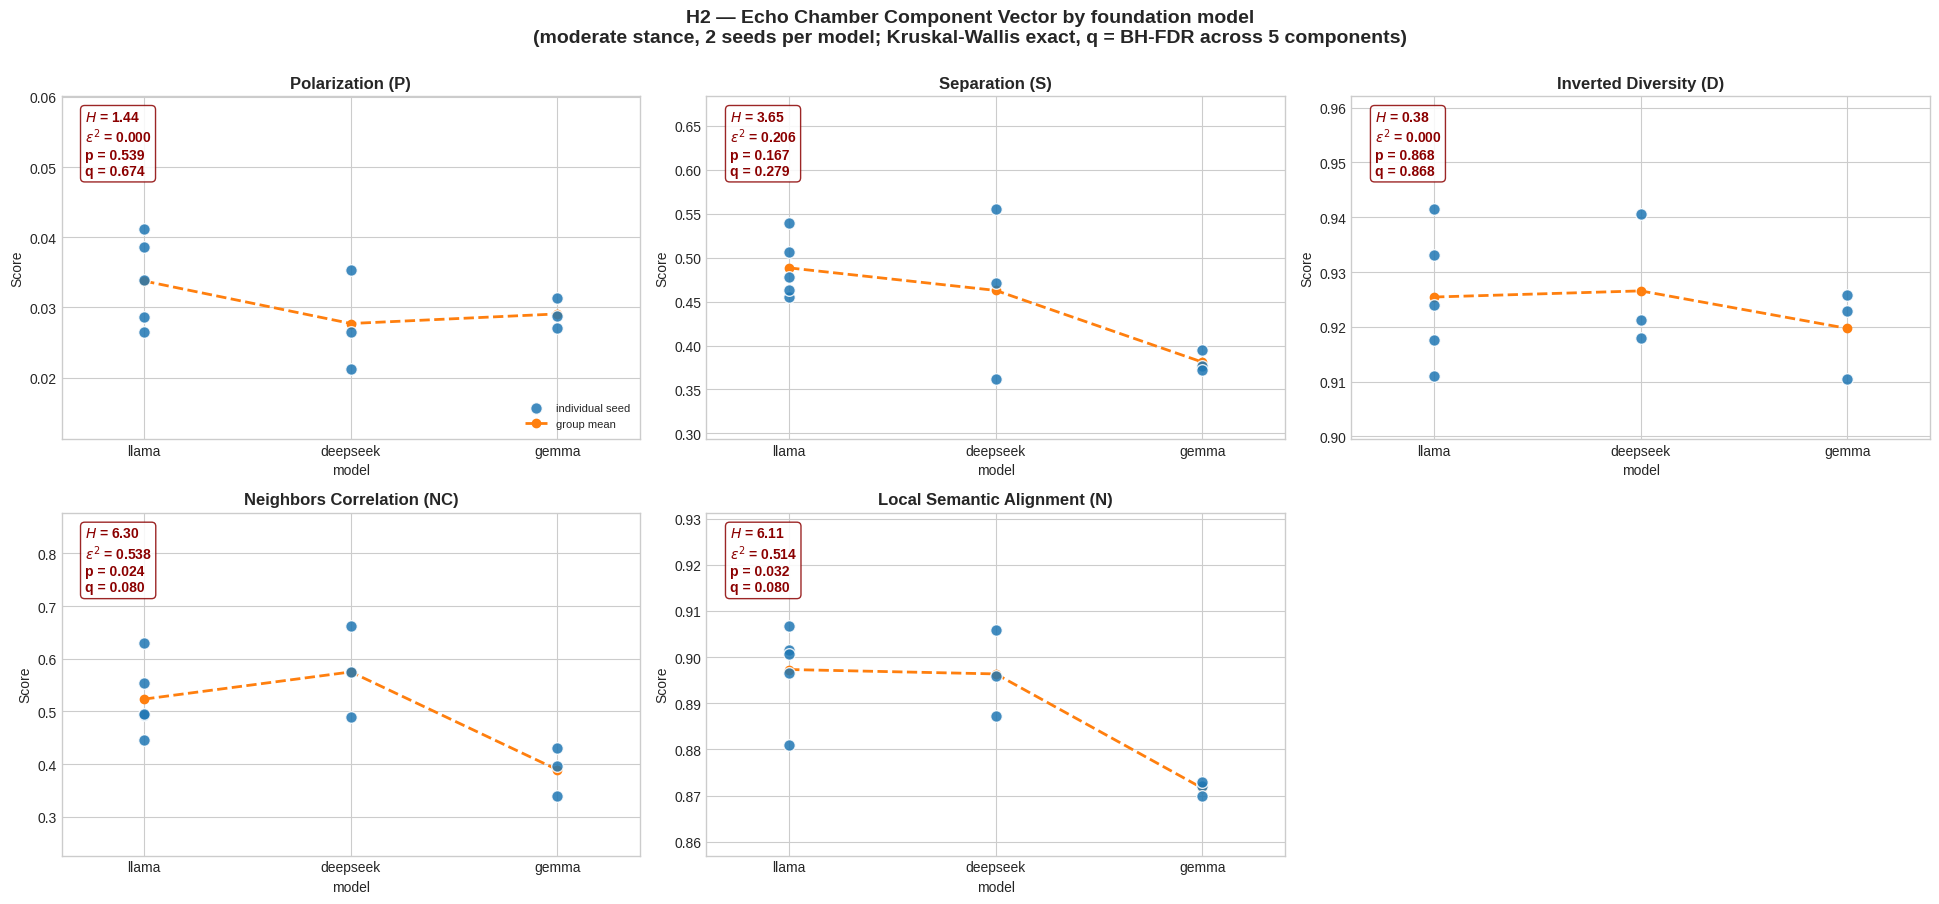


=== H2: component means by model (the descriptive result) ===
         P_polarization         S_separation         D_inverted_diversity         NC_neighbor_correlation           N_nci        
                   mean     std         mean     std                 mean     std                    mean     std    mean     std
model                                                                                                                            
llama            0.0338  0.0063       0.4883  0.0346               0.9254  0.0121                  0.5235  0.0704  0.8973  0.0099
deepseek         0.0277  0.0071       0.4627  0.0971               0.9266  0.0122                  0.5751  0.0870  0.8964  0.0093
gemma            0.0291  0.0021       0.3811  0.0119               0.9197  0.0082                  0.3894  0.0464  0.8716  0.0015

=== Observed ordering per component (highest first) ===
  Polarization (P)         llama (0.034)  >  gemma (0.029)  >  deepseek (0.028)
  Separation (S)    

In [ ]:
# ROBUSTNESS: full-run (all five days pooled) Kruskal-Wallis. Primary H2 evidence is the
# temporal section that follows.
present_models = [m for m in MODEL_ORDER if (h2_metrics['model'] == m).any()]

h2_rows = []
for component in COMPONENTS:
    groups = [h2_metrics.loc[h2_metrics['model'] == m, component].dropna().to_numpy()
              for m in present_models]
    if any(len(g) == 0 for g in groups) or len(groups) < 2:
        h2_rows.append({'component': component, 'label': COMPONENT_LABELS[component],
                         'p_value': np.nan, 'note': 'missing data for a model'})
        continue
    res = kruskal_wallis_exact(groups)
    res.update({'component': component, 'label': COMPONENT_LABELS[component],
                 **{f'mean_{m}': float(np.mean(g)) for m, g in zip(present_models, groups)}})
    h2_rows.append(res)

h2_model_test = pd.DataFrame(h2_rows)
h2_model_test['q_value_BH'] = benjamini_hochberg(h2_model_test['p_value'].to_numpy())

print(f"=== H2: Kruskal-Wallis (exact) + BH-FDR across the {len(COMPONENTS)} components ===")
show_cols = ['label', 'kw_H', 'epsilon_squared', 'p_value', 'p_value_floor', 'q_value_BH'] + \
            [f'mean_{m}' for m in present_models]
print(h2_model_test[[c for c in show_cols if c in h2_model_test.columns]].round(4).to_string(index=False))

floor = h2_model_test['p_value_floor'].dropna()
if len(floor) and floor.iloc[0] > 0.05:
    print(f"\nEvery p above is bounded below by {floor.iloc[0]:.4f}. Read epsilon_squared and the"
          "\nper-model means as the substantive result; the p-values cannot discriminate here.")

# ---------------------------------------------------------------- H2 grid
component_grid_plot(
    h2_metrics, 'model', present_models, h2_model_test,
    "H2 — Echo Chamber Component Vector by foundation model\n"
    f"(moderate stance, 2 seeds per model; Kruskal-Wallis exact, q = BH-FDR across "
    f"{len(COMPONENTS)} components)",
    SAVE_DIR / 'h2_component_grid.png',
    annotate_fields=[('H', 'kw_H', '$H$ = {:.2f}'),
                      ('eps2', 'epsilon_squared', r'$\varepsilon^2$ = {:.3f}')])

# ---------------------------------------------------------------- ordering summary
print("\n=== H2: component means by model (the descriptive result) ===")
h2_summary = (h2_metrics.groupby('model')[COMPONENTS].agg(['mean', 'std'])
              .reindex(present_models).round(4))
print(h2_summary.to_string())

print("\n=== Observed ordering per component (highest first) ===")
for component in COMPONENTS:
    means = h2_metrics.groupby('model')[component].mean().reindex(present_models).sort_values(ascending=False)
    print(f"  {COMPONENT_LABELS[component]:24s} " +
          "  >  ".join(f"{m} ({v:.3f})" for m, v in means.items()))

# ---------------------------------------------------------------- save
h2_metrics.to_csv(SAVE_DIR / 'h2_components_by_run.csv', index=False)
participation.to_csv(SAVE_DIR / 'h2_participation.csv', index=False)
participation_confound.to_csv(SAVE_DIR / 'h2_participation_confound.csv', index=False)
h2_model_test.to_csv(SAVE_DIR / 'h2_model_test.csv', index=False)
print(f"\nSaved H2 outputs to {SAVE_DIR}")


## H2, temporal existence and emergence (PRIMARY)

The same three steps as H1, with models unordered:

1. **Participation gate per window.** The full-run gate above can pass while a window fails. If one
   model's agents post mostly late, its Early snapshot is small and sparse, and a "model difference
   in Δ" can come from graph size. Active agents and edges are checked per model and window.
2. **Existence per window and emergence within model.** Window nulls, pattern labels, and the exact
   paired sign-flip test of Δ > 0 per model. With 3 seeds (deepseek, gemma) the floor is 1/8, so
   those arms can only be described; the 5-seed llama arm has a floor of 1/32.
3. **Model dependence of emergence.** Exact Kruskal-Wallis on **Δ** across models, with ε², plus KW
   on Early and Late levels. The exact floor comes from the actual group sizes, as in Part 5 of H2.

BH is applied within each family and separately for primary (P, S, N, NC) and secondary (D)
components. `h2_model_summary` puts per-model Δ statistics next to the Kruskal-Wallis result.


=== H2 temporal gate: active agents and edges per window ===
                               n_agents      n_edges      n_posts     
window                            early late   early late   early late
model    run_id                                                       
deepseek batchB_deepseek_seed1       55   57      59   56     143  147
         batchB_deepseek_seed2       56   52      43   49     112  132
         batchB_deepseek_seed3       55   59      55   71     147  188
gemma    batchB_gemma_seed1          62   62      93  129     192  244
         batchB_gemma_seed2          59   66      93  111     179  228
         batchB_gemma_seed3          65   67      70  107     177  216
llama    batchA_moderate_seed1       60   55      54   45     136  129
         batchA_moderate_seed2       49   58      47   74     123  173
         batchA_moderate_seed3       44   59      28   54      89  136
         batchA_moderate_seed4       51   57      31   74     109  170
         batchA_

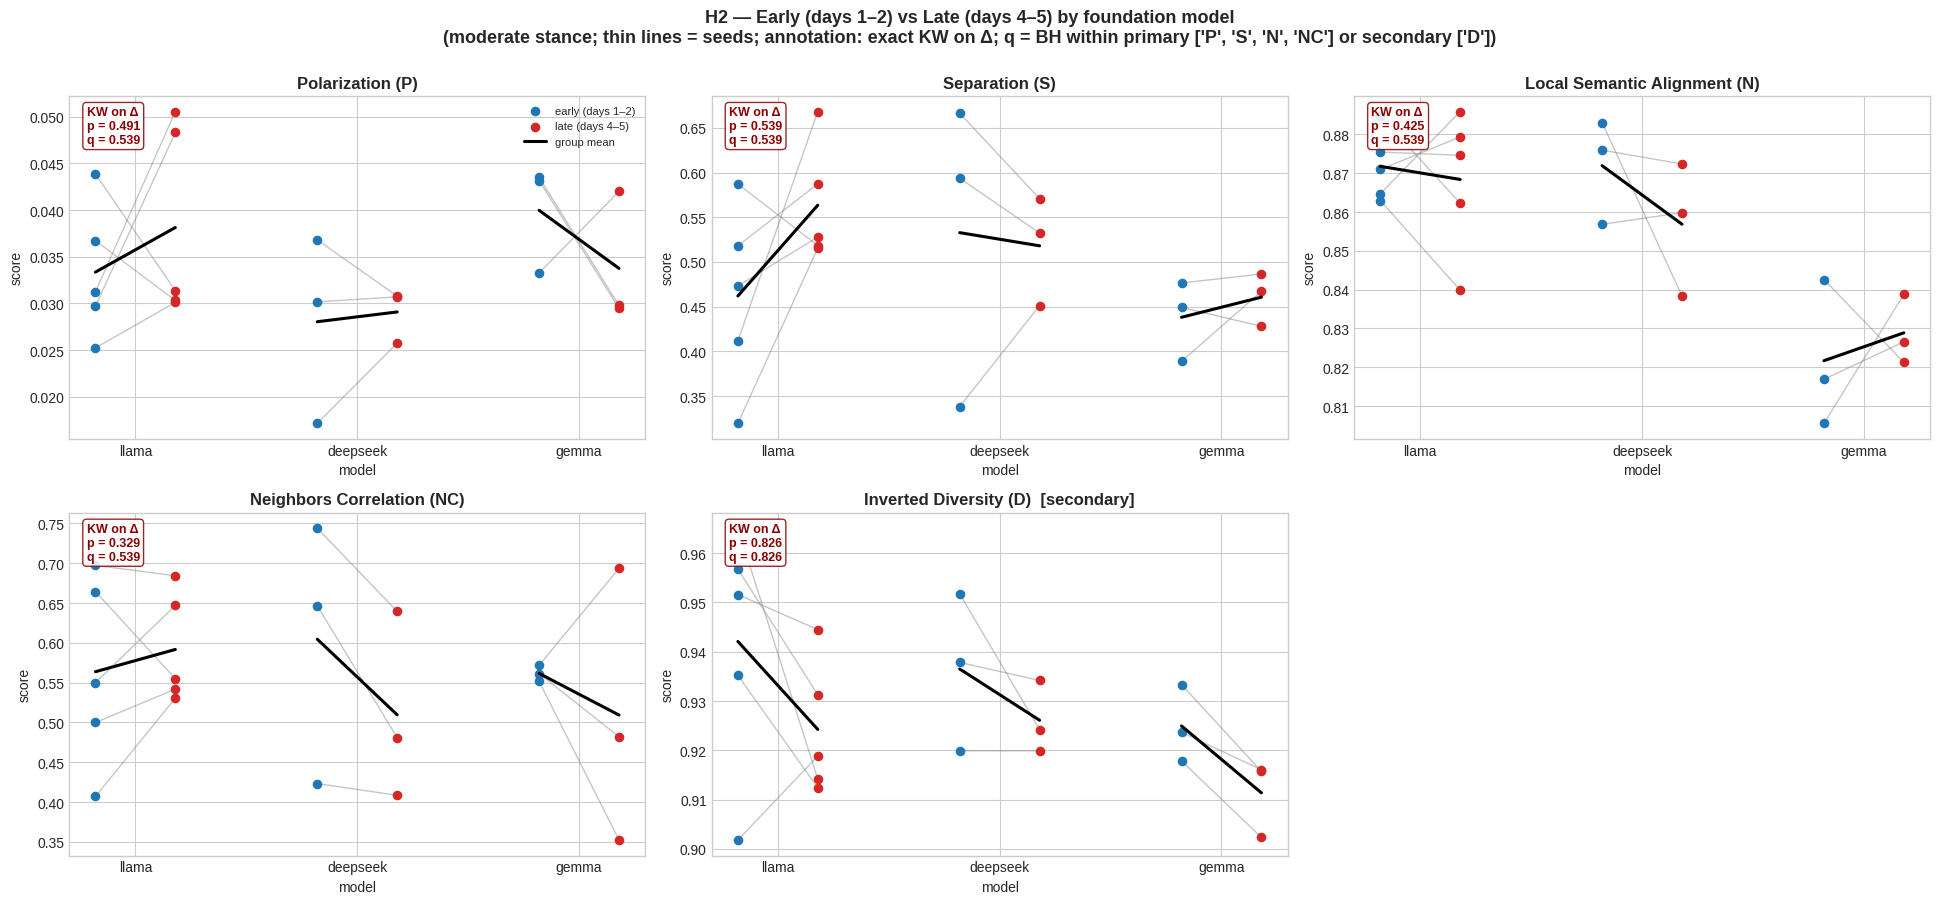


Saved H2 temporal outputs to /content/drive/MyDrive/thesis/code


In [ ]:
# ============================================================================
# H2 temporal analysis (primary)
# ============================================================================
h2_ids = [r['run_id'] for r in H2_RUNS]
h2_tw = temporal_window_table[temporal_window_table['run_id'].isin(h2_ids)].copy()
h2_ts = temporal_run_summary[temporal_run_summary['run_id'].isin(h2_ids)].copy()
h2_pat = temporal_emergence_patterns[temporal_emergence_patterns['run_id'].isin(h2_ids)].copy()
h2_models_t = [m for m in MODEL_ORDER if (h2_ts['model'] == m).any()]

# ---------------------------------------------------------------- 1. per-window gate
print("=== H2 temporal gate: active agents and edges per window ===")
print(h2_tw.pivot_table(index=['model', 'run_id'], columns='window',
                        values=['n_agents', 'n_edges', 'n_posts'], aggfunc='first')
      .round(0).to_string())
gate = (h2_tw.groupby(['model', 'window'])[['n_agents', 'n_edges', 'n_posts']].mean()
        .reindex(pd.MultiIndex.from_product([h2_models_t, PRIMARY_WINDOWS])))
print("\nMeans by model and window:")
print(gate.round(1).to_string())

failed_w = h2_tw[(h2_tw['n_agents'] < MIN_ACTIVE_AGENTS) | (~h2_tw['graph_ok'])]
if len(failed_w):
    print(f"\nFAIL: {len(failed_w)} H2 snapshot(s) below {MIN_ACTIVE_AGENTS} active agents or "
          f"{TEMPORAL_MIN_EDGES} edges:")
    print(failed_w[['run_id', 'model', 'window', 'n_agents', 'n_edges']].to_string(index=False))
    print("  Model differences in those windows are confounded with snapshot size.")
else:
    print(f"\nPASS: every H2 snapshot has >= {MIN_ACTIVE_AGENTS} active agents and "
          f">= {TEMPORAL_MIN_EDGES} edges.")

# Does the change in snapshot size differ by model? If so, Δ of S/D/N/NC may track it.
h2_size = h2_tw.pivot_table(index='run_id', columns='window', values=['n_agents', 'n_edges'])
h2_size.columns = [f'{a}_{b}' for a, b in h2_size.columns]
h2_size = h2_size.reset_index().merge(h2_ts[['run_id', 'model']], on='run_id')
h2_size['delta_n_agents'] = h2_size['n_agents_late'] - h2_size['n_agents_early']
h2_size['delta_n_edges'] = h2_size['n_edges_late'] - h2_size['n_edges_early']
print("\nChange in snapshot size, Late - Early, by model (mean):")
print(h2_size.groupby('model')[['delta_n_agents', 'delta_n_edges']].mean()
      .reindex(h2_models_t).round(1).to_string())
conf = []
for c in TEMPORAL_COMPONENTS:
    k = COMPONENT_SHORT[c]
    sub = h2_size.merge(h2_ts[['run_id', f'delta_{k}']], on='run_id').dropna()
    r = (float(sub['delta_n_edges'].corr(sub[f'delta_{k}'], method='spearman'))
         if len(sub) >= 3 and sub['delta_n_edges'].nunique() > 1 else np.nan)
    conf.append({'component': k, 'spearman_r_delta_with_delta_n_edges': r})
h2_temporal_size_confound = pd.DataFrame(conf)
print("\nSpearman r between Δ and change in edge count, across H2 runs (warning light only):")
print(h2_temporal_size_confound.round(3).to_string(index=False))

# ---------------------------------------------------------------- 2. existence + paired
print("\n=== H2 step 2a: observed vs window null, by model and window ===")
ex_rows = []
for m in h2_models_t:
    for window in PRIMARY_WINDOWS:
        sub = h2_tw[(h2_tw['model'] == m) & (h2_tw['window'] == window)]
        for c in TEMPORAL_COMPONENTS:
            k = COMPONENT_SHORT[c]
            p = sub[f'{k}_p_value']
            ex_rows.append({'model': m, 'window': window, 'component': k, 'role': COMPONENT_ROLE[c],
                            'mean_observed': sub[k].mean(),
                            'mean_null_mean': sub[f'{k}_null_mean'].mean(),
                            'mean_excess': sub[f'{k}_excess'].mean(),
                            'n_runs_p<0.05': int((p < EMERGENCE_ALPHA).sum()),
                            'n_runs_tested': int(p.notna().sum()), 'median_p': p.median()})
h2_existence = pd.DataFrame(ex_rows)
print(h2_existence.round(4).to_string(index=False))

print("\n=== H2: descriptive pattern labels (unadjusted, per run) ===")
print(h2_pat.groupby(['model', 'component', 'pattern']).size().unstack(fill_value=0)
      .reindex(pd.MultiIndex.from_product([h2_models_t, TEMPORAL_SHORTS]), fill_value=0).to_string())

print("\n=== H2 step 2b: Early -> Late within model (exact sign-flip, one-sided Δ > 0) ===")
h2_paired = paired_tests_by_group(h2_ts, 'model', h2_models_t)
print(h2_paired[['model', 'role', 'label', 'n_runs', 'mean_delta', 'median_delta', 'n_positive',
                 'p_value', 'p_value_floor', 'family_size', 'q_value_BH']].round(4).to_string(index=False))
_floors = h2_paired.groupby('model')['p_value_floor'].min()
for m, f in _floors.items():
    if pd.notna(f) and f > 0.05:
        print(f"  {m}: smallest attainable p = {f:.3f} > 0.05. Report its Δ descriptively.")

# ---------------------------------------------------------------- 3. model dependence
print("\n=== H2 step 3: exact Kruskal-Wallis across models ===")
h2_kw = {name: between_group_tests(h2_ts, 'model', h2_models_t, fmt, test='kw')
         for name, fmt in [('delta', 'delta_{k}'), ('early', '{k}_early'), ('late', '{k}_late')]}
for name, title in [('delta', 'on Δ (primary: does emergence depend on the model?)'),
                    ('early', 'on Early values'), ('late', 'on Late values')]:
    print(f"\n-- KW {title}")
    cols = ['role', 'label', 'kw_H', 'epsilon_squared', 'p_value', 'p_value_floor', 'family_size',
            'q_value_BH'] + \
           [f'mean_{m}' for m in h2_models_t]
    print(h2_kw[name][[c for c in cols if c in h2_kw[name].columns]].round(4).to_string(index=False))

h2_model_summary = delta_group_summary(h2_ts, 'model', h2_models_t, h2_kw['delta'], increasing=False)
print("\n=== H2 model-level summary: Δ by model + exact KW on Δ (q within role) ===")
_ms_cols = ['role', 'component'] + [f'{s}_{m}' for m in h2_models_t for s in ('n', 'mean', 'sd')] + \
           ['kw_H', 'epsilon_squared', 'p_value', 'p_value_floor', 'q_value_BH', 'observed_order_of_means']
print(h2_model_summary[[c for c in _ms_cols if c in h2_model_summary.columns]].round(4).to_string(index=False))

print("\n=== H2 robustness: tests on Δexcess (observed - window null mean) ===")
h2_paired_excess = paired_tests_by_group(h2_ts, 'model', h2_models_t, suffix='_excess')
print(h2_paired_excess[['model', 'role', 'label', 'n_runs', 'mean_delta', 'n_positive',
                        'p_value', 'q_value_BH']].round(4).to_string(index=False))
h2_kw_excess = between_group_tests(h2_ts, 'model', h2_models_t, 'delta_{k}_excess', test='kw')
print("\n-- KW on Δexcess")
print(h2_kw_excess[['role', 'label', 'kw_H', 'epsilon_squared', 'p_value', 'q_value_BH']]
      .round(4).to_string(index=False))

temporal_slope_plot(
    h2_ts, 'model', h2_models_t, h2_kw['delta'],
    "H2 — Early (days 1–2) vs Late (days 4–5) by foundation model\n"
    f"(moderate stance; thin lines = seeds; annotation: exact KW on Δ; q = BH within primary "
    f"{[COMPONENT_SHORT[c] for c in PRIMARY_COMPONENTS]} or secondary "
    f"{[COMPONENT_SHORT[c] for c in SECONDARY_COMPONENTS]})",
    SAVE_DIR / 'h2_temporal_early_late.png', test_label='KW on Δ')

h2_tw.to_csv(SAVE_DIR / 'h2_temporal_window_metrics.csv', index=False)
h2_ts.to_csv(SAVE_DIR / 'h2_temporal_run_summary.csv', index=False)
h2_existence.to_csv(SAVE_DIR / 'h2_temporal_existence.csv', index=False)
h2_model_summary.to_csv(SAVE_DIR / 'h2_model_summary.csv', index=False)
h2_pat.to_csv(SAVE_DIR / 'h2_temporal_emergence_patterns.csv', index=False)
h2_paired.to_csv(SAVE_DIR / 'h2_temporal_paired_tests.csv', index=False)
h2_paired_excess.to_csv(SAVE_DIR / 'h2_temporal_paired_tests_excess.csv', index=False)
h2_temporal_size_confound.to_csv(SAVE_DIR / 'h2_temporal_size_confound.csv', index=False)
pd.concat([df.assign(family=name) for name, df in h2_kw.items()] +
          [h2_kw_excess.assign(family='delta_excess')]).to_csv(
    SAVE_DIR / 'h2_temporal_kw_tests.csv', index=False)
print(f"\nSaved H2 temporal outputs to {SAVE_DIR}")


---

# H3: Model-identity assortativity and textual fingerprinting in mixed populations

**Hypothesis:** In mixed-model populations, community structure organizes around *model identity*
independently of assigned persona.

**Design: two stance arms, 2 seeds each.** The moderate arm matches the prior used elsewhere; the
**none arm is a control**, and is the stronger evidence of the two. With no stance prior injected
there is no seeded disagreement for agents to sort on, so attitude-driven homophily has little to
work with. Model assortativity appearing *there* is difficult to explain as a by-product of opinion
sorting, whereas the same result under a moderate prior is ambiguous, since attitude homophily and
model homophily can coincide.

**Where the statistical claim comes from.** Not from comparing the arms. At 2 runs per arm a
2-vs-2 comparison has only C(4,2) = 6 assignments and a one-sided exact floor of 1/6 = 0.167, so no
arrangement of these data can make an across-arm difference significant; that comparison is
descriptive. The claim rests on the **within-run permutation nulls**, which use thousands of draws
each and are unaffected by seed count. Those per-run tests are independent (separate seeds) and are
combined with Fisher's method, reported per arm and overall. A seed-sufficiency diagnostic follows
the structural results.

The `agents` table is what makes this testable rather than merely assertable. It supplies the full
roster of 100 configured agents (not just those who posted), the authoritative model per agent, and
the persona fields the hypothesis needs to control for.

## Three sub-analyses

- **H3a — assortativity.** Categorical assortativity of the model label over the weighted interaction
  graph, plus the full mixing matrix. The scalar alone is misleading under imbalance, so the matrix
  is reported with it.
- **H3b — model-partition modularity.** Treat model assignment as a fixed partition and compute *Q*
  against it. This asks a different question from H3a: assortativity asks whether individual ties are
  same-model, modularity asks whether models form communities at the mesoscale. They can disagree,
  and the disagreement is informative.
- **H3c — stylometric fingerprinting.** Whether model identity is recoverable from *style alone* —
  function words, sentence length, punctuation, hedging — with content and stance stripped out.

## The four traps this code is built around

**1. Participation confounds assortativity through degree.** If one model's agents are far more
active, they accumulate higher degree, and high-degree nodes tie to each other more or less
mechanically. A plain label shuffle would report model assortativity that is really an activity
effect. The null is therefore **degree-stratified**: labels are permuted only within degree strata,
holding activity fixed and varying only which model occupies which position. Both nulls are reported;
**the gap between them is the size of the confound**.

**2. Persona is the comparison that the claim actually requires.** Positive model assortativity does
not by itself show that model acts independently of persona. So the same assortativity is computed
for `leaning` and the other persona fields on the same graph, and model assortativity is recomputed
*within* leaning strata. Before any of that, the model × persona contingency is checked: if the
simulator assigned persona non-independently of model, the independence claim is compromised at the
design level and no amount of analysis repairs it.

**3. Pages aren't agents.** `is_page` entities are broadcast accounts with different interaction
dynamics. They're excluded by default (`EXCLUDE_PAGES`), and their effect on the result is reported
so the choice is visible rather than buried.

**4. The classifier will cheat unless stopped.** Two distinct leaks. *Agent leakage*: with random
post-level cross-validation, posts from the same agent appear in train and test, so the model partly
learns agent identity rather than model identity — splits are therefore grouped by agent, with a
leave-one-run-out variant to show cross-simulation generalization. *Length as a config artifact*: if
the token cap truncated one model's output, "long post → deepseek" detects your configuration, not a
model signature — so length-derived features are reported separately, and a length-matched variant is
run alongside. Under imbalance, scoring is macro-F1 and balanced accuracy, never raw accuracy, and
always against a permuted-label baseline rather than nominal chance.


In [ ]:
def normalize_agent_id(values):
    """One canonical string form for agent IDs, whatever dtype they arrive in.

    Posts, the agents JSON and graph nodes can carry the same ID as 12, 12.0 or '12'.
    Plain astype(str) turns those into '12', '12.0' and '12', which fail to match
    without any error. Integral numbers become '12'; anything else is kept as a
    stripped string; missing stays missing.
    """
    s = values if isinstance(values, pd.Series) else pd.Series(list(values), dtype=object)
    num = pd.to_numeric(s, errors='coerce')
    out = s.astype(str).str.strip()
    integral = num.notna() & np.isfinite(num.fillna(0)) & (num == np.floor(num))
    out.loc[integral] = num.loc[integral].astype('int64').astype(str)
    out.loc[s.isna()] = np.nan
    return out


def load_agents_table(agents_path):
    """Loads the per-run roster of ALL configured agents, straight from the
    simulation's agents JSON (no separate agents.csv conversion step -- pass
    cfg['agents_path'], not cfg['run_dir']).

    This is the authoritative source for two things the posts table cannot provide:
      - the participation DENOMINATOR (agents who never posted don't appear in posts,
        so participation computed from posts alone is conditioned on having posted,
        which understates a collapse exactly when it matters most);
      - the model and persona assignment for silent agents.
    """
    if not agents_path:
        return None
    path = Path(agents_path)
    if not path.exists():
        return None
    raw = json.loads(path.read_text())
    if isinstance(raw, dict) and 'agents' in raw:
        agents = pd.json_normalize(raw['agents'])
    elif isinstance(raw, list):
        agents = pd.json_normalize(raw)
    else:
        return None
    agents = agents.rename(columns={'id': 'agent_id'})
    if MODEL_COLUMN in agents.columns:
        agents['model_raw'] = agents[MODEL_COLUMN].astype(str)
        agents['model'] = agents['model_raw'].map(normalize_model_name)
    for c in PERSONA_BIG_FIVE + ACTIVITY_FIELDS:
        if c in agents.columns:
            agents[c] = pd.to_numeric(agents[c], errors='coerce')
    if 'is_page' in agents.columns:
        agents['is_page'] = agents['is_page'].astype(int)
    else:
        agents['is_page'] = 0
    return agents


def link_agents_to_posts(agents, posts, exclude_pages=EXCLUDE_PAGES):
    """Joins the roster to observed activity. `user_id` in posts is matched against
    the agents table `agent_id`; both go through normalize_agent_id so an
    int/float/str mismatch doesn't silently produce zero participation for everyone.

    `agent_key` is only unique WITHIN a run. Anything that pools runs must use the
    run-scoped `agent_uid` built in the H3c block instead.
    """
    agents = agents.copy()
    agents['agent_key'] = normalize_agent_id(agents['agent_id'])
    activity = (posts.assign(agent_key=normalize_agent_id(posts['user_id']))
                .groupby('agent_key').size().rename('n_posts'))
    merged = agents.merge(activity, on='agent_key', how='left')
    merged['n_posts'] = merged['n_posts'].fillna(0).astype(int)
    merged['posted'] = merged['n_posts'] > 0
    if exclude_pages:
        merged = merged[merged['is_page'] == 0].copy()
    return merged


def participation_report(merged):
    """Participation per model, using the full roster as denominator.

    Splits silence into two kinds, which have different fixes:
      - `configured_silent`: agents whose configured activity is zero. Expected; not a bug.
      - `failed_silent`:     agents configured to act that produced nothing. THIS is the
                             generation-failure signal (token cap, bad model tag, crash).
    Only the second should drive a rerun decision.
    """
    m = merged.copy()
    if 'daily_activity_level' in m.columns:
        configured_active = m['daily_activity_level'].fillna(0) > 0
    elif 'round_actions' in m.columns:
        configured_active = m['round_actions'].fillna(0) > 0
    else:
        configured_active = pd.Series(True, index=m.index)
    m['configured_active'] = configured_active

    rows = []
    for model, grp in m.groupby('model'):
        n_total = len(grp)
        n_cfg_active = int(grp['configured_active'].sum())
        n_posted = int(grp['posted'].sum())
        rows.append({
            'model': model,
            'n_assigned': n_total,
            'n_configured_active': n_cfg_active,
            'n_posted': n_posted,
            'participation_of_assigned': n_posted / n_total if n_total else np.nan,
            'participation_of_configured_active': n_posted / n_cfg_active if n_cfg_active else np.nan,
            'configured_silent': n_total - n_cfg_active,
            'failed_silent': int(((grp['configured_active']) & (~grp['posted'])).sum()),
            'mean_posts_per_poster': grp.loc[grp['posted'], 'n_posts'].mean() if n_posted else np.nan,
            'mean_daily_activity_level': grp['daily_activity_level'].mean()
                if 'daily_activity_level' in grp.columns else np.nan,
        })
    return pd.DataFrame(rows).sort_values('n_assigned', ascending=False).reset_index(drop=True)


def cramers_v(x, y):
    """Bias-corrected Cramer's V for two categorical series. 0 = independent."""
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan, np.nan, tab
    chi2, p, _, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return (np.sqrt(phi2corr / denom) if denom > 0 else np.nan), p, tab


def persona_independence_check(merged):
    """Is persona assigned independently of model?

    H3 claims model identity organizes structure INDEPENDENTLY of persona. If the
    simulator assigned persona non-independently of model, that claim is compromised
    at the design level and cannot be rescued analytically -- so this runs first.
    Categorical fields get Cramer's V; Big Five and activity get Kruskal-Wallis
    across models.
    """
    rows = []
    for field in PERSONA_CATEGORICAL:
        if field not in merged.columns:
            continue
        v, p, _ = cramers_v(merged['model'], merged[field].astype(str))
        rows.append({'field': field, 'kind': 'categorical', 'statistic': 'Cramers V',
                      'value': v, 'p_value': p})
    for field in PERSONA_BIG_FIVE + ACTIVITY_FIELDS:
        if field not in merged.columns or merged[field].isna().all():
            continue
        groups = [g[field].dropna().to_numpy() for _, g in merged.groupby('model')]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) < 2 or all(len(np.unique(np.concatenate(groups))) <= 1 for _ in [0]):
            rows.append({'field': field, 'kind': 'numeric', 'statistic': 'Kruskal H',
                          'value': np.nan, 'p_value': np.nan})
            continue
        try:
            res = kruskal(*groups)
            rows.append({'field': field, 'kind': 'numeric', 'statistic': 'Kruskal H',
                          'value': float(res.statistic), 'p_value': float(res.pvalue)})
        except ValueError:
            rows.append({'field': field, 'kind': 'numeric', 'statistic': 'Kruskal H',
                          'value': np.nan, 'p_value': np.nan})
    return pd.DataFrame(rows)

print("H3 agents-table helpers defined.")


H3 agents-table helpers defined.


## H3: run the analysis

Gate first (participation and persona independence), then structure, then style. If the gate fails,
the numbers below still compute but should not be reported.


In [ ]:
def categorical_assortativity(G, attr='model'):
    """Newman's categorical assortativity over an attribute. Nodes missing the
    attribute are dropped rather than lumped into a spurious category."""
    H = G.subgraph([n for n, d in G.nodes(data=True)
                    if pd.notna(d.get(attr, np.nan))]).copy()
    if H.number_of_edges() < 2:
        return np.nan
    try:
        return float(nx.attribute_assortativity_coefficient(H, attr))
    except (ZeroDivisionError, ValueError, nx.NetworkXError):
        return np.nan


def mixing_matrix(G, attr='model', normalized=True):
    """Full attribute mixing matrix. Reported alongside the assortativity scalar,
    which under strong class imbalance can look healthy while resting on a handful
    of edges in the minority cells."""
    nodes = [n for n, d in G.nodes(data=True) if pd.notna(d.get(attr, np.nan))]
    H = G.subgraph(nodes).copy()
    labels = sorted({H.nodes[n][attr] for n in H.nodes()})
    if H.number_of_edges() == 0 or len(labels) == 0:
        return pd.DataFrame(index=labels, columns=labels, dtype=float)
    M = nx.attribute_mixing_matrix(H, attr, mapping={l: i for i, l in enumerate(labels)},
                                    normalized=normalized)
    return pd.DataFrame(M, index=labels, columns=labels)


def partition_modularity(G, attr='model'):
    """H3b: modularity Q of the partition induced by `attr`, as opposed to the
    Louvain-discovered partition used for S. Asks whether models form communities,
    not whether individual ties are same-model."""
    nodes = [n for n, d in G.nodes(data=True) if pd.notna(d.get(attr, np.nan))]
    H = canonicalize_graph(G.subgraph(nodes).copy())
    if H.number_of_edges() == 0:
        return np.nan
    labels = sorted({H.nodes[n][attr] for n in H.nodes()})
    idx = {l: i for i, l in enumerate(labels)}
    partition = {n: idx[H.nodes[n][attr]] for n in H.nodes()}
    return float(community_louvain.modularity(partition, H))


def _degree_strata(G, nodes, n_strata=4):
    """Bins nodes into roughly equal-sized strata by weighted degree."""
    deg = np.array([G.degree(n, weight='weight') for n in nodes], dtype=float)
    if len(np.unique(deg)) < 2:
        return np.zeros(len(nodes), dtype=int)
    n_strata = min(n_strata, len(np.unique(deg)))
    ranks = rankdata(deg, method='ordinal')
    return np.floor((ranks - 1) / len(nodes) * n_strata).astype(int)


def assortativity_null(G, attr='model', n_permutations=1000, degree_stratified=False,
                        n_strata=4, rng_seed=0, statistic='assortativity'):
    """Label-permutation null for model assortativity (or partition modularity).

    degree_stratified=False -- plain shuffle across all nodes. Standard, but under
        unequal participation it CONFLATES model identity with activity: if one
        model's agents are much more active they hold higher degree, and high-degree
        nodes tie to each other for structural reasons alone, so the plain null
        reports "assortativity" that is really an activity effect.

    degree_stratified=True -- labels are permuted only WITHIN weighted-degree strata,
        so activity is held fixed and only which model occupies which position varies.
        This is the null that isolates model identity.

    Report both. The gap between them is the size of the confound.
    """
    rng = np.random.default_rng(rng_seed)
    nodes = [n for n, d in G.nodes(data=True) if pd.notna(d.get(attr, np.nan))]
    if len(nodes) < 4:
        return {'observed': np.nan, 'null_mean': np.nan, 'p_value': np.nan, 'n_nodes': len(nodes)}

    labels = np.array([G.nodes[n][attr] for n in nodes])
    stat_fn = categorical_assortativity if statistic == 'assortativity' else partition_modularity
    H = G.subgraph(nodes).copy()
    observed = stat_fn(H, attr)

    strata = _degree_strata(H, nodes, n_strata) if degree_stratified else np.zeros(len(nodes), int)

    null = []
    for _ in range(n_permutations):
        permuted = labels.copy()
        for s in np.unique(strata):
            mask = strata == s
            permuted[mask] = rng.permutation(labels[mask])
        nx.set_node_attributes(H, dict(zip(nodes, permuted)), attr)
        null.append(stat_fn(H, attr))
    nx.set_node_attributes(H, dict(zip(nodes, labels)), attr)   # restore

    null = np.array(null, dtype=float)
    return {'observed': observed, 'null_mean': float(np.nanmean(null)),
            'null_sd': float(np.nanstd(null)),
            'p_value': empirical_p_value(observed, null),
            'n_nodes': len(nodes), 'n_strata': int(len(np.unique(strata)))}


def stratified_assortativity_within(G, strat_attr='leaning', attr='model'):
    """Model assortativity computed WITHIN each level of a persona attribute.

    This is the direct test of H3's independence claim: if model assortativity
    survives inside each leaning group, model identity is organizing structure over
    and above shared persona. Subgraphs get small fast, so n_nodes/n_edges are
    reported next to every coefficient -- a coefficient on 5 edges means nothing.
    """
    rows = []
    levels = sorted({d.get(strat_attr) for _, d in G.nodes(data=True)
                     if pd.notna(d.get(strat_attr, np.nan))})
    for level in levels:
        nodes = [n for n, d in G.nodes(data=True) if d.get(strat_attr) == level]
        H = G.subgraph(nodes).copy()
        rows.append({strat_attr: level, 'n_nodes': H.number_of_nodes(),
                      'n_edges': H.number_of_edges(),
                      'model_assortativity': categorical_assortativity(H, attr),
                      'n_models_present': len({H.nodes[n].get(attr) for n in H.nodes()
                                                if pd.notna(H.nodes[n].get(attr, np.nan))})})
    return pd.DataFrame(rows)


def attach_agent_attributes(G, merged):
    """Puts model and persona fields onto graph nodes so assortativity can read them."""
    lookup = merged.set_index('agent_key')
    fields = ['model'] + [f for f in PERSONA_CATEGORICAL + PERSONA_BIG_FIVE if f in merged.columns]
    nodes = list(G.nodes())
    node_keys = dict(zip(nodes, normalize_agent_id(nodes)))   # 12.0 node must match '12'
    for field in fields:
        values = {}
        for n in nodes:
            key = node_keys[n]
            values[n] = lookup[field].get(key, np.nan) if key in lookup.index else np.nan
        nx.set_node_attributes(G, values, field)
    return G

print("H3a/H3b structural helpers defined.")


H3a/H3b structural helpers defined.


### H3c: stylometric fingerprinting

Four variants are run so the result can be attributed rather than just observed:

| Variant | What it rules out |
|---|---|
| all features, grouped by agent | agent leakage |
| no length features | the token-cap artifact |
| length-matched (truncated) | length as a discriminator, structurally |
| grouped by run | failure to generalize across simulations |

If accuracy collapses when length features are removed, the "fingerprint" was your generation
config, not the model.


In [ ]:
FUNCTION_WORDS = [
    'a','about','above','after','again','against','all','am','an','and','any','are','as','at',
    'be','because','been','before','being','below','between','both','but','by','can','did','do',
    'does','doing','down','during','each','few','for','from','further','had','has','have','having',
    'he','her','here','hers','herself','him','himself','his','how','i','if','in','into','is','it',
    'its','itself','just','me','more','most','my','myself','no','nor','not','now','of','off','on',
    'once','only','or','other','our','ours','ourselves','out','over','own','same','she','should',
    'so','some','such','than','that','the','their','theirs','them','themselves','then','there',
    'these','they','this','those','through','to','too','under','until','up','very','was','we',
    'were','what','when','where','which','while','who','whom','why','will','with','you','your',
    'yours','yourself','yourselves']

HEDGING_MARKERS = ['maybe','perhaps','possibly','probably','might','could','seems','appears',
                   'suggests','somewhat','fairly','rather','arguably','presumably','likely',
                   'i think','i believe','in my opinion','it seems','sort of','kind of']

BOOSTER_MARKERS = ['definitely','certainly','clearly','obviously','absolutely','undoubtedly',
                   'always','never','completely','totally','extremely','must']


REPAIR_PLATFORM_SPACING = True     # see the data-quality audit in Part 6a


def repair_platform_spacing(text):
    """The platform stores post text with the space after sentence punctuation removed
    ("job displacement.Balancing"), which distorts capitalization and sentence-level
    features. One space is restored where a lowercase letter is followed by sentence
    punctuation and then an uppercase letter; abbreviations ("e.g.") and decimals
    ("3.5") do not match that pattern and are left alone.

    Deleted hyphens are NOT recoverable: "AI-driven" is stored as one token, so mean
    word length and type-token ratio carry that distortion for every model alike."""
    return re.sub(r'([a-z][.!?])([A-Z])', r'\1 \2', str(text))


def extract_style_features(text, include_length=True, include_punctuation=True):
    """SURFACE + LEXICAL features, returned with explicit prefixes so the taxonomy in
    the ablation can separate them:

        surf_   function words, punctuation, capitalization, digits
        lex_    type-token ratio, mean word length
        len_    word/sentence counts and sentence-length spread

    The split matters. Type-token ratio and mean word length are VOCABULARY-diversity
    measures, not surface style: a model with a broader vocabulary scores differently
    on TTR for reasons that have nothing to do with syntax or punctuation habits, and
    vocabulary is closer to content than the rest of this family. Filing them under
    "function words and punctuation" both mislabelled them and hid that they carry a
    partial content signal.

    include_length=False drops every len_ feature. Use it to check the result isn't
    resting on the token-cap artifact: if one model's output was truncated at
    generation time, "long post" identifies your CONFIG, not the model.
    """
    t = str(text) if pd.notna(text) else ""
    if REPAIR_PLATFORM_SPACING:
        t = repair_platform_spacing(t)
    lower = t.lower()
    words = re.findall(r"[a-z']+", lower)
    n_words = len(words)
    sentences = [s for s in re.split(r'[.!?]+', t) if s.strip()]
    denom = max(n_words, 1)

    f = {}
    # ---- surface: function words, punctuation, capitalization ----
    for w in FUNCTION_WORDS:
        f[f'surf_fw_{w}'] = words.count(w) / denom
    if include_punctuation:
        for ch, name in [(',', 'comma'), (';', 'semicolon'), (':', 'colon'), ('!', 'exclaim'),
                          ('?', 'question'), ('-', 'dash'), ('"', 'quote'), ("'", 'apostrophe'),
                          ('(', 'paren')]:
            f[f'surf_punct_{name}'] = t.count(ch) / denom
    f['surf_uppercase_ratio'] = sum(c.isupper() for c in t) / max(len(t), 1)

    f['surf_digit_ratio'] = sum(c.isdigit() for c in t) / max(len(t), 1)

    # ---- lexical: vocabulary diversity (NOT surface style -- see docstring) ----
    f['lex_type_token_ratio'] = len(set(words)) / denom
    f['lex_mean_word_length'] = float(np.mean([len(w) for w in words])) if words else 0.0

    # ---- length ----
    if include_length:
        f['len_n_words'] = n_words
        f['len_n_sentences'] = len(sentences)
        f['len_mean_sentence'] = n_words / max(len(sentences), 1)
        f['len_sentence_std'] = float(np.std([len(re.findall(r"[a-z']+", s.lower()))
                                               for s in sentences])) if sentences else 0.0
    return f


def roster_sharing_report(h3_merged):
    """Do all runs use the same roster (same IDs, same model, same persona per ID)?

    Decides how H3c groups agents for cross-validation:
      - rosters differ -> agent 12 in run A and agent 12 in run B are different
        agents, so the run-scoped `agent_uid` is the right group;
      - rosters shared -> they are two instances of ONE persona. Grouping by
        agent_uid would let that persona sit in train and test at once, and the
        classifier could recognise persona content instead of model style. Group by
        `agent_key` (the persona) so every instance stays in one fold.
    """
    fields = ['model'] + [f for f in PERSONA_CATEGORICAL + PERSONA_BIG_FIVE
                          if all(f in m.columns for m in h3_merged.values())]
    id_sets = {frozenset(m['agent_key']) for m in h3_merged.values()}
    rost = pd.concat([m[['agent_key'] + fields].assign(run_id=r)
                      for r, m in h3_merged.items()], ignore_index=True)
    varying = {f: int((rost.groupby('agent_key')[f].nunique(dropna=False) > 1).sum())
               for f in fields}
    same_ids = len(id_sets) == 1
    return {'n_runs': len(h3_merged), 'same_id_sets': same_ids,
            'ids_with_varying_field': varying,
            'model_varies': varying.get('model', 0) > 0,
            'persona_varies': any(v > 0 for f, v in varying.items() if f != 'model'),
            'shared': same_ids and all(v == 0 for v in varying.values())}


def group_label_conflicts(y, groups):
    """Groups carrying more than one model label. The grouped permutation null takes
    each group's first label, so a mixed group would be relabelled silently."""
    n = pd.Series(y).groupby(pd.Series(groups)).nunique()
    return n[n > 1].index.tolist()


def truncate_to_length(text, n_words):
    """Length-matching: keep only the first n_words words of every post, so total
    length can't act as a discriminative feature at all."""
    words = str(text).split()
    return ' '.join(words[:n_words])


def build_style_dataset(posts_df, merged, text_col=None, include_length=True,
                         match_length=False, group_col='agent_uid', include_punctuation=True):
    """Post-level style features, labelled with the agent's model and grouped by
    `group_col`. Returns (X, y, groups, runs, feature_names).

    Labels are ALWAYS mapped through the run-scoped `agent_uid`, because user IDs
    restart in every run. `group_col` only decides the CV grouping ('agent_uid' or
    'agent_key' for persona-level grouping); see roster_sharing_report.
    """
    df = posts_df.copy()
    # H3c reads the stylometry text (raw post text, style-preserving preprocessing) when
    # it is available; see the H3c text-source cell. H1/H2 are unaffected.
    text_col = text_col or (H3C_TEXT_COL if H3C_TEXT_COL in df.columns else 'clean_text')
    lookup = merged.set_index('agent_uid')['model']
    df['model'] = df['agent_uid'].map(lookup)
    n_unmapped = int(df['model'].isna().sum())
    if n_unmapped:
        print(f"    {n_unmapped} of {len(df)} posts have no roster match "
              f"(pages excluded, or an ID mismatch) and are dropped")
    df = df[df['model'].notna() & df[text_col].notna()].copy()
    if len(df) == 0:
        return None

    if match_length:
        cap = int(df[text_col].str.split().str.len().quantile(0.10))
        cap = max(cap, 5)
        df[text_col] = df[text_col].apply(lambda t: truncate_to_length(t, cap))
        print(f"    length-matched: every post truncated to {cap} words "
              f"(10th percentile of the observed distribution)")

    feats = pd.DataFrame([{**extract_style_features(t, include_length, include_punctuation),
                           **extract_raw_surface_features(t)} for t in df[text_col]])
    feats = feats.fillna(0.0)
    # A feature with no variance carries no signal and only pads the matrix. With the
    # platform's hyphen deletion, surf_punct_dash is exactly this (see Part 6a).
    dead = [c for c in feats.columns if feats[c].nunique(dropna=False) <= 1]
    if dead:
        print(f"    dropping {len(dead)} constant feature(s): {', '.join(dead[:6])}"
              + (" ..." if len(dead) > 6 else ""))
        feats = feats.drop(columns=dead)
    return (feats, df['model'].to_numpy(),
            df[group_col].astype(str).to_numpy(),
            df['run_id'].to_numpy() if 'run_id' in df.columns else np.array(['single'] * len(df)),
            list(feats.columns))


def classify_model_identity(X, y, groups, n_splits=5, n_permutations=100, rng_seed=0,
                             group_label='agent'):
    """Classifies model identity from style, with grouped CV so no group appears in
    both train and test.

    Scored with macro-F1 and balanced accuracy, never raw accuracy: under 79/16/6
    imbalance a classifier that always predicts the majority scores ~79% accuracy
    while having learned nothing.

    The baseline is a PERMUTED-LABEL null, not nominal chance. Grouped CV with
    imbalanced classes has a chance level that is neither 1/k nor the majority rate,
    so the empirical null is the only trustworthy reference.
    """
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2:
        return {'error': 'only one model present; nothing to classify'}
    n_groups_per_class = {c: len(np.unique(groups[y == c])) for c in classes}
    conflicts = group_label_conflicts(y, groups)
    if conflicts:
        return {'error': f'{len(conflicts)} {group_label} group(s) carry more than one model '
                          f'label (e.g. {conflicts[:3]}); grouping is inconsistent with labels'}
    min_groups = min(n_groups_per_class.values())
    if min_groups < 2:
        return {'error': f'a model has only {min_groups} distinct {group_label}(s); '
                          f'grouped CV impossible. Counts: {n_groups_per_class}'}

    n_splits = int(min(n_splits, min_groups, len(np.unique(groups))))
    clf = Pipeline([('scale', StandardScaler()),
                    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced'))])
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)

    def score_once(labels):
        f1s, bals = [], []
        for tr, te in cv.split(X, labels, groups):
            if len(np.unique(labels[tr])) < 2:
                continue
            clf.fit(X.iloc[tr], labels[tr])
            pred = clf.predict(X.iloc[te])
            f1s.append(f1_score(labels[te], pred, average='macro', zero_division=0))
            bals.append(balanced_accuracy_score(labels[te], pred))
        return (float(np.mean(f1s)) if f1s else np.nan,
                float(np.mean(bals)) if bals else np.nan)

    obs_f1, obs_bal = score_once(y)

    rng = np.random.default_rng(rng_seed)
    null_f1 = []
    for _ in range(n_permutations):
        # permute labels at the GROUP level, preserving each group's single label,
        # so the null keeps the grouped structure the real fit has to contend with
        uniq = np.unique(groups)
        gl = {g: y[groups == g][0] for g in uniq}
        shuffled_vals = rng.permutation(list(gl.values()))
        gmap = dict(zip(uniq, shuffled_vals))
        null_f1.append(score_once(np.array([gmap[g] for g in groups]))[0])
    null_f1 = np.array([v for v in null_f1 if np.isfinite(v)])

    clf.fit(X, y)
    coefs = np.abs(clf.named_steps['lr'].coef_).mean(axis=0)
    top = pd.Series(coefs, index=X.columns).sort_values(ascending=False).head(15)

    return {'macro_f1': obs_f1, 'balanced_accuracy': obs_bal,
            'null_macro_f1_mean': float(null_f1.mean()) if len(null_f1) else np.nan,
            'p_value': empirical_p_value(obs_f1, null_f1),
            'n_splits': n_splits, 'n_samples': len(X),
            'class_counts': dict(zip(classes.tolist(), counts.tolist())),
            'groups_per_class': n_groups_per_class,
            'top_features': top}

print("H3c stylometry helpers defined.")


H3c stylometry helpers defined.


### H3c text source: raw post text, with a stylometry-preserving preprocessing

H1 and H2 measure attitudes, so they work on `clean_text`: lowercased, URL- and mention-stripped
text is exactly right for stance scoring. H3c asks the opposite question. It asks whether *how* a
model writes identifies it, and most of what that cleaning removes is precisely the evidence:

| Removed by the cleaning | Why it matters for model identity |
|---|---|
| capitalization | sentence-initial caps, ALL-CAPS emphasis, Title Case habits |
| `@` and `#` symbols | whether a model tags people or topics at all, and where it puts tags |
| URLs | whether a model fabricates links, and how often |
| emoji | a strong per-model habit |
| line breaks, bullets, markdown | list-formatting and `**bold**` habits differ sharply between models |
| repeated punctuation, ellipses | `!!!` and `...` are per-model tics |

So H3c now reads the raw post column from each run's `sentiment_results.csv` and applies its own
preprocessing, separate from `preprocess_text`.

**What the stylometric preprocessing keeps and what it removes.** It keeps case, punctuation,
emoji, whitespace structure, markdown and the `@`/`#` symbols. It replaces the *content* attached to
those symbols: a URL becomes `<url>`, `@someone` becomes `@<mention>`, `#topic` becomes `#<tag>`, all lowercase so
the placeholders cannot inflate the ALL-CAPS rate.
The marker survives as a style feature while the target does not, which matters because a handle or
a hashtag is content and, worse, a handle can name an agent; a classifier that learns "posts
mentioning @agent_7 are llama" has learned the roster, not the model's style.

**Two new feature families:**

- `raw_surface` (core): capitalization patterns, emoji, line breaks and paragraphs, bullets,
  markdown emphasis, ellipses, repeated punctuation, quote and dash types, trailing whitespace.
- `social_markup` (sensitivity, not core): mention, hashtag and URL rates, and whether hashtags
  cluster at the end of a post. These sit outside the core set because they are as much platform
  behaviour as writing style, so the ablation can show whether the fingerprint depends on them.

**Fallback.** If no raw column is found, H3c falls back to `clean_text` and prints a warning, and
the raw-only families drop out on their own because they are constant. The audit cell prints what
the raw text contains that `clean_text` does not, so the gain is measured rather than assumed.


In [ ]:
# ============================================================================
# H3c text source: raw post text + stylometry-preserving preprocessing
# ============================================================================
# Only H3c uses this. H1/H2 keep `clean_text`, which is the right input for stance.
RAW_TEXT_CANDIDATES = ['text', 'tweet', 'raw_text', 'post_text', 'original_text',
                       'tweet_text', 'content', 'body', 'message', 'post']
H3C_PREFER_RAW_TEXT = True
H3C_TEXT_COL = 'stylo_text'          # created below


def find_raw_text_column(columns):
    """First candidate column present, excluding the already-cleaned one."""
    cols = {c.lower(): c for c in columns}
    for cand in RAW_TEXT_CANDIDATES:
        if cand in cols and cols[cand] != 'clean_text':
            return cols[cand]
    return None


def attach_raw_text(posts, run_dir, id_col='id'):
    """Re-reads ONLY the id + raw text column from the run's sentiment_results.csv and
    joins it on post id. Nothing expensive is recomputed: embeddings, cross-encoder
    scores and attitudes all stay cached."""
    path = Path(run_dir) / 'sentiment_results.csv'
    if not path.exists():
        return posts, None
    header = pd.read_csv(path, nrows=0)
    raw_col = find_raw_text_column(header.columns)
    if raw_col is None:
        return posts, None
    src = pd.read_csv(path, usecols=[id_col, raw_col]).rename(columns={raw_col: 'raw_text'})
    src = src.drop_duplicates(subset=[id_col])
    out = posts.merge(src, on=id_col, how='left')
    return out, raw_col


URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')
EMOJI_RE = re.compile('[\U0001F300-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF]')


def preprocess_for_stylometry(text):
    """H3c-only preprocessing. Keeps everything that carries writing style and removes
    only the CONTENT carried by social markup.

    Kept: case, punctuation, emoji, line breaks, bullets, markdown, repeated punctuation.
    Replaced: URLs -> <url>, @handle -> @<mention>, #topic -> #<tag>. The placeholders
    are lowercase on purpose, so they cannot inflate the ALL-CAPS and Title-Case rates.

    The replacement is deliberate. A handle names an agent, so leaving it in would let
    the classifier learn the roster instead of the model's style; a hashtag word is
    topic content. The SYMBOL stays, so "does this model tag at all, and where" is still
    measurable.
    """
    t = str(text) if pd.notna(text) else ''
    t = URL_RE.sub('<url>', t)
    t = MENTION_RE.sub('@<mention>', t)
    t = HASHTAG_RE.sub('#<tag>', t)
    return t.rstrip()


def extract_raw_surface_features(text):
    """Style markers that only survive in raw text.

        rawsurf_   capitalization, emoji, layout, emphasis, punctuation tics
        social_    mention / hashtag / URL markup (its own family: platform behaviour)
    """
    t = str(text) if pd.notna(text) else ''
    words = t.split()
    bare = [re.sub(r"[^A-Za-z']", '', w) for w in words]      # "NOW!!!" -> "NOW"
    n_words = max(len(words), 1)
    n_chars = max(len(t), 1)
    lines = t.split('\n')
    letters = [c for c in t if c.isalpha()]

    f = {}
    # ---- capitalization (destroyed by lowercasing) ----
    f['rawsurf_uppercase_letter_ratio'] = sum(c.isupper() for c in letters) / max(len(letters), 1)
    f['rawsurf_allcaps_word_rate'] = sum(1 for w in bare
                                          if len(w) > 2 and w.isupper()) / n_words
    f['rawsurf_titlecase_word_rate'] = sum(1 for w in bare if len(w) > 1 and w[:1].isupper()
                                            and w[1:].islower()) / n_words
    f['rawsurf_starts_uppercase'] = float(t[:1].isupper())

    # ---- layout (destroyed by whitespace collapsing) ----
    f['rawsurf_newline_rate'] = t.count('\n') / n_chars * 100
    f['rawsurf_n_paragraphs'] = float(len([b for b in re.split(r'\n\s*\n', t) if b.strip()]))
    f['rawsurf_bullet_line_rate'] = sum(1 for ln in lines
                                         if re.match(r'\s*([-*•]|\d+[.)])\s+', ln)) / max(len(lines), 1)
    f['rawsurf_md_bold_rate'] = (t.count('**') / 2) / n_words
    f['rawsurf_md_header_rate'] = sum(1 for ln in lines
                                       if re.match(r'#{1,6}\s', ln.strip())) / max(len(lines), 1)

    # ---- punctuation tics ----
    f['rawsurf_emoji_rate'] = len(EMOJI_RE.findall(t)) / n_words
    f['rawsurf_ellipsis_rate'] = len(re.findall(r'\.{2,}|…', t)) / n_words
    f['rawsurf_repeated_punct_rate'] = len(re.findall(r'([!?])\1+', t)) / n_words
    f['rawsurf_curly_quote_rate'] = len(re.findall(r'[\u2018\u2019\u201c\u201d]', t)) / n_words
    f['rawsurf_straight_quote_rate'] = (t.count('"') + t.count("'")) / n_words
    f['rawsurf_emdash_rate'] = len(re.findall(r'[\u2013\u2014]', t)) / n_words
    f['rawsurf_hyphen_rate'] = t.count('-') / n_words
    f['rawsurf_colon_end_line_rate'] = sum(1 for ln in lines if ln.rstrip().endswith(':')) / max(len(lines), 1)

    # ---- social markup (own family) ----
    n_tags = t.count('#<tag>') if '#<tag>' in t else len(HASHTAG_RE.findall(t))
    f['social_mention_rate'] = (t.count('@<mention>') or len(MENTION_RE.findall(t))) / n_words
    f['social_hashtag_rate'] = n_tags / n_words
    f['social_url_rate'] = (t.count('<url>') or len(URL_RE.findall(t))) / n_words
    # Where the tags sit: 1.0 means every tag is at the very end of the post (a habit
    # that differs sharply between models), 0.0 means no tags.
    tag_pos = [i / max(len(words) - 1, 1) for i, w in enumerate(words) if '#' in w]
    f['social_hashtag_position'] = float(np.mean(tag_pos)) if tag_pos else 0.0
    return f


# ---------------------------------------------------------------- attach + audit
def prepare_h3c_text(posts_all, run_configs, verbose=True):
    """Adds `raw_text` (per run, from disk) and `stylo_text` to the H3 post pool, and
    reports what the raw text carries that `clean_text` has lost."""
    dirs = {c['run_id']: c.get('run_dir') for c in run_configs}
    frames, found_cols = [], {}
    for run_id, grp in posts_all.groupby('run_id'):
        run_dir = dirs.get(run_id)
        if run_dir is None:
            frames.append(grp.assign(raw_text=np.nan))
            continue
        merged, raw_col = attach_raw_text(grp, run_dir)
        found_cols[run_id] = raw_col
        frames.append(merged if raw_col else grp.assign(raw_text=np.nan))
    out = pd.concat(frames, ignore_index=True)

    have_raw = out['raw_text'].notna()
    use_raw = H3C_PREFER_RAW_TEXT and have_raw.mean() > 0.5
    if verbose:
        cols_found = sorted({c for c in found_cols.values() if c})
        print(f"  raw text column(s) found: {cols_found or 'NONE'}; "
              f"{int(have_raw.sum())} of {len(out)} posts matched")
    if not use_raw:
        print("  WARNING: falling back to clean_text for H3c. Capitalization, @/#, URLs, emoji "
              "and\n  line breaks are not recoverable, and the raw-only families will drop out as "
              "constant.")
        out[H3C_TEXT_COL] = out['clean_text']
        return out, pd.DataFrame()

    out[H3C_TEXT_COL] = out['raw_text'].where(have_raw, out['clean_text']).map(preprocess_for_stylometry)

    probes = {
        'uppercase letters': lambda s: s.str.count(r'[A-Z]'),
        '@ mentions': lambda s: s.str.count(r'@\w+'),
        '# hashtags': lambda s: s.str.count(r'#\w+'),
        'URLs': lambda s: s.str.count(r'https?://|www\.'),
        'emoji': lambda s: s.str.count(EMOJI_RE.pattern),
        'line breaks': lambda s: s.str.count('\n'),
        'bullets / markdown': lambda s: s.str.count(r'(?m)^\s*([-*•]|\d+[.)])\s|\*\*'),
        'hyphens': lambda s: s.str.count('-'),
        'ellipses': lambda s: s.str.count(r'\.{2,}|…'),
        'repeated !? ': lambda s: s.str.count(r'([!?])\1+'),
    }
    sub = out[have_raw]
    rows = []
    for name, fn in probes.items():
        raw_hits, clean_hits = fn(sub['raw_text'].astype(str)), fn(sub['clean_text'].astype(str))
        rows.append({'marker': name, 'per_post_raw': raw_hits.mean(),
                     'per_post_clean': clean_hits.mean(),
                     'posts_with_marker_raw_pct': 100 * (raw_hits > 0).mean(),
                     'recovered_by_using_raw': raw_hits.sum() - clean_hits.sum()})
    report = pd.DataFrame(rows)
    if verbose:
        print("\n  What raw text carries that clean_text does not:")
        print(report.round(3).to_string(index=False))
        by_model = (sub.assign(_up=sub['raw_text'].astype(str).str.count(r'[A-Z]'),
                               _em=sub['raw_text'].astype(str).str.count(EMOJI_RE.pattern),
                               _nl=sub['raw_text'].astype(str).str.count('\n'))
                    .groupby('agent_model')[['_up', '_em', '_nl']].mean()
                    .rename(columns={'_up': 'uppercase/post', '_em': 'emoji/post',
                                     '_nl': 'line breaks/post'}))
        print("\n  Per model, in the raw text (a spread here is what H3c can now use):")
        print(by_model.round(3).to_string())
    return out, report


print("H3c raw-text handling defined: find_raw_text_column(), attach_raw_text(), "
      "preprocess_for_stylometry(),\nextract_raw_surface_features(), prepare_h3c_text(). "
      f"H3C_TEXT_COL = '{H3C_TEXT_COL}'.")


H3c raw-text handling defined: find_raw_text_column(), attach_raw_text(), preprocess_for_stylometry(),
extract_raw_surface_features(), prepare_h3c_text(). H3C_TEXT_COL = 'stylo_text'.


In [ ]:
H3_N_PERMUTATIONS = 1000
H3_STRATA = 4
H3C_CV_GROUPING = 'auto'   # 'auto' | 'agent_uid' | 'persona'  (see roster_sharing_report)

if len(H3_RUNS) == 0:
    print("No batchC runs configured; skipping H3.")
else:
    h3_merged, h3_posts_all = {}, []
    print("=== H3 GATE 1: participation, using the agents roster as denominator ===")
    for cfg in H3_RUNS:
        run_id = cfg['run_id']
        agents = load_agents_table(cfg['agents_path'])
        if agents is None:
            print(f"  {run_id}: no agents JSON found -- cannot compute true participation.")
            continue
        posts = analysis_results[run_id]['posts']
        merged = link_agents_to_posts(agents, posts, exclude_pages=EXCLUDE_PAGES)
        h3_merged[run_id] = merged

        p = posts.copy(); p['run_id'] = run_id
        h3_posts_all.append(p)

        n_pages = int((agents['is_page'] == 1).sum())
        print(f"\n  --- {run_id} ---  ({len(agents)} configured, {n_pages} pages"
              f"{' excluded' if EXCLUDE_PAGES else ' included'})")
        rep = participation_report(merged)
        print(rep.round(3).to_string(index=False))
        failed = rep[rep['failed_silent'] > 0]
        if len(failed):
            print("    agents configured to act that produced nothing (generation failures,"
                   " not config):")
            for _, r in failed.iterrows():
                print(f"      {r['model']}: {r['failed_silent']:.0f} of {r['n_configured_active']:.0f}")

    if h3_merged:
        print("\n\n=== H3 GATE 2: is persona assigned independently of model? ===")
        for run_id, merged in h3_merged.items():
            print(f"\n  --- {run_id} ---")
            checks = persona_independence_check(merged)
            print(checks.round(4).to_string(index=False))
            dependent = checks[(checks['p_value'] < 0.05) & checks['p_value'].notna()]
            if len(dependent):
                print(f"    WARNING: {', '.join(dependent['field'])} are NOT independent of model.")
                print("    H3 claims model organizes structure INDEPENDENTLY of persona; if the")
                print("    simulator confounded them at assignment, that claim cannot be tested")
                print("    on these runs no matter what the assortativity comes out to.")
            else:
                print("    Persona appears independent of model assignment (good for H3).")

        # ------------------------------------------------ H3a / H3b
        print("\n\n=== H3a/H3b: assortativity and model-partition modularity ===")
        h3_rows = []
        for run_id, merged in h3_merged.items():
            G = attach_agent_attributes(analysis_results[run_id]['G_undirected'].copy(), merged)

            # --- H3a: assortativity by model identity ---
            # The PLAIN label permutation is the null named in H3: it holds the graph and
            # the observed label composition fixed and permutes nothing else. It is
            # therefore the hypothesis test. The degree-stratified variant is a STRICTER
            # additional null (labels permuted only within weighted-degree strata); it is
            # reported as a robustness check against the activity confound, not as the
            # stated test, because H3 does not specify degree conditioning.
            plain = assortativity_null(G, 'model', H3_N_PERMUTATIONS, degree_stratified=False,
                                        rng_seed=0)
            strat = assortativity_null(G, 'model', H3_N_PERMUTATIONS, degree_stratified=True,
                                        n_strata=H3_STRATA, rng_seed=0)

            # --- H3b: block concentration, tested against the SAME null ---
            # H3 requires interaction to concentrate within model-defined blocks "to a
            # degree exceeding the same null". Reporting Q on its own would leave that
            # clause untested, so Q is run against the identical label-permutation null.
            q_plain = assortativity_null(G, 'model', H3_N_PERMUTATIONS, degree_stratified=False,
                                          rng_seed=0, statistic='partition_modularity')
            q_strat = assortativity_null(G, 'model', H3_N_PERMUTATIONS, degree_stratified=True,
                                          n_strata=H3_STRATA, rng_seed=0,
                                          statistic='partition_modularity')
            q_model = q_plain['observed']

            _cfg = next(c for c in H3_RUNS if c['run_id'] == run_id)
            row = {'run_id': run_id, 'stance_condition': _cfg['stance_condition'],
                    'seed': _cfg['seed'],
                    # H3a
                    'model_assortativity': plain['observed'],
                    'p_assort_label_null': plain['p_value'],          # <- the H3 test
                    'p_assort_degree_strat': strat['p_value'],        # stricter robustness
                    'null_mean_plain': plain['null_mean'],
                    'null_mean_stratified': strat['null_mean'],
                    # H3b
                    'Q_model_partition': q_model,
                    'p_Q_label_null': q_plain['p_value'],             # <- the H3 test
                    'p_Q_degree_strat': q_strat['p_value'],           # stricter robustness
                    'Q_null_mean': q_plain['null_mean'],
                    'n_nodes': plain['n_nodes']}
            for field in [f for f in PERSONA_CATEGORICAL if f in merged.columns]:
                row[f'assort_{field}'] = categorical_assortativity(G, field)
            h3_rows.append(row)

            print(f"\n  --- {run_id} ---")
            print(f"    H3a  model assortativity : {plain['observed']:.4f}")
            print(f"         vs label-perm null  : mean {plain['null_mean']:.4f}, "
                  f"p = {plain['p_value']:.4f}   <- H3 AS STATED")
            print(f"         vs degree-strat null: mean {strat['null_mean']:.4f}, "
                  f"p = {strat['p_value']:.4f}   (stricter robustness check)")
            if pd.notna(plain['null_mean']) and pd.notna(strat['null_mean']):
                print(f"         gap between nulls   : "
                      f"{abs(plain['null_mean'] - strat['null_mean']):.4f}  (size of the "
                      f"activity confound)")
            print(f"    H3b  Q of model partition: {q_model:.4f}")
            print(f"         vs label-perm null  : mean {q_plain['null_mean']:.4f}, "
                  f"p = {q_plain['p_value']:.4f}   <- H3 AS STATED")
            print(f"         vs degree-strat null: mean {q_strat['null_mean']:.4f}, "
                  f"p = {q_strat['p_value']:.4f}   (stricter robustness check)")

            print("\n    Mixing matrix (row = source model, normalized edge share):")
            mm = mixing_matrix(G, 'model')
            print("      " + mm.round(3).to_string().replace("\n", "\n      "))

            for field in [f for f in PERSONA_CATEGORICAL if f in merged.columns][:3]:
                a = categorical_assortativity(G, field)
                print(f"    assortativity of {field:18s}: {a:.4f}"
                      if pd.notna(a) else f"    assortativity of {field:18s}: n/a")

            if 'leaning' in merged.columns:
                print("\n    Model assortativity WITHIN each leaning stratum"
                      " (H3's independence test):")
                within = stratified_assortativity_within(G, 'leaning', 'model')
                print("      " + within.round(3).to_string(index=False).replace("\n", "\n      "))
                print("      (a coefficient computed on very few edges is not interpretable --"
                      " check n_edges)")

        h3_structure = pd.DataFrame(h3_rows)
        h3_structure.to_csv(SAVE_DIR / 'h3_structure.csv', index=False)

        # ------------------------------- summary across runs and stance arms
        print("\n\n=== H3a/H3b: summary across runs ===")
        _cols = ['run_id', 'stance_condition', 'seed', 'n_nodes',
                 'model_assortativity', 'p_assort_label_null', 'p_assort_degree_strat',
                 'Q_model_partition', 'p_Q_label_null', 'p_Q_degree_strat']
        print(h3_structure[[c for c in _cols if c in h3_structure.columns]]
              .round(4).to_string(index=False))

        if h3_structure['stance_condition'].nunique() > 1:
            print("\n--- By stance arm ---")
            _arms = [a for a in H3_STANCE_ARMS if a in set(h3_structure['stance_condition'])]
            by_arm = (h3_structure.groupby('stance_condition')
                      .agg(runs=('run_id', 'count'),
                           mean_assortativity=('model_assortativity', 'mean'),
                           max_p_assort=('p_assort_label_null', 'max'),
                           mean_Q_model=('Q_model_partition', 'mean'),
                           max_p_Q=('p_Q_label_null', 'max'))
                      .reindex(_arms))
            print(by_arm.round(4).to_string())
            print("\n  The none-stance arm is the control, and the stronger evidence of the two.")
            print("  With no stance prior there is no seeded disagreement for agents to sort on,")
            print("  so model assortativity appearing THERE is hard to explain as a by-product of")
            print("  opinion sorting. The same result under a moderate prior is more ambiguous,")
            print("  because attitude homophily and model homophily can coincide.")

        # ------------------------------- combining the within-run tests
        # Each p-value comes from that run's own permutation null, and runs use different
        # seeds, so they are independent tests of the same hypothesis and may be combined.
        # This is where H3's statistical claim should come from. The ALTERNATIVE -- treating
        # the arms as two groups and testing across them -- cannot work at this size: with
        # 2 runs per arm there are only C(4,2) = 6 assignments, putting the one-sided exact
        # floor at 1/6 = 0.167. Any across-arm difference is descriptive only.
        from scipy.stats import chi2 as _chi2
        _groups = ([(a, g) for a, g in h3_structure.groupby('stance_condition')]
                   + ([('ALL RUNS', h3_structure)]
                      if h3_structure['stance_condition'].nunique() > 1 else []))
        for _clause, _col, _label in [
                ('H3a assortativity', 'p_assort_label_null', 'label-permutation null'),
                ('H3b block concentration', 'p_Q_label_null', 'label-permutation null'),
                ('H3a assortativity', 'p_assort_degree_strat', 'degree-stratified (robustness)'),
                ('H3b block concentration', 'p_Q_degree_strat', 'degree-stratified (robustness)')]:
            if _col not in h3_structure.columns:
                continue
            print(f"\n--- Fisher combination: {_clause} vs {_label} ---")
            for arm, grp in _groups:
                ps = grp[_col].dropna()
                ps = ps[ps > 0]
                if len(ps) < 2:
                    continue
                stat = float(-2 * np.log(ps).sum())
                print(f"  {arm:12s} {len(ps)} runs: chi2 = {stat:7.2f}, "
                      f"combined p = {float(_chi2.sf(stat, 2 * len(ps))):.3e}")
        print("\n  Fisher's method assumes independent tests, which holds because each run is a")
        print("  separate simulation with its own seed. It combines evidence that assortativity")
        print("  exceeds the degree-stratified null WITHIN runs; it says nothing about whether")
        print("  the arms differ from one another.")
        print("\n  Power note: an across-arm comparison at 2 runs per arm has an exact one-sided")
        print("  floor of 1/6 = 0.167, so no arrangement of these data can make such a")
        print("  difference significant. Report it descriptively.")

        # ------------------------------------------------ H3c
        print("\n\n=== H3c: stylometric fingerprinting ===")
        posts_all = pd.concat(h3_posts_all, ignore_index=True)
        merged_all = pd.concat([m.assign(run_id=r) for r, m in h3_merged.items()],
                                ignore_index=True)

        # User IDs restart in every run, so agent identity across pooled runs is
        # (run_id, user_id). agent_key alone would merge different agents.
        posts_all['agent_key'] = normalize_agent_id(posts_all['user_id'])
        posts_all['agent_uid'] = posts_all['run_id'].astype(str) + '::' + posts_all['agent_key']
        merged_all['agent_uid'] = merged_all['run_id'].astype(str) + '::' + merged_all['agent_key']

        # Each run's roster lists each agent once, so duplicates here mean the
        # roster itself is broken. Fail loudly instead of deduplicating it away.
        _dups = merged_all.loc[merged_all['agent_uid'].duplicated(keep=False), 'agent_uid']
        if len(_dups):
            raise ValueError(f"agent_uid is not unique ({_dups.nunique()} duplicated, e.g. "
                             f"{_dups.unique()[:5].tolist()}); check the agents JSON")

        roster = roster_sharing_report(h3_merged)
        print(f"  roster check over {roster['n_runs']} runs: same ID sets = "
              f"{roster['same_id_sets']}, IDs whose field varies across runs = "
              f"{roster['ids_with_varying_field']}")
        if H3C_CV_GROUPING == 'persona':
            H3C_GROUP_COL = 'agent_key'
        elif H3C_CV_GROUPING == 'agent_uid':
            H3C_GROUP_COL = 'agent_uid'
        else:
            H3C_GROUP_COL = 'agent_key' if roster['shared'] else 'agent_uid'
        H3C_GROUP_LABEL = 'persona' if H3C_GROUP_COL == 'agent_key' else 'agent'
        print(f"  CV groups: {H3C_GROUP_COL} ({H3C_GROUP_LABEL}-level)"
              + (" -- rosters are shared, so each persona's instances stay in one fold"
                 if H3C_GROUP_COL == 'agent_key' else ""))
        if H3C_GROUP_COL == 'agent_uid' and roster['same_id_sets'] and not roster['persona_varies']:
            print("  WARNING: persona is identical per ID across runs but model is not, so the")
            print("  same persona can appear in train and test under different models. Grouping")
            print("  by persona is impossible here (groups would mix labels); report this limit.")

        # ---- H3c text hygiene (see the data-quality audit in Part 6a) --------
        # For H3c a post is a TEXT SAMPLE of a model, not an event, so the rules differ
        # from H1/H2: a reshare carries someone else's words, and a repeated string can
        # put identical text in train and test (or, across models, carry two labels).
        # Raw post text for stylometry (H3c only); see the text-source cell above.
        posts_all, h3c_text_report = prepare_h3c_text(posts_all, H3_RUNS)

        H3C_EXCLUDE_SHARES = True
        H3C_DEDUP_TEXT = True          # drop later copies of a string repeated ANYWHERE in the pool
        posts_all_raw = posts_all.copy()
        if H3C_TEXT_COL in posts_all.columns:
            n0 = len(posts_all)
            if H3C_EXCLUDE_SHARES and 'shared_from' in posts_all.columns:
                n_shares = int((posts_all['shared_from'] != -1).sum())
                posts_all = posts_all[posts_all['shared_from'] == -1].copy()
                print(f"\n  H3c hygiene: dropped {n_shares} reshare(s); their text was written by "
                      f"another agent")
            if H3C_DEDUP_TEXT:
                key = posts_all[H3C_TEXT_COL].map(normalize_text_for_dedup)
                dup_mask = key.duplicated(keep='first') & (key != '')
                # how bad were they? a string under two models is label noise, not leakage
                lbl = posts_all.assign(_k=key).merge(
                    merged_all[['agent_uid', 'model']], on='agent_uid', how='left')
                mixed = (lbl[lbl['_k'] != ''].groupby('_k')['model'].nunique() > 1).sum()
                posts_all = posts_all[~dup_mask.to_numpy()].copy()
                print(f"  H3c hygiene: dropped {int(dup_mask.sum())} repeated string(s); "
                      f"{int(mixed)} distinct string(s) appeared under more than one model "
                      f"(label noise, now removed)")
            print(f"  H3c text pool: {len(posts_all)} of {n0} posts "
                  f"({100 * len(posts_all) / max(n0, 1):.1f}%)")

        if H3C_TEXT_COL not in posts_all.columns:
            print("  Cached posts don't carry raw text (only scored features), so style features")
            print("  can't be built from the cache. Re-read clean_text from each run's")
            print("  sentiment_results.csv, or add it to RAW_POST_COLUMNS, before running H3c.")
        else:
            variants = [(f'all features (grouped by {H3C_GROUP_LABEL})', dict(include_length=True, match_length=False), 'agent'),
                        ('no length features',              dict(include_length=False, match_length=False), 'agent'),
                        ('length-matched',                  dict(include_length=True, match_length=True), 'agent'),
                        ('no punctuation features',        dict(include_length=True, match_length=False, include_punctuation=False), 'agent'),
                        ('all features (grouped by RUN)',   dict(include_length=True, match_length=False), 'run')]
            style_rows = []
            for name, kwargs, grouping in variants:
                print(f"\n  --- {name} ---")
                built = build_style_dataset(posts_all, merged_all, group_col=H3C_GROUP_COL, **kwargs)
                if built is None:
                    print("    no usable data")
                    continue
                X, y, agent_groups, run_groups, _ = built
                groups = agent_groups if grouping == 'agent' else run_groups
                res = classify_model_identity(
                    X, y, groups, group_label=H3C_GROUP_LABEL if grouping == 'agent' else 'run')
                if 'error' in res:
                    print(f"    SKIPPED: {res['error']}")
                    style_rows.append({'variant': name, 'grouping': grouping, 'error': res['error']})
                    continue
                print(f"    macro-F1 {res['macro_f1']:.3f} vs permuted null "
                      f"{res['null_macro_f1_mean']:.3f}  (p = {res['p_value']:.4f})")
                print(f"    balanced accuracy {res['balanced_accuracy']:.3f} | "
                      f"class counts {res['class_counts']}")
                print(f"    top style features: {', '.join(res['top_features'].head(8).index)}")
                style_rows.append({'variant': name, 'grouping': grouping,
                                    'group_col': H3C_GROUP_COL if grouping == 'agent' else 'run_id',
                                    'n_groups': int(len(np.unique(groups))),
                                    'macro_f1': res['macro_f1'],
                                    'balanced_accuracy': res['balanced_accuracy'],
                                    'null_macro_f1': res['null_macro_f1_mean'],
                                    'p_value': res['p_value'],
                                    'n_samples': res['n_samples']})
            h3_style = pd.DataFrame(style_rows)
            h3_style.to_csv(SAVE_DIR / 'h3_stylometry.csv', index=False)
            print("\n  Compare the first two rows: if macro-F1 drops sharply once length features")
            print("  are removed, the fingerprint was the token cap, not the model's style.")

        print(f"\nSaved H3 outputs to {SAVE_DIR}")


=== H3 GATE 1: participation, using the agents roster as denominator ===

  --- batchC_mixed_none_seed1 ---  (100 configured, 0 pages excluded)
   model  n_assigned  n_configured_active  n_posted  participation_of_assigned  participation_of_configured_active  configured_silent  failed_silent  mean_posts_per_poster  mean_daily_activity_level
   gemma          34                   34        34                      1.000                               1.000                  0              0                  5.529                        1.0
   llama          34                   34        26                      0.765                               0.765                  0              8                  4.615                        1.0
deepseek          32                   32        25                      0.781                               0.781                  0              7                  4.320                        1.0
    agents configured to act that produced nothing (generati

In [ ]:
# ============================================================================
# H3: do you need more seeds?
# ============================================================================
# The question is not "is 2 enough" in the abstract, it is whether the evidence you
# already have is limited by seed COUNT or by something a seed cannot fix. These three
# checks separate those cases; each points at a different decision.

if len(H3_RUNS) == 0 or 'h3_structure' not in dir() or len(h3_structure) == 0:
    print("No H3 structural results available; run the H3 cells first.")
else:
    print("=" * 74)
    print("H3 SEED SUFFICIENCY")
    print("=" * 74)

    # ---- 1. Is the within-run evidence already decisive? -------------------
    print("\n1. Within-run evidence (does NOT depend on how many seeds you have)")
    # the label-permutation null is the one H3 names, so sufficiency is judged on it
    strat = h3_structure['p_assort_label_null'].dropna()
    n_sig = int((strat < 0.05).sum())
    print(f"   {n_sig} of {len(strat)} runs exceed the LABEL-PERMUTATION null at p < 0.05")
    print(f"   per-run p-values: {', '.join(f'{v:.4f}' for v in strat)}")
    if 'p_Q_label_null' in h3_structure.columns:
        qp = h3_structure['p_Q_label_null'].dropna()
        print(f"   H3b (block concentration): {int((qp < 0.05).sum())} of {len(qp)} runs, "
              f"p = {', '.join(f'{v:.4f}' for v in qp)}")
    if len(strat) and n_sig == len(strat):
        print("   -> Every run is individually significant. Extra seeds would add")
        print("      replication, not significance: the permutation null already uses")
        print("      thousands of draws per run and does not care about seed count.")
    elif n_sig == 0:
        print("   -> No run reaches significance against its own null. This is NOT a seed")
        print("      problem. More seeds cannot rescue an effect that is absent within")
        print("      every run; they would only estimate 'no effect' more precisely.")
    else:
        print("   -> Mixed. Runs disagree, which is exactly the case where more seeds help:")
        print("      you currently cannot tell signal from between-seed variance.")

    # ---- 2. How variable is the effect between seeds? ----------------------
    print("\n2. Between-seed variability of the effect size")
    _arm_order = [a for a in H3_STANCE_ARMS if a in set(h3_structure['stance_condition'])]
    for arm in _arm_order:
        grp = h3_structure[h3_structure['stance_condition'] == arm]
        vals = grp['model_assortativity'].dropna()
        if len(vals) < 2:
            continue
        spread = float(vals.max() - vals.min())
        print(f"   {arm:10s} assortativity {', '.join(f'{v:+.3f}' for v in vals)}"
              f"   range = {spread:.3f}")
        if spread > abs(float(vals.mean())) * 0.5:
            print("      -> seed-to-seed spread is large relative to the mean effect;")
            print("         two seeds cannot distinguish a real effect from seed noise here.")
        else:
            print("      -> seeds agree closely; the effect looks stable.")

    # ---- 3. What would more seeds actually buy? ----------------------------
    print("\n3. What additional seeds would and would not enable")
    n_per_arm = h3_structure.groupby('stance_condition').size().to_dict()
    print(f"   current: {n_per_arm}")
    print("   Across-arm comparison (none vs moderate), exact one-sided floor:")
    from math import comb
    for k in (2, 3, 4, 5, 6):
        # smallest achievable p for a two-group permutation test with k per arm
        floor = 1.0 / comb(2 * k, k)
        if floor < 0.05:
            flag = "  <- below 0.05"
        elif abs(floor - 0.05) < 1e-12:
            flag = "  <- EXACTLY 0.05 (significant only under p <= 0.05, never under p < 0.05)"
        else:
            flag = ""
        marker = "  (current)" if k == min(n_per_arm.values(), default=0) else ""
        print(f"     {k} seeds/arm: 1/{comb(2*k, k):<4d} = {floor:.4f}{flag}{marker}")
    print("\n   Reading that column: 3 seeds/arm puts the floor exactly ON 0.05, so a perfect")
    print("   separation would be significant only if you report p <= 0.05 and only in the")
    print("   single best case -- no margin at all. 4 per arm is the first count that leaves")
    print("   room, and it also survives an FDR correction across components, which 3 does not.")
    print("   If a statistical comparison between the arms is something you want to claim,")
    print("   2 seeds cannot deliver it and no analysis choice will change that.")
    print("\n   If instead the claim is 'model assortativity exceeds chance within mixed")
    print("   populations', the within-run nulls in (1) already support it and the Fisher")
    print("   combination aggregates it. Extra seeds strengthen replication and let you")
    print("   report a between-seed spread, which is worth having, but they are not")
    print("   load-bearing for that claim.")

    # ---- 4. Non-statistical reasons a seed may be needed -------------------
    print("\n4. Check these before deciding, since they are not about power")
    small = h3_structure[h3_structure['n_nodes'] < 30]
    if len(small):
        print(f"   {len(small)} run(s) have fewer than 30 usable nodes "
              f"({', '.join(small['run_id'])}).")
        print("   A sparse graph makes assortativity unstable regardless of seed count;")
        print("   fix participation first, then decide about seeds.")
    else:
        print("   All runs have a usable node count.")
    if 'n_models_present' in h3_structure.columns:
        thin = h3_structure[h3_structure['n_models_present'] < 3]
        if len(thin):
            print(f"   {len(thin)} run(s) do not have all three models present. Assortativity")
            print("   across a missing category is not comparable to runs where it is present.")


H3 SEED SUFFICIENCY

1. Within-run evidence (does NOT depend on how many seeds you have)
   1 of 8 runs exceed the LABEL-PERMUTATION null at p < 0.05
   per-run p-values: 0.0020, 0.6494, 0.0649, 0.1259, 0.3816, 0.3756, 0.2737, 0.5255
   H3b (block concentration): 2 of 8 runs, p = 0.0030, 0.3876, 0.0040, 0.2428, 0.2488, 0.5784, 0.3237, 0.3217
   -> Mixed. Runs disagree, which is exactly the case where more seeds help:
      you currently cannot tell signal from between-seed variance.

2. Between-seed variability of the effect size
   none       assortativity +0.140, -0.055, +0.039, +0.032   range = 0.195
      -> seed-to-seed spread is large relative to the mean effect;
         two seeds cannot distinguish a real effect from seed noise here.
   moderate   assortativity -0.030, -0.014, -0.002, -0.045   range = 0.043
      -> seed-to-seed spread is large relative to the mean effect;
         two seeds cannot distinguish a real effect from seed noise here.

3. What additional seeds would 

### H3c extended: feature families, organized as a taxonomy

Style is not one thing, so the families are grouped by what kind of style they measure. This makes
the ablation readable as a claim about *which aspect* of writing carries model identity, rather than
as an undifferentiated leaderboard.

```
STYLE
│
├── Surface        surface_stylometry  (function words, punctuation, capitalization)
│                  char_ngram          (character 2–4-grams)        [sensitivity]
│
├── Lexical        lexical_style       (type-token ratio, word length)
│
├── Syntactic      pos                 (POS unigrams/bigrams, ratios)
│                  dependency          (relation rates, arc distance, tree depth) [sensitivity]
│                  clause_complexity   (subordination, coordination, passive)     [sensitivity]
│
└── Discourse      discourse           (connectives by relation, hedging, boosters)

    length         (word/sentence counts, sentence-length spread)   [handled separately]
```

**Why TTR and word length were moved out of the function-word family.** They are vocabulary-diversity
measures, not surface style. A model with a broader vocabulary scores differently on TTR for reasons
that have nothing to do with punctuation or syntax, and vocabulary sits closer to content than the
rest of that family did. Keeping them under `function_punct` mislabelled them and hid a partial
content signal.

**Why `clause_complexity` is now a sensitivity family alongside `dependency`.** Every one of its
features is derived from spaCy dependency labels — `mark`, `relcl`, `ccomp`, `advcl`, `conj`,
`nsubjpass`, `neg`. It therefore inherits exactly the parser-reliability problem that got
`dependency` demoted, and treating one as core while demoting the other was incoherent. They stand or
fall together.

**The parser confound, stated precisely.** spaCy was trained largely on edited prose, so parse
accuracy drops on short informal posts — but not uniformly. A model that writes longer, more
clause-heavy posts gets *more accurate parses*, so a classifier can partly learn parse reliability
rather than authorial style. That is error correlated with the class label, not generic noise. The
clean fix is to evaluate these families on **length-matched** text, where the correlation is broken;
that variant is run below.

**Why char n-grams stay demoted.** They do capture punctuation, contraction and spelling habits, and
are less topic-bound than word-level TF-IDF. But `char_wb` 2–4-grams over this corpus will contain
`unemploy`, `automat`, `worker`. Being less content-dependent than the most content-dependent option
is not the same as being content-free, and H3c's whole point is recovery of model identity *with
stance stripped out*.

**Terminology for the write-up.** These are *explicit discourse connective features*, not rhetorical
structure features — real RST needs a discourse parser and is unreliable on short posts.
`clause_marked_subordination_rate` measures **marked** subordination only (`mark`); bare complement
and many relative clauses carry no overt marker, so it undercounts. `disc_total` is the aggregate
rate of explicit discourse connectives across relation categories. And "syntactic preferences" is not
a family but a construct operationalized through POS + dependency + clause complexity together.


In [ ]:
"""Feature families for H3c. Each family is a named block of columns so the
ablation in the next cell can include/exclude them cleanly."""

# ---------------------------------------------------------------- spaCy setup
SPACY_AVAILABLE = False
_NLP = None
try:
    import spacy
    try:
        _NLP = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])
        SPACY_AVAILABLE = True
    except OSError:
        print("spaCy is installed but 'en_core_web_sm' is missing. Run:")
        print("    python -m spacy download en_core_web_sm")
        print("POS / dependency / clause-complexity families will be SKIPPED.")
except ImportError:
    print("spaCy not installed (pip install spacy && python -m spacy download en_core_web_sm).")
    print("POS / dependency / clause-complexity families will be SKIPPED.")

if SPACY_AVAILABLE:
    print("spaCy ready: POS, dependency and clause-complexity families available.")


# ---------------------------------------------------------------- lexicons
DISCOURSE_MARKERS = {
    'contrast':    ['however', 'but', 'although', 'though', 'whereas', 'nevertheless',
                     'nonetheless', 'yet', 'still', 'conversely', 'on the other hand',
                     'in contrast', 'despite', 'instead'],
    'causal':      ['because', 'since', 'therefore', 'thus', 'hence', 'consequently',
                     'so that', 'as a result', 'due to', 'owing to', 'accordingly'],
    'additive':    ['and', 'also', 'moreover', 'furthermore', 'in addition', 'besides',
                     'additionally', 'as well as', 'similarly', 'likewise'],
    'temporal':    ['then', 'after', 'before', 'meanwhile', 'subsequently', 'finally',
                     'eventually', 'first', 'next', 'later', 'once'],
    'conditional': ['if', 'unless', 'provided that', 'in case', 'assuming', 'otherwise',
                     'whether'],
    'elaborative': ['for example', 'for instance', 'specifically', 'in particular',
                     'namely', 'that is', 'in other words'],
    'concessive':  ['admittedly', 'granted', 'of course', 'certainly', 'to be fair'],
}

SUBORDINATORS = ['because', 'although', 'though', 'while', 'whereas', 'since', 'unless',
                  'if', 'when', 'whenever', 'where', 'wherever', 'after', 'before',
                  'until', 'that', 'which', 'who', 'whom', 'whose']

NEGATIONS = ["not", "n't", "no", "never", "none", "nobody", "nothing", "neither", "nor"]


def extract_discourse_features(text):
    """Discourse-marker rates by relation type, plus hedging and boosters.

    NOTE ON 'RHETORICAL STRUCTURE': these are marker-based PROXIES for discourse
    relations, not Rhetorical Structure Theory. Real RST requires a discourse parser,
    and the available ones are unreliable on short social-media text -- they were
    trained on newswire and long-form prose. Calling marker counts 'RST' in a write-up
    would overclaim. What this measures is honestly described as "rates of explicit
    discourse connectives by relation type", which is a legitimate stylometric signal
    in its own right.
    """
    lower = ' ' + str(text).lower() + ' '
    n_words = max(len(re.findall(r"[a-z']+", lower)), 1)
    f = {}
    for relation, markers in DISCOURSE_MARKERS.items():
        f[f'disc_{relation}'] = sum(lower.count(f' {m} ') for m in markers) / n_words
    f['disc_hedging'] = sum(lower.count(f' {m} ') for m in HEDGING_MARKERS) / n_words
    f['disc_booster'] = sum(lower.count(f' {m} ') for m in BOOSTER_MARKERS) / n_words
    # aggregate rate of explicit discourse connectives across relation categories
    f['disc_total'] = sum(v for k, v in f.items() if k.startswith('disc_')
                           and k not in ('disc_hedging', 'disc_booster'))
    f['disc_type_count'] = sum(1 for relation in DISCOURSE_MARKERS
                                if f[f'disc_{relation}'] > 0)
    return f


def extract_spacy_features(doc):
    """POS, dependency and clause-complexity features from one parsed doc.

    Returns a flat dict; the ablation groups them back into families by prefix
    (`pos_`, `dep_`, `clause_`).

    Caveat worth stating in the write-up: dependency parses of very short, informal
    posts are noisier than the parser's benchmark accuracy suggests, since it was
    trained largely on edited prose. Treat dependency features as weaker evidence
    than POS features, which degrade more gracefully.
    """
    f = {}
    tokens = [t for t in doc if not t.is_space]
    n = max(len(tokens), 1)

    # ---- POS ----
    pos_tags = [t.pos_ for t in tokens]
    for tag in ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM',
                 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']:
        f[f'pos_{tag}'] = pos_tags.count(tag) / n
    bigrams = list(zip(pos_tags, pos_tags[1:]))
    for a, b in [('DET', 'NOUN'), ('ADJ', 'NOUN'), ('NOUN', 'VERB'), ('VERB', 'DET'),
                  ('AUX', 'VERB'), ('PRON', 'VERB'), ('ADP', 'DET'), ('VERB', 'ADP'),
                  ('NOUN', 'ADP'), ('ADV', 'ADJ'), ('VERB', 'PRON'), ('CCONJ', 'NOUN')]:
        f[f'pos_bg_{a}_{b}'] = bigrams.count((a, b)) / max(len(bigrams), 1)
    f['pos_noun_verb_ratio'] = (pos_tags.count('NOUN') + 1) / (pos_tags.count('VERB') + 1)
    f['pos_content_function_ratio'] = (
        sum(pos_tags.count(t) for t in ['NOUN', 'VERB', 'ADJ', 'ADV']) + 1) / (
        sum(pos_tags.count(t) for t in ['DET', 'ADP', 'PRON', 'AUX', 'CCONJ', 'SCONJ']) + 1)

    # ---- dependency ----
    deps = [t.dep_ for t in tokens]
    for rel in ['nsubj', 'nsubjpass', 'dobj', 'iobj', 'pobj', 'amod', 'advmod', 'aux',
                 'auxpass', 'cc', 'conj', 'det', 'mark', 'prep', 'relcl', 'acl', 'ccomp',
                 'xcomp', 'advcl', 'appos', 'neg', 'poss', 'compound', 'attr']:
        f[f'dep_{rel}'] = deps.count(rel) / n
    distances = [abs(t.i - t.head.i) for t in tokens if t.head != t]
    f['dep_mean_distance'] = float(np.mean(distances)) if distances else 0.0
    f['dep_max_distance'] = float(np.max(distances)) if distances else 0.0
    f['dep_distance_std'] = float(np.std(distances)) if distances else 0.0

    def depth(tok, seen=None):
        seen = seen or set()
        d = 0
        while tok.head != tok and tok.i not in seen:
            seen.add(tok.i)
            tok = tok.head
            d += 1
        return d
    depths = [depth(t) for t in tokens]
    f['dep_mean_tree_depth'] = float(np.mean(depths)) if depths else 0.0
    f['dep_max_tree_depth'] = float(np.max(depths)) if depths else 0.0

    # ---- clause complexity (incl. the "syntactic preferences" items) ----
    sents = list(doc.sents)
    n_sents = max(len(sents), 1)
    f['clause_n_sentences'] = len(sents)
    f['clause_mean_len'] = n / n_sents
    sent_lens = [len([t for t in s if not t.is_space]) for s in sents]
    f['clause_len_std'] = float(np.std(sent_lens)) if sent_lens else 0.0
    # `mark` covers MARKED subordination only -- bare complement clauses and many
    # relative clauses carry no overt marker, so this undercounts subordination.
    # Named accordingly rather than as a general subordination rate.
    f['clause_marked_subordination_rate'] = deps.count('mark') / n_sents
    f['clause_relative_rate'] = (deps.count('relcl') + deps.count('acl')) / n_sents
    f['clause_complement_rate'] = (deps.count('ccomp') + deps.count('xcomp')) / n_sents
    f['clause_adverbial_rate'] = deps.count('advcl') / n_sents
    f['clause_coordination_rate'] = deps.count('conj') / n_sents
    f['clause_passive_rate'] = (deps.count('nsubjpass') + deps.count('auxpass')) / n_sents
    f['clause_negation_rate'] = deps.count('neg') / n
    # A surface-lexicon subordinator count was removed here deliberately. Counting
    # occurrences of `that` / `which` / `who` treats every occurrence as a subordinator,
    # which is often wrong, and it is redundant with the dependency-based rates above
    # that measure the same construction correctly. At an effective n of a few dozen
    # agents, a redundant noisy feature costs more than it adds. Restore it only if you
    # want to report surface-form vs parse-based subordination as a contrast.
    f['clause_subord_per_coord'] = (f['clause_marked_subordination_rate'] + 1) / (
        f['clause_coordination_rate'] + 1)
    f['clause_questions'] = sum(1 for s in sents if s.text.strip().endswith('?')) / n_sents
    f['clause_exclamations'] = sum(1 for s in sents if s.text.strip().endswith('!')) / n_sents
    return f


def build_all_features(texts, batch_size=64):
    """Runs every non-char family over `texts` once and returns a dense DataFrame.

    spaCy is invoked a single time per text via nlp.pipe (not once per family), since
    parsing is by far the most expensive step here.
    """
    # The stored text has the space after sentence punctuation stripped by the platform,
    # which breaks sentence segmentation for the parser and the discourse markers just as
    # it does for the surface features. Repair once, here, for every family.
    texts = [repair_platform_spacing(t) if REPAIR_PLATFORM_SPACING else str(t) for t in texts]
    base = pd.DataFrame([extract_style_features(t, include_length=True) for t in texts])

    # Raw-text markers (case, emoji, layout, markup). Constant, and so dropped, when the
    # pool fell back to clean_text.
    raw_surf = pd.DataFrame([extract_raw_surface_features(t) for t in texts])

    disc = pd.DataFrame([extract_discourse_features(t) for t in texts])

    if SPACY_AVAILABLE:
        docs = list(_NLP.pipe([str(t) for t in texts], batch_size=batch_size))
        syn = pd.DataFrame([extract_spacy_features(d) for d in docs])
    else:
        syn = pd.DataFrame(index=range(len(texts)))

    out = pd.concat([base.reset_index(drop=True), raw_surf.reset_index(drop=True),
                      disc.reset_index(drop=True), syn.reset_index(drop=True)], axis=1)
    return out.fillna(0.0)


def family_columns(feature_df):
    """Family name -> columns, organized by the taxonomy rather than a flat list:

        SURFACE STYLE    surface_stylometry  (function words, punctuation, capitalization)
                         raw_surface         (case, emoji, layout, emphasis, punctuation tics;
                                              needs raw text, see the H3c text-source cell)
                         char_ngram          (vectorized in-pipeline, see below)
        PLATFORM MARKUP  social_markup       (mention / hashtag / URL rates; sensitivity only,
                                              since it is as much platform behaviour as style)
        LEXICAL STYLE    lexical_style       (TTR, mean word length)
        SYNTACTIC STYLE  pos, dependency, clause_complexity
        DISCOURSE STYLE  discourse           (connectives, hedging, boosters)

    `char_ngram` is absent from this mapping because it is vectorized from raw text
    INSIDE the CV pipeline; fitting a vectorizer on all data before splitting would
    leak test-fold vocabulary and idf weights into training.

    `length` is kept separate from every family so it can be removed wholesale for the
    token-cap sensitivity check without disturbing the taxonomy.
    """
    fams = {
        'surface_stylometry': [c for c in feature_df.columns if c.startswith('surf_')],
        'raw_surface':        [c for c in feature_df.columns if c.startswith('rawsurf_')],
        'social_markup':      [c for c in feature_df.columns if c.startswith('social_')],
        'lexical_style':      [c for c in feature_df.columns if c.startswith('lex_')],
        'pos':                [c for c in feature_df.columns if c.startswith('pos_')],
        'dependency':         [c for c in feature_df.columns if c.startswith('dep_')],
        'clause_complexity':  [c for c in feature_df.columns if c.startswith('clause_')],
        'discourse':          [c for c in feature_df.columns if c.startswith('disc_')],
        'length':             [c for c in feature_df.columns if c.startswith('len_')],
    }
    return {k: v for k, v in fams.items() if len(v) > 0}


# Which conceptual level each family belongs to -- used for reporting, so the ablation
# table can be read as a taxonomy rather than an undifferentiated list.
FAMILY_TAXONOMY = {
    'surface_stylometry': 'surface',
    'raw_surface':        'surface',
    'social_markup':      'platform',
    'char_ngram':         'surface',
    'lexical_style':      'lexical',
    'pos':                'syntactic',
    'dependency':         'syntactic',
    'clause_complexity':  'syntactic',
    'discourse':          'discourse',
    'length':             'length',
}

print("Feature-family extractors defined (surface / lexical / syntactic / discourse).")


spaCy ready: POS, dependency and clause-complexity families available.
Feature-family extractors defined (surface / lexical / syntactic / discourse).


In [ ]:
CHAR_NGRAM_RANGE = (2, 4)
CHAR_MAX_FEATURES = 3000

# Headline: robust on short informal text, free of the content-leak and
# parser-reliability confounds.
CORE_FAMILIES = ['surface_stylometry', 'raw_surface', 'lexical_style', 'pos', 'discourse']

# Reported, never the basis of the claim. dependency and clause_complexity are BOTH
# parser-derived and share the same confound, so they are demoted together.
SENSITIVITY_FAMILIES = ['dependency', 'clause_complexity', 'char_ngram', 'social_markup']

PARSER_FAMILIES = ['dependency', 'clause_complexity']   # evaluated length-matched too


def make_family_pipeline(numeric_cols, use_char_ngrams):
    """ColumnTransformer over the selected families. The char n-gram vectorizer sits
    INSIDE the pipeline so it is refitted per training fold; fitting once on the full
    corpus would leak test-fold vocabulary and idf weights into training."""
    transformers = []
    if use_char_ngrams:
        transformers.append(('char', TfidfVectorizer(
            analyzer='char_wb', ngram_range=CHAR_NGRAM_RANGE,
            max_features=CHAR_MAX_FEATURES, sublinear_tf=True, min_df=2), 'text'))
    if numeric_cols:
        transformers.append(('num', StandardScaler(), list(numeric_cols)))
    if not transformers:
        return None
    return Pipeline([('features', ColumnTransformer(transformers, remainder='drop')),
                      ('lr', LogisticRegression(max_iter=3000, class_weight='balanced'))])


def evaluate_family_set(frame, y, groups, numeric_cols, use_char_ngrams,
                         n_splits=5, n_permutations=60, rng_seed=0):
    """Grouped-CV macro-F1 for one feature set, against an agent-level permuted null.
    Identical procedure for every family, so the numbers are comparable."""
    classes = np.unique(y)
    if len(classes) < 2:
        return {'error': 'only one class present'}
    conflicts = group_label_conflicts(y, groups)
    if conflicts:
        return {'error': f'{len(conflicts)} group(s) carry more than one model label '
                          f'(e.g. {conflicts[:3]})'}
    gpc = {c: len(np.unique(groups[y == c])) for c in classes}
    if min(gpc.values()) < 2:
        return {'error': f'too few agents per class for grouped CV: {gpc}'}

    pipe = make_family_pipeline(numeric_cols, use_char_ngrams)
    if pipe is None:
        return {'error': 'no features selected'}

    n_splits = int(min(n_splits, min(gpc.values()), len(np.unique(groups))))
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)

    def score(labels):
        f1s, bals = [], []
        for tr, te in cv.split(frame, labels, groups):
            if len(np.unique(labels[tr])) < 2:
                continue
            pipe.fit(frame.iloc[tr], labels[tr])
            pred = pipe.predict(frame.iloc[te])
            f1s.append(f1_score(labels[te], pred, average='macro', zero_division=0))
            bals.append(balanced_accuracy_score(labels[te], pred))
        return (float(np.mean(f1s)) if f1s else np.nan,
                float(np.mean(bals)) if bals else np.nan)

    obs_f1, obs_bal = score(y)
    rng = np.random.default_rng(rng_seed)
    uniq = np.unique(groups)
    gl = {g: y[groups == g][0] for g in uniq}
    null = []
    for _ in range(n_permutations):
        gmap = dict(zip(uniq, rng.permutation(list(gl.values()))))
        null.append(score(np.array([gmap[g] for g in groups]))[0])
    null = np.array([v for v in null if np.isfinite(v)])

    return {'macro_f1': obs_f1, 'balanced_accuracy': obs_bal,
            'null_macro_f1': float(null.mean()) if len(null) else np.nan,
            'f1_above_null': obs_f1 - float(null.mean()) if len(null) else np.nan,
            'p_value': empirical_p_value(obs_f1, null),
            'n_features_max': (CHAR_MAX_FEATURES if use_char_ngrams else 0) + len(numeric_cols)}


def run_family_ablation(posts_all, merged_all, text_col=None,
                         n_permutations=60, rng_seed=0, include_length=False,
                         group_col='agent_uid'):
    """Core ablation (by taxonomy) + sensitivity checks, including a length-matched
    evaluation of the parser-derived families. Labels map through the run-scoped
    agent_uid; group_col sets the CV grouping (see roster_sharing_report)."""
    df = posts_all.copy()
    text_col = text_col or (H3C_TEXT_COL if H3C_TEXT_COL in df.columns else 'clean_text')
    df['model'] = df['agent_uid'].map(merged_all.set_index('agent_uid')['model'])
    df = df[df['model'].notna() & df[text_col].notna()].copy().reset_index(drop=True)
    if len(df) == 0:
        return None, None, 0

    texts = df[text_col].tolist()
    if REPAIR_PLATFORM_SPACING:
        texts = [repair_platform_spacing(t) for t in texts]   # also feeds the char n-grams
    print(f"  building features for {len(texts)} posts"
          + (" (spaCy parsing, the slow step)" if SPACY_AVAILABLE else ""))
    feats = build_all_features(texts)
    fams = family_columns(feats)
    fams['char_ngram'] = []

    frame = feats.copy()
    frame['text'] = np.array(texts)
    y = df['model'].to_numpy()
    groups = df[group_col].astype(str).to_numpy()
    group_word = 'PERSONAS' if group_col == 'agent_key' else 'AGENTS'


    core = [f for f in CORE_FAMILIES if f in fams]
    sens = [f for f in SENSITIVITY_FAMILIES if f in fams or f == 'char_ngram']
    n_agents = len(np.unique(groups))
    print(f"  effective n = {n_agents} {group_word} (not {len(df)} posts): "
          f"{ {m: int(len(np.unique(groups[y == m]))) for m in np.unique(y)} }")
    print(f"  text source: {text_col}")
    for level in ['surface', 'platform', 'lexical', 'syntactic', 'discourse']:
        members = [f"{f}({len(fams[f])})" for f in fams
                   if FAMILY_TAXONOMY.get(f) == level and f in fams]
        if members:
            print(f"    {level:10s}: {', '.join(members)}")

    def cols(names, with_length=include_length):
        out = [c for f in names for c in fams.get(f, [])]
        if with_length and 'length' in fams:
            out += fams['length']
        return out

    # ------------------------------------------------ core
    rows = []
    for fam in core:
        rows.append({'analysis': 'alone', 'family': fam,
                      'level': FAMILY_TAXONOMY.get(fam, '-'),
                      **evaluate_family_set(frame, y, groups, cols([fam]), False,
                                             n_permutations=n_permutations, rng_seed=rng_seed)})
    res_core = evaluate_family_set(frame, y, groups, cols(core), False,
                                    n_permutations=n_permutations, rng_seed=rng_seed)
    rows.append({'analysis': 'all_core', 'family': 'ALL_CORE', 'level': 'all', **res_core})
    core_f1 = res_core.get('macro_f1', np.nan)

    for fam in core:
        res = evaluate_family_set(frame, y, groups, cols([f for f in core if f != fam]), False,
                                   n_permutations=n_permutations, rng_seed=rng_seed)
        res['unique_contribution'] = (core_f1 - res['macro_f1']
                                       if pd.notna(res.get('macro_f1')) and pd.notna(core_f1) else np.nan)
        rows.append({'analysis': 'leave_one_out', 'family': fam,
                      'level': FAMILY_TAXONOMY.get(fam, '-'), **res})

    core_df = pd.DataFrame(rows)
    mask = (core_df['analysis'] == 'alone').to_numpy()
    q = np.full(len(core_df), np.nan)
    q[mask] = benjamini_hochberg(core_df.loc[mask, 'p_value'].to_numpy())
    core_df['q_value_BH'] = q

    # ------------------------------------------------ sensitivity
    srows = [{'variant': 'CORE only', 'added': '-', **res_core}]
    for fam in sens:
        res = evaluate_family_set(frame, y, groups,
                                   cols(core + ([fam] if fam != 'char_ngram' else [])),
                                   fam == 'char_ngram',
                                   n_permutations=n_permutations, rng_seed=rng_seed)
        res['delta_vs_core'] = (res['macro_f1'] - core_f1
                                 if pd.notna(res.get('macro_f1')) and pd.notna(core_f1) else np.nan)
        srows.append({'variant': f'CORE + {fam}', 'added': fam, **res})

    # length features, as their own check
    if 'length' in fams:
        res = evaluate_family_set(frame, y, groups, cols(core) + fams['length'], False,
                                   n_permutations=n_permutations, rng_seed=rng_seed)
        res['delta_vs_core'] = (res['macro_f1'] - core_f1
                                 if pd.notna(res.get('macro_f1')) and pd.notna(core_f1) else np.nan)
        srows.append({'variant': 'CORE + length', 'added': 'length', **res})

    # ---- parser families on LENGTH-MATCHED text (breaks the parse-accuracy confound) ----
    parser_present = [f for f in PARSER_FAMILIES if f in fams]
    if parser_present:
        cap = max(int(pd.Series(texts).str.split().str.len().quantile(0.10)), 5)
        print(f"\n  re-parsing length-matched text (every post truncated to {cap} words) "
              f"for the {'/'.join(parser_present)} check")
        matched_texts = [truncate_to_length(t, cap) for t in texts]
        feats_m = build_all_features(matched_texts)
        fams_m = family_columns(feats_m)
        frame_m = feats_m.copy()
        frame_m['text'] = np.array(matched_texts)

        cols_m = [c for f in core if f in fams_m for c in fams_m[f]]
        res_base = evaluate_family_set(frame_m, y, groups, cols_m, False,
                                        n_permutations=n_permutations, rng_seed=rng_seed)
        srows.append({'variant': 'CORE (length-matched)', 'added': '-',
                       'length_matched': True, **res_base})
        cols_mp = cols_m + [c for f in parser_present if f in fams_m for c in fams_m[f]]
        res_p = evaluate_family_set(frame_m, y, groups, cols_mp, False,
                                     n_permutations=n_permutations, rng_seed=rng_seed)
        res_p['delta_vs_core'] = (res_p['macro_f1'] - res_base['macro_f1']
                                   if pd.notna(res_p.get('macro_f1'))
                                   and pd.notna(res_base.get('macro_f1')) else np.nan)
        srows.append({'variant': f"CORE + {'+'.join(parser_present)} (length-matched)",
                       'added': '+'.join(parser_present), 'length_matched': True, **res_p})

    return core_df, pd.DataFrame(srows), n_agents


if len(H3_RUNS) == 0 or not h3_merged:
    print("No usable batchC runs; skipping the feature-family ablation.")
elif H3C_TEXT_COL not in posts_all.columns:
    print("Post pool lacks usable text; cannot build style features.")
else:
    print("=== H3c: feature-family ablation (taxonomy) ===")
    core_df, sens_df, n_agents = run_family_ablation(posts_all, merged_all,
                                                      group_col=H3C_GROUP_COL)

    if core_df is not None:
        print("\n" + "=" * 74)
        print("HEADLINE: core families (surface / lexical / syntactic-POS / discourse)")
        print("=" * 74)
        alone = core_df[core_df['analysis'] == 'alone'].sort_values('f1_above_null', ascending=False)
        print("\n--- Each core family ALONE ---")
        print(alone[['level', 'family', 'n_features_max', 'macro_f1', 'null_macro_f1',
                      'f1_above_null', 'p_value', 'q_value_BH']].round(4).to_string(index=False))

        loo = core_df[core_df['analysis'] == 'leave_one_out'].sort_values(
            'unique_contribution', ascending=False)
        print("\n--- LEAVE-ONE-OUT within core (what each adds beyond the others) ---")
        print(loo[['level', 'family', 'macro_f1', 'unique_contribution']].round(4).to_string(index=False))

        allc = core_df[core_df['analysis'] == 'all_core']
        print("\n--- All core families combined (THE RESULT TO REPORT) ---")
        print(allc[['family', 'n_features_max', 'macro_f1', 'balanced_accuracy',
                     'null_macro_f1', 'p_value']].round(4).to_string(index=False))

        print("\n" + "=" * 74)
        print("SENSITIVITY: demoted families, length, and the length-matched parser check")
        print("=" * 74)
        cols_show = ['variant', 'n_features_max', 'macro_f1', 'balanced_accuracy',
                      'p_value', 'delta_vs_core']
        print(sens_df[[c for c in cols_show if c in sens_df.columns]].round(4).to_string(index=False))

        core_p = allc['p_value'].iloc[0] if len(allc) else np.nan
        core_sig = pd.notna(core_p) and core_p < 0.05
        print(f"\nCore result: macro-F1 = {allc['macro_f1'].iloc[0]:.4f}, p = {core_p:.4f} "
              f"({'significant' if core_sig else 'NOT significant'})")

        for _, r in sens_df[sens_df['added'] != '-'].iterrows():
            if pd.isna(r.get('macro_f1')) or pd.isna(r.get('delta_vs_core')):
                continue
            r_sig = pd.notna(r['p_value']) and r['p_value'] < 0.05
            if core_sig and not r_sig:
                verdict = "REMOVES significance -- adding noise, not signal"
            elif (not core_sig) and r_sig:
                verdict = ("CREATES significance -- the claim would rest entirely on a demoted "
                           "family, which is what to avoid")
            elif r['delta_vs_core'] > 0.05:
                verdict = "large gain, but on a family excluded for confounding reasons"
            else:
                verdict = "no material change; core conclusion robust to it"
            print(f"  {r['variant']:46s} {r['delta_vs_core']:+.4f}  {verdict}")

        lm = sens_df[sens_df.get('length_matched', pd.Series(False, index=sens_df.index)) == True] \
            if 'length_matched' in sens_df.columns else pd.DataFrame()
        if len(lm) == 2:
            base_f1, par_f1 = lm.iloc[0]['macro_f1'], lm.iloc[1]['macro_f1']
            if pd.notna(base_f1) and pd.notna(par_f1):
                print(f"\nLength-matched parser check: {base_f1:.4f} -> {par_f1:.4f} "
                      f"({par_f1 - base_f1:+.4f})")
                print("  On length-matched text, parse accuracy no longer tracks the model label,")
                print("  so a gain here is syntactic style rather than parser reliability. This is")
                print("  the only condition under which the dependency/clause families are")
                print("  defensible as evidence rather than as a sensitivity check.")

        print(f"\nEffective sample size is {n_agents} {H3C_GROUP_LABEL.upper()} GROUPS. "
              f"Any variant whose feature count")
        print("approaches it is fitting noise, whatever its score.")

        core_df.to_csv(SAVE_DIR / 'h3_family_ablation_core.csv', index=False)
        sens_df.to_csv(SAVE_DIR / 'h3_family_ablation_sensitivity.csv', index=False)
        print(f"\nSaved core + sensitivity ablation tables to {SAVE_DIR}")


=== H3c: feature-family ablation (taxonomy) ===
  building features for 2622 posts (spaCy parsing, the slow step)
  effective n = 685 AGENTS (not 2622 posts): {'deepseek': 255, 'gemma': 226, 'llama': 204}
  text source: stylo_text
    surface   : surface_stylometry(135), raw_surface(17), char_ngram(0)
    platform  : social_markup(4)
    lexical   : lexical_style(2)
    syntactic : pos(31), dependency(29), clause_complexity(13)
    discourse : discourse(11)

  re-parsing length-matched text (every post truncated to 30 words) for the dependency/clause_complexity check

HEADLINE: core families (surface / lexical / syntactic-POS / discourse)

--- Each core family ALONE ---
    level             family  n_features_max  macro_f1  null_macro_f1  f1_above_null  p_value  q_value_BH
  surface surface_stylometry             135    0.8869         0.3289         0.5579   0.0164      0.0164
syntactic                pos              31    0.8211         0.3296         0.4915   0.0164      0.0164
  s

In [ ]:
# ============================================================================
# H3 verdict: each clause of the hypothesis, mapped to the test that evaluates it
# Placed AFTER the H3c feature-family ablation, because conjunct 3 reads its
# core_df / sens_df results.
# ============================================================================
# H3 as stated:
#   "In mixed populations with personas assigned independently of models, the
#    interaction network shows assortativity by model identity above a label-permutation
#    null that holds the graph and the observed label composition fixed, interaction
#    concentrates within the blocks defined by model identity to a degree exceeding the
#    same null, and model identity is recoverable from post text by a held-out classifier."
#
# Four clauses: one precondition and three conjuncts. Because they are joined by "and",
# H3 is supported only if ALL THREE conjuncts hold; a table of separate results is not a
# verdict until that is stated explicitly.

ALPHA = 0.05

if 'h3_structure' not in dir() or len(h3_structure) == 0:
    print("No H3 structural results; run the H3 cells first.")
else:
    print("=" * 78)
    print("H3 VERDICT BY CLAUSE")
    print("=" * 78)

    # ---- Precondition -------------------------------------------------------
    print("\nPRECONDITION -- 'personas assigned independently of models'")
    precondition_ok, precondition_detail = True, []
    for run_id, merged in h3_merged.items():
        checks = persona_independence_check(merged)
        dep = checks[(checks['p_value'] < ALPHA) & checks['p_value'].notna()]
        if len(dep):
            precondition_ok = False
            precondition_detail.append(f"{run_id}: {', '.join(dep['field'])}")
    if precondition_ok:
        print("  HOLDS -- no persona field is associated with model assignment.")
    else:
        print("  FAILS in: " + "; ".join(precondition_detail))
        print("  H3 is conditional on this clause. Where persona and model were assigned")
        print("  non-independently, the two conjuncts below cannot separate model identity")
        print("  from persona, whatever their p-values. This is a design fact and cannot be")
        print("  fixed analytically.")

    # ---- The three conjuncts ------------------------------------------------
    rows = []
    for clause, col, direction in [
            ("H3a  assortativity by model identity", 'p_assort_label_null', 'model_assortativity'),
            ("H3b  interaction concentrates in model blocks", 'p_Q_label_null', 'Q_model_partition')]:
        if col not in h3_structure.columns:
            continue
        for arm in [a for a in H3_STANCE_ARMS if a in set(h3_structure['stance_condition'])]:
            grp = h3_structure[h3_structure['stance_condition'] == arm]
            ps, obs = grp[col].dropna(), grp[direction].dropna()
            if not len(ps):
                continue
            rows.append({'clause': clause, 'arm': arm, 'runs': len(ps),
                          'mean_observed': float(obs.mean()) if len(obs) else np.nan,
                          'runs_below_alpha': int((ps < ALPHA).sum()),
                          'max_p': float(ps.max()),
                          'all_runs_support': bool((ps < ALPHA).all()
                                                    and (obs > 0).all() if len(obs) else False)})
    verdict = pd.DataFrame(rows)
    if len(verdict):
        print("\nCONJUNCTS 1 and 2 -- against the label-permutation null named in H3")
        print(verdict.round(4).to_string(index=False))
        print("\n  Note the DIRECTION requirement: H3 says 'above' the null and 'exceeding'")
        print("  the null, so a significant p with a NEGATIVE observed value contradicts H3")
        print("  rather than supporting it. `all_runs_support` requires both.")

    # ---- H3c ---------------------------------------------------------------
    print("\nCONJUNCT 3 -- 'model identity is recoverable from post text by a held-out classifier'")
    if 'core_df' not in dir() or core_df is None or not len(core_df):
        print("  NOT EVALUATED -- no feature-family ablation results (core_df). Run the H3c")
        print("  ablation cell above first; without it H3 cannot be judged, because it is a")
        print("  conjunction and this conjunct is missing.")
    else:
        allc = core_df[core_df['analysis'] == 'all_core']
        if not len(allc):
            print("  NOT EVALUATED -- core_df has no 'all_core' row.")
        else:
            r = allc.iloc[0]
            ok = pd.notna(r['p_value']) and r['p_value'] < ALPHA
            print(f"  core style features: macro-F1 = {r['macro_f1']:.4f} vs permuted null "
                  f"{r['null_macro_f1']:.4f}, p = {r['p_value']:.4f} -> "
                  f"{'SUPPORTED' if ok else 'NOT supported'}")
    if 'sens_df' in dir() and sens_df is not None and len(sens_df):
        with_all = sens_df[sens_df['added'] != '-']
        if len(with_all):
            best = with_all.loc[with_all['macro_f1'].idxmax()]
            print(f"  best variant incl. demoted families: {best['variant']} -> "
                  f"macro-F1 {best['macro_f1']:.4f}, p = {best['p_value']:.4f}")
    print("\n  Scope note: H3 as written says 'from post text', which does NOT require the")
    print("  content-stripped restriction applied here. The style-only analysis is a")
    print("  STRICTER test than the hypothesis demands, so support under it implies support")
    print("  under the stated clause. Two options, and they should not be mixed: keep the")
    print("  sentence as written and report the style result as exceeding it, or tighten the")
    print("  sentence to 'from stylistic features of post text' and make the stricter test")
    print("  the claim. The second is the more interesting claim for 'latent social")
    print("  identity', since it locates the signature in HOW agents write rather than in")
    print("  what they happen to talk about.")

    # ---- Overall -----------------------------------------------------------
    print("\n" + "-" * 78)
    print("OVERALL: H3 is a conjunction. It is supported only where the precondition holds")
    print("AND all three conjuncts hold in the same runs. Report per arm; the none-stance")
    print("arm is the control and carries the stronger interpretation.")
    if len(verdict):
        for arm in verdict['arm'].unique():
            sub = verdict[verdict['arm'] == arm]
            struct_ok = bool(sub['all_runs_support'].all())
            print(f"  {arm:10s} structural conjuncts (H3a & H3b): "
                  f"{'both supported in every run' if struct_ok else 'NOT supported in every run'}")
        verdict.to_csv(SAVE_DIR / 'h3_verdict_by_clause.csv', index=False)
        print(f"\nSaved h3_verdict_by_clause.csv to {SAVE_DIR}")


H3 VERDICT BY CLAUSE

PRECONDITION -- 'personas assigned independently of models'
  FAILS in: batchC_mixed_moderate_seed1: leaning; batchC_mixed_moderate_seed2: leaning
  H3 is conditional on this clause. Where persona and model were assigned
  non-independently, the two conjuncts below cannot separate model identity
  from persona, whatever their p-values. This is a design fact and cannot be
  fixed analytically.

CONJUNCTS 1 and 2 -- against the label-permutation null named in H3
                                       clause      arm  runs  mean_observed  runs_below_alpha  max_p  all_runs_support
         H3a  assortativity by model identity     none     4         0.0390                 1 0.6494             False
         H3a  assortativity by model identity moderate     4        -0.0226                 0 0.5255             False
H3b  interaction concentrates in model blocks     none     4         0.0379                 2 0.3876             False
H3b  interaction concentrates in mode

---

## Exploratory trajectory analysis (descriptive, not primary)

The primary temporal evidence is the Early (days 1–2) vs Late (days 4–5) comparison in Parts 6b,
6c and 7 and the H2 temporal section, with window-specific nulls. The day-by-day curves below
are exploratory only. In the default cumulative mode each window contains all earlier days, so
they are not the independent snapshots the primary analysis uses.

The component vector so far describes each run as a single end-state. That answers whether an echo
chamber formed, not *when*, and two runs reaching the same endpoint by different paths are
indistinguishable in it. This section recomputes every component over successive time windows.

**Windows are cumulative by default** (all posts up to day $t$), matching how echo chamber formation
is normally reported and how the interaction graph actually accumulates. A disjoint mode
(`WINDOW_MODE = 'disjoint'`) recomputes each window from its own posts only; it shows the
instantaneous state rather than the accumulated one, at the cost of much sparser graphs per window.

**Three things constrain how these curves may be read.**

*Early windows are not comparable to late ones.* With few posts the graph is small and sparse, so
$S$, $NC$ and $N$ are unstable or undefined. Every window therefore reports its own agent, post and
edge counts, and windows below `MIN_AGENTS_PER_WINDOW` or `MIN_EDGES_PER_WINDOW` are recorded as
missing rather than as a number. A curve should not be interpreted before the counts stabilize.

*Under cumulative windowing, some movement is an artifact of accumulation rather than of structural
change.* Modularity in particular tends to fall as a graph densifies, whatever happens to the
community structure. This is why the counts are reported next to the values: a metric moving while
$n_{\text{edges}}$ is still growing steeply is not yet evidence of anything.

*No significance test is run across windows, and none should be.* Cumulative windows are nested —
each contains all the data of its predecessors — so the values are heavily autocorrelated by
construction and any trend test over them would report an arbitrarily small $p$-value that means
nothing. The trajectories are descriptive. Statistical claims continue to come from the run-level
tests, where each run contributes one independent observation.

**Embeddings are recomputed per window** from the posts inside it, so $N$ reflects how agents wrote
during that window rather than across the whole run. This requires the cached post-level embeddings;
if they are absent the analysis falls back to whole-run agent embeddings and says so, in which case
the $N$ trajectory is only approximate.


In [ ]:
WINDOW_MODE = 'cumulative'      # or 'disjoint'
N_WINDOWS = 6                   # target number of windows; actual count is capped by distinct days
MIN_AGENTS_PER_WINDOW = 5
MIN_EDGES_PER_WINDOW = 3


def make_windows(days, n_windows=N_WINDOWS, mode=WINDOW_MODE):
    """Returns a list of (label, lo_day, hi_day) with hi_day inclusive.

    Cut points are placed on the observed day values, so a run with fewer distinct days
    than n_windows simply gets fewer windows rather than empty ones.
    """
    days = sorted(int(d) for d in pd.unique(days))
    if len(days) == 0:
        return []
    n = min(n_windows, len(days))
    cuts = [days[int(np.ceil((k + 1) * len(days) / n)) - 1] for k in range(n)]
    cuts = sorted(set(cuts))

    windows, prev = [], None
    for hi in cuts:
        lo = days[0] if mode == 'cumulative' else (prev + 1 if prev is not None else days[0])
        windows.append((f"<={hi}" if mode == 'cumulative' else f"{lo}-{hi}", lo, hi))
        prev = hi
    return windows


def window_user_embeddings(df_window, post_embeddings):
    """Agent mean embeddings from the posts inside this window only."""
    if post_embeddings is None:
        return None
    out = {}
    for uid, grp in df_window.groupby('user_id'):
        vecs = [post_embeddings[int(pid)] for pid in grp['id'] if int(pid) in post_embeddings]
        if vecs:
            out[uid] = np.mean(np.vstack(vecs), axis=0)
    return out


def compute_trajectory(run_id, df, post_embeddings, fallback_user_embeddings,
                        merged=None, mode=WINDOW_MODE):
    """Recomputes every component over successive windows for one run.

    When `merged` (the agents table join) is supplied, model assortativity and
    model-partition modularity are computed per window too, which is what shows whether
    model-identity clustering EMERGES or is present from the start -- the distinction
    the end-state number cannot make.
    """
    rows = []
    used_fallback = post_embeddings is None
    for label, lo, hi in make_windows(df['day'], mode=mode):
        sub = df[(df['day'] >= lo) & (df['day'] <= hi)]
        n_agents = sub['user_id'].nunique()

        row = {'run_id': run_id, 'window': label, 'day_lo': lo, 'day_hi': hi,
               'n_posts': len(sub), 'n_agents_active': n_agents}

        if n_agents < MIN_AGENTS_PER_WINDOW:
            row.update({c: np.nan for c in COMPONENTS})
            row.update({'n_edges': 0, 'below_threshold': True})
            rows.append(row)
            continue

        emb = window_user_embeddings(sub, post_embeddings)
        if emb is None or len(emb) == 0:
            emb = fallback_user_embeddings
            used_fallback = True

        result = analyze_structure(sub, emb, polarization_metric=POLARIZATION_METRIC,
                                    min_neighbors=MIN_NEIGHBORS)
        G = result['G_undirected']
        n_edges = G.number_of_edges()
        row['n_edges'] = n_edges

        if n_edges < MIN_EDGES_PER_WINDOW:
            row.update({c: np.nan for c in COMPONENTS})
            row['below_threshold'] = True
            # P depends only on attitudes, so it survives a sparse graph
            row['P_polarization'] = result['components']['P_polarization']
        else:
            row.update({c: result['components'].get(c, np.nan) for c in COMPONENTS})
            row['below_threshold'] = False

            if merged is not None:
                Gm = attach_agent_attributes(G.copy(), merged)
                row['model_assortativity'] = categorical_assortativity(Gm, 'model')
                row['Q_model_partition'] = partition_modularity(Gm, 'model')
                present = {Gm.nodes[n].get('model') for n in Gm.nodes()
                           if pd.notna(Gm.nodes[n].get('model', np.nan))}
                row['n_models_present'] = len(present)

        rows.append(row)

    out = pd.DataFrame(rows)
    out.attrs['used_fallback_embeddings'] = used_fallback
    return out


# ------------------------------------------------------------------ run it
print(f"=== Trajectory analysis ({WINDOW_MODE} windows) ===")
trajectory_frames, fallback_runs = [], []

for cfg in ALL_RUN_CONFIGS:
    run_id = cfg['run_id']
    result = analysis_results[run_id]
    merged = h3_merged.get(run_id) if 'h3_merged' in dir() else None

    traj = compute_trajectory(run_id, result['posts'], result.get('post_embeddings'),
                               result['user_embeddings'], merged=merged)
    if traj.attrs.get('used_fallback_embeddings'):
        fallback_runs.append(run_id)
    for k in ['seed', 'batch', 'model', 'stance_condition']:
        traj[k] = cfg[k]
    trajectory_frames.append(traj)
    n_ok = int((~traj['below_threshold']).sum())
    print(f"  {run_id:26s} {len(traj)} windows, {n_ok} above threshold")

trajectories = pd.concat(trajectory_frames, ignore_index=True)

if fallback_runs:
    print(f"\n  NOTE: {len(fallback_runs)} run(s) had no cached post-level embeddings, so their")
    print("  N trajectory reuses whole-run agent embeddings and does not vary with the window.")
    print("  Set CACHE_POST_EMBEDDINGS = True and FORCE_RECOMPUTE = True to fix this.")

trajectories.to_csv(SAVE_DIR / 'trajectories_by_window.csv', index=False)
print(f"\nSaved trajectories_by_window.csv ({len(trajectories)} rows) to {SAVE_DIR}")

print("\n--- Window coverage (are early windows usable?) ---")
coverage = (trajectories.groupby('window')
            .agg(runs=('run_id', 'count'),
                 mean_agents=('n_agents_active', 'mean'),
                 mean_edges=('n_edges', 'mean'),
                 n_below_threshold=('below_threshold', 'sum'))
            .reset_index())
print(coverage.round(1).to_string(index=False))
print("\nRead the curves only from the first window where n_below_threshold reaches 0 and")
print("the counts have stopped growing steeply; before that, movement reflects accumulating")
print("data rather than changing structure.")


=== Trajectory analysis (cumulative windows) ===
  batchA_none_seed1          5 windows, 5 above threshold
  batchA_moderate_seed5      5 windows, 5 above threshold
  batchA_extreme_seed1       5 windows, 5 above threshold
  batchA_extreme_seed2       5 windows, 5 above threshold
  batchA_extreme_seed3       5 windows, 5 above threshold
  batchA_extreme_seed4       5 windows, 5 above threshold
  batchA_extreme_seed5       5 windows, 5 above threshold
  batchB_gemma_seed1         5 windows, 5 above threshold
  batchB_gemma_seed2         5 windows, 5 above threshold
  batchB_gemma_seed3         5 windows, 5 above threshold
  batchB_deepseek_seed1      5 windows, 5 above threshold
  batchA_none_seed2          5 windows, 5 above threshold
  batchB_deepseek_seed2      5 windows, 5 above threshold
  batchB_deepseek_seed3      5 windows, 5 above threshold
  batchC_mixed_none_seed1    5 windows, 5 above threshold
  batchC_mixed_none_seed2    5 windows, 5 above threshold
  batchC_mixed_none_see

=== H2: component trajectories by model ===


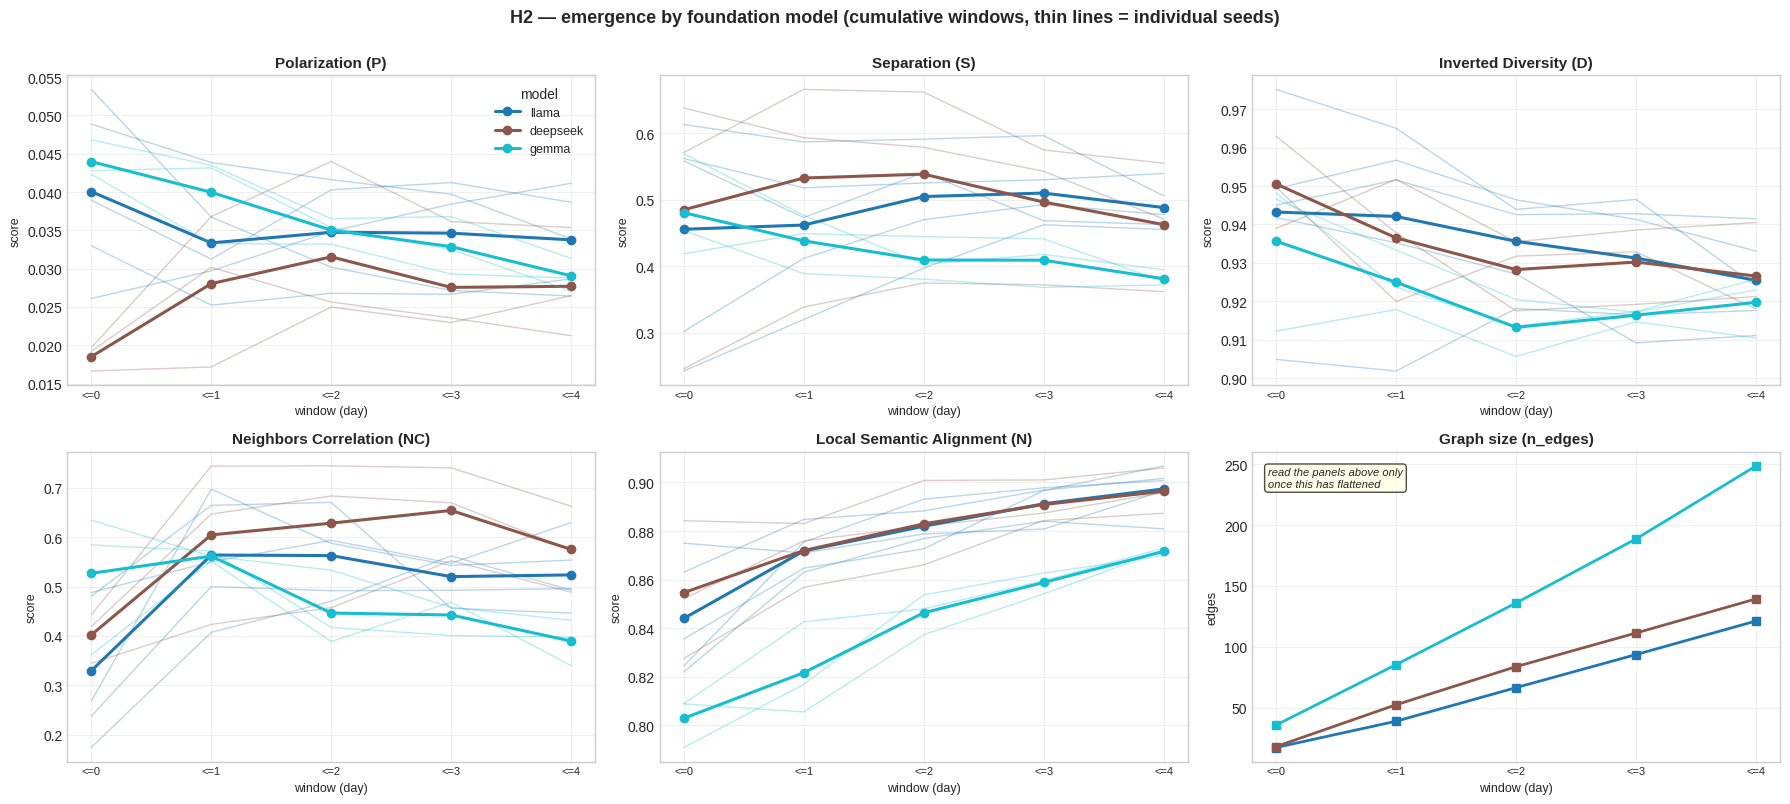


--- Final vs. first usable window, per model ---
          P_polarization  S_separation  D_inverted_diversity  NC_neighbor_correlation   N_nci
model                                                                                        
deepseek          0.0068       -0.2095               -0.0225                   0.2297  0.0784
gemma            -0.0180       -0.0243               -0.0377                  -0.2446  0.0641
llama             0.0003       -0.1505               -0.0421                   0.4557  0.0848

A positive delta means the component grew over the run. Comparing deltas rather
than end-states separates 'started high' from 'developed', which the run-level
analysis cannot distinguish.

=== H3: emergence of model-identity clustering ===


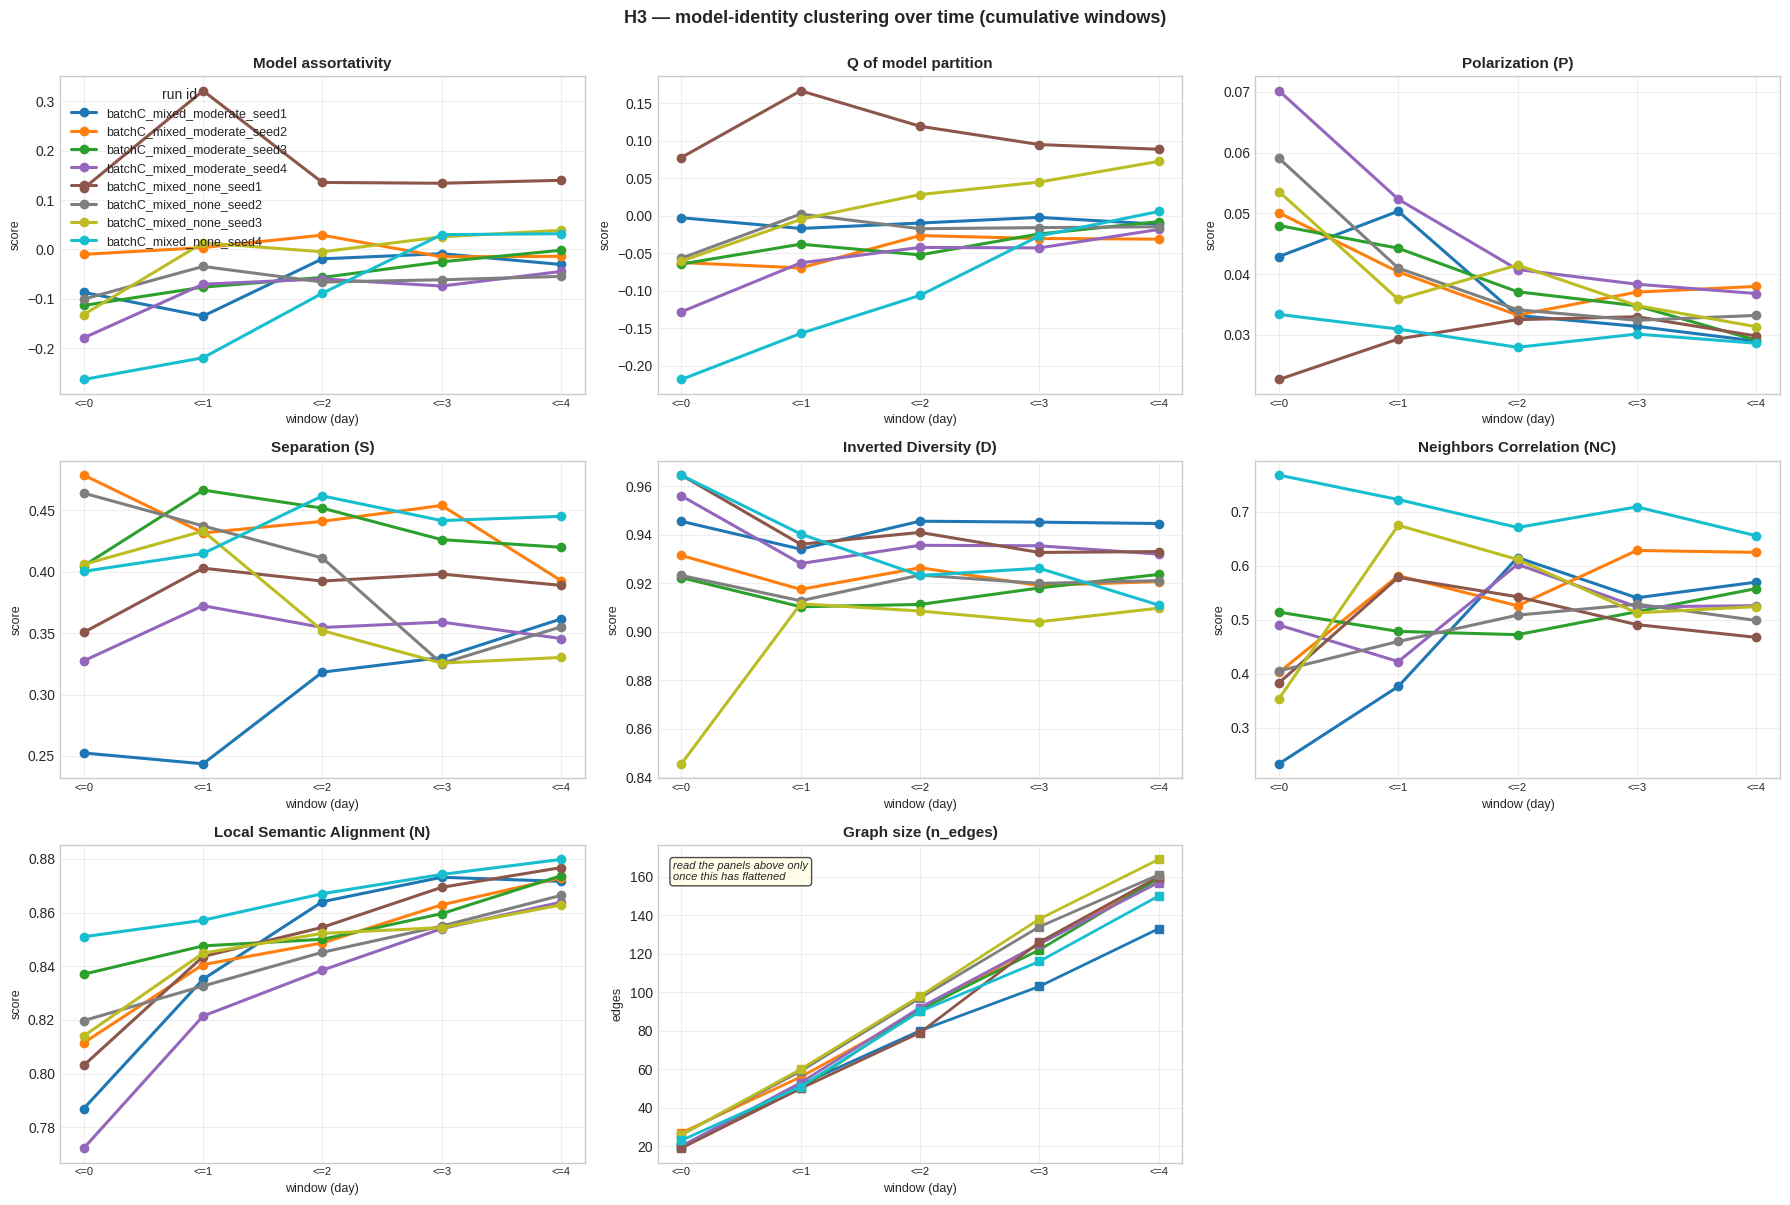

                     run_id window  n_agents_active  n_edges  model_assortativity  Q_model_partition
    batchC_mixed_none_seed1    <=0               32       19                0.124              0.078
    batchC_mixed_none_seed1    <=1               52       50                0.321              0.166
    batchC_mixed_none_seed1    <=2               65       79                0.136              0.119
    batchC_mixed_none_seed1    <=3               79      126                0.134              0.095
    batchC_mixed_none_seed1    <=4               85      160                0.140              0.088
    batchC_mixed_none_seed2    <=0               33       26               -0.101             -0.057
    batchC_mixed_none_seed2    <=1               57       59               -0.034              0.002
    batchC_mixed_none_seed2    <=2               76       97               -0.066             -0.017
    batchC_mixed_none_seed2    <=3               81      134               -0.061          

In [ ]:
def plot_trajectories(traj, group_col, group_order, title, out_path,
                       metrics=None, show_counts=True):
    """One panel per component; one line per group, with individual seeds as thin lines.

    Below-threshold windows are left as gaps rather than interpolated, so a broken line
    marks where the underlying graph was too small to support the metric.
    """
    metrics = metrics or COMPONENTS
    present_groups = [g for g in group_order if (traj[group_col] == g).any()]
    n_panels = len(metrics) + (1 if show_counts else 0)
    ncols = 3 if n_panels > 4 else 2
    nrows = int(np.ceil(n_panels / ncols))

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 4.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(present_groups), 3)))
    window_order = list(dict.fromkeys(traj.sort_values('day_hi')['window']))
    xpos = {w: i for i, w in enumerate(window_order)}

    for ax, metric in zip(axes, metrics):
        for gi, grp in enumerate(present_groups):
            sub = traj[traj[group_col] == grp]
            for run_id, run_sub in sub.groupby('run_id'):
                run_sub = run_sub.sort_values('day_hi')
                ax.plot([xpos[w] for w in run_sub['window']], run_sub[metric],
                        color=colors[gi], alpha=0.30, linewidth=1)
            means = sub.groupby('window')[metric].mean().reindex(window_order)
            ax.plot(range(len(window_order)), means.values, color=colors[gi],
                    marker='o', linewidth=2.2, label=str(grp))
        ax.set_title(COMPONENT_LABELS.get(metric, metric), fontsize=11, fontweight='bold')
        ax.set_xticks(range(len(window_order)))
        ax.set_xticklabels(window_order, fontsize=8)
        ax.set_xlabel('window (day)', fontsize=9)
        ax.set_ylabel('score', fontsize=9)
        ax.grid(alpha=0.3)

    if show_counts:
        ax = axes[len(metrics)]
        for gi, grp in enumerate(present_groups):
            sub = traj[traj[group_col] == grp]
            means = sub.groupby('window')['n_edges'].mean().reindex(window_order)
            ax.plot(range(len(window_order)), means.values, color=colors[gi],
                    marker='s', linewidth=2, label=str(grp))
        ax.set_title('Graph size (n_edges)', fontsize=11, fontweight='bold')
        ax.set_xticks(range(len(window_order)))
        ax.set_xticklabels(window_order, fontsize=8)
        ax.set_xlabel('window (day)', fontsize=9)
        ax.set_ylabel('edges', fontsize=9)
        ax.grid(alpha=0.3)
        ax.text(0.03, 0.95, 'read the panels above only\nonce this has flattened',
                transform=ax.transAxes, fontsize=8, va='top', style='italic',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

    for extra in axes[n_panels:]:
        extra.axis('off')
    axes[0].legend(fontsize=9, title=group_col.replace('_', ' '))
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()


# ---------------------------------------------------------------- H2
h2_ids = [r['run_id'] for r in H2_RUNS]
h2_traj = trajectories[trajectories['run_id'].isin(h2_ids)]
if len(h2_traj):
    print("=== H2: component trajectories by model ===")
    plot_trajectories(h2_traj, 'model', MODEL_ORDER,
                       f"H2 — emergence by foundation model ({WINDOW_MODE} windows, "
                       f"thin lines = individual seeds)",
                       SAVE_DIR / 'h2_trajectories.png')
    h2_traj.to_csv(SAVE_DIR / 'h2_trajectories.csv', index=False)

    print("\n--- Final vs. first usable window, per model ---")
    usable = h2_traj[~h2_traj['below_threshold']]
    if len(usable):
        first_w = usable.sort_values('day_hi').groupby('model').head(1)
        last_w = usable.sort_values('day_hi').groupby('model').tail(1)
        delta = (last_w.groupby('model')[COMPONENTS].mean()
                 - first_w.groupby('model')[COMPONENTS].mean())
        print(delta.round(4).to_string())
        print("\nA positive delta means the component grew over the run. Comparing deltas rather")
        print("than end-states separates 'started high' from 'developed', which the run-level")
        print("analysis cannot distinguish.")

# ---------------------------------------------------------------- H3
h3_ids = [r['run_id'] for r in H3_RUNS]
h3_traj = trajectories[trajectories['run_id'].isin(h3_ids)]
if len(h3_traj) and 'model_assortativity' in h3_traj.columns:
    print("\n=== H3: emergence of model-identity clustering ===")
    h3_metrics = [m for m in ['model_assortativity', 'Q_model_partition'] if m in h3_traj.columns]
    labels_backup = dict(COMPONENT_LABELS)
    COMPONENT_LABELS.setdefault('model_assortativity', 'Model assortativity')
    COMPONENT_LABELS.setdefault('Q_model_partition', 'Q of model partition')

    plot_trajectories(h3_traj, 'run_id', sorted(h3_traj['run_id'].unique()),
                       f"H3 — model-identity clustering over time ({WINDOW_MODE} windows)",
                       SAVE_DIR / 'h3_trajectories.png',
                       metrics=h3_metrics + COMPONENTS)
    h3_traj.to_csv(SAVE_DIR / 'h3_trajectories.csv', index=False)

    print(h3_traj[['run_id', 'window', 'n_agents_active', 'n_edges',
                    'model_assortativity', 'Q_model_partition']].round(3).to_string(index=False))
    print("\nThe question this answers: is model assortativity present from the first window, or")
    print("does it build? Present from the start suggests it reflects who was seeded where;")
    print("building over time suggests interaction dynamics are sorting agents by model.")
    print("Neither reading is available from the end-state value alone.")


=== Exporting networks for report figures ===
  batchA_none_seed1            79 nodes,   114 edges -> network.graphml + nodes.csv
  batchA_moderate_seed5        81 nodes,   103 edges -> network.graphml + nodes.csv
  batchA_extreme_seed1         87 nodes,   144 edges -> network.graphml + nodes.csv
  batchA_extreme_seed2         85 nodes,   173 edges -> network.graphml + nodes.csv
  batchA_extreme_seed3         77 nodes,   103 edges -> network.graphml + nodes.csv
  batchA_extreme_seed4         89 nodes,   128 edges -> network.graphml + nodes.csv
  batchA_extreme_seed5         83 nodes,    93 edges -> network.graphml + nodes.csv
  batchB_gemma_seed1           90 nodes,   267 edges -> network.graphml + nodes.csv
  batchB_gemma_seed2           91 nodes,   265 edges -> network.graphml + nodes.csv
  batchB_gemma_seed3           92 nodes,   214 edges -> network.graphml + nodes.csv
  batchB_deepseek_seed1        83 nodes,   135 edges -> network.graphml + nodes.csv
  batchA_none_seed2           

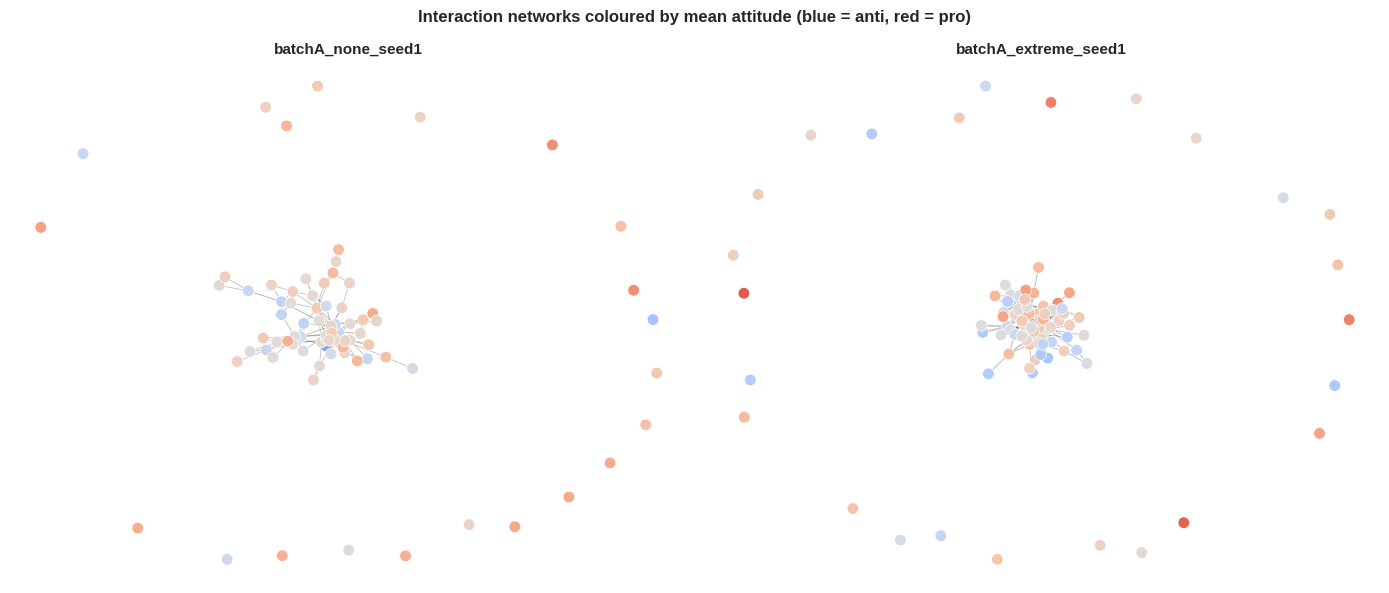


draw_network(run_id, color_by=...) redraws any run; try color_by='model' for H3,
or color_by='community' for the Louvain partition.


In [ ]:
## Network export for figures

def _graphml_safe(value):
    """GraphML cannot store None, NaN, or numpy scalar types. Convert or drop."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return None
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    return str(value)


def export_network(run_id, result, merged=None, save_dir=SAVE_DIR, layout_seed=42):
    """Writes the interaction graph in a form the report figures can be built from:

      <run>/network.graphml  weighted graph with node attributes, opens in Gephi/Cytoscape
      <run>/nodes.csv        one row per agent: attributes plus x/y layout coordinates
      <run>/edges.csv        already written by save_run_outputs (weighted)

    The layout is computed once with a fixed seed and SAVED, so every figure drawn from
    this run places nodes identically. Recomputing a spring layout per figure would move
    the nodes each time and make two panels of the same network look like two networks.
    """
    run_dir = Path(save_dir) / run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    G = result['G_undirected'].copy()
    ua = result['user_attitudes'].set_index('user_id')

    attrs = ['mean_attitude', 'num_posts', 'community', 'neighborhood_diversity', 'NCI', 'model']
    for node in G.nodes():
        key = node if node in ua.index else str(node)
        for a in attrs:
            if a in ua.columns and key in ua.index:
                val = _graphml_safe(ua.loc[key, a])
                if val is not None:
                    G.nodes[node][a] = val
        G.nodes[node]['degree'] = int(G.degree(node))
        G.nodes[node]['weighted_degree'] = float(G.degree(node, weight='weight'))

    if merged is not None:
        lookup = merged.set_index('agent_key')
        for node in G.nodes():
            k = str(node)
            if k in lookup.index:
                for field in ['model', 'leaning', 'is_page']:
                    if field in lookup.columns:
                        val = _graphml_safe(lookup.loc[k, field])
                        if val is not None:
                            G.nodes[node][field] = val

    # fixed layout, computed once and persisted
    pos = nx.spring_layout(canonicalize_graph(G), seed=layout_seed, weight='weight')

    nx.write_graphml(G, run_dir / 'network.graphml')

    node_rows = []
    for node in G.nodes():
        row = {'node_id': node, 'x': float(pos[node][0]), 'y': float(pos[node][1])}
        row.update(dict(G.nodes[node]))
        node_rows.append(row)
    pd.DataFrame(node_rows).to_csv(run_dir / 'nodes.csv', index=False)
    return run_dir


print("=== Exporting networks for report figures ===")
for cfg in ALL_RUN_CONFIGS:
    run_id = cfg['run_id']
    merged = h3_merged.get(run_id) if 'h3_merged' in dir() else None
    d = export_network(run_id, analysis_results[run_id], merged=merged)
    G = analysis_results[run_id]['G_undirected']
    print(f"  {run_id:26s} {G.number_of_nodes():4d} nodes, {G.number_of_edges():5d} edges "
          f"-> network.graphml + nodes.csv")

print(f"\nEach run folder under {SAVE_DIR} now holds network.graphml, nodes.csv and edges.csv.")
print("nodes.csv carries a fixed x/y layout so repeated figures of the same run are identical.")


# ------------------------------------------------------------------ example figure
def draw_network(run_id, color_by='mean_attitude', save_dir=SAVE_DIR, ax=None, title=None):
    """Draws one run using the SAVED layout. `color_by` is any column in nodes.csv --
    'mean_attitude' for the opinion map, 'model' for the H3 model map, 'community' for
    the Louvain partition."""
    run_dir = Path(save_dir) / run_id
    nodes = pd.read_csv(run_dir / 'nodes.csv')
    edges = pd.read_csv(run_dir / 'edges.csv')
    G = nx.from_pandas_edgelist(edges.astype({'source': str, 'target': str}),
                                 'source', 'target', edge_attr='weight')
    pos = {str(r['node_id']): (r['x'], r['y']) for _, r in nodes.iterrows()}
    G.add_nodes_from([n for n in pos if n not in G])

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 6))

    if color_by in nodes.columns and nodes[color_by].dtype == object:
        cats = sorted(nodes[color_by].dropna().unique())
        cmap = {c: plt.cm.tab10(i % 10) for i, c in enumerate(cats)}
        colors = [cmap.get(nodes.set_index('node_id')[color_by].get(
            int(n) if n.lstrip('-').isdigit() else n), (0.6, 0.6, 0.6, 1)) for n in G.nodes()]
        for c in cats:
            ax.scatter([], [], color=cmap[c], label=str(c))
        ax.legend(fontsize=8, title=color_by)
    else:
        lookup = nodes.set_index('node_id')[color_by] if color_by in nodes.columns else None
        colors = [lookup.get(int(n) if n.lstrip('-').isdigit() else n, 0.0)
                  if lookup is not None else 0.0 for n in G.nodes()]

    weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25,
                            width=[0.4 + 2.0 * w / max_w for w in weights])
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=70,
                            cmap='coolwarm' if not isinstance(colors[0], tuple) else None,
                            vmin=-1 if color_by == 'mean_attitude' else None,
                            vmax=1 if color_by == 'mean_attitude' else None,
                            edgecolors='white', linewidths=0.5)
    ax.set_title(title or f"{run_id} — coloured by {color_by}", fontsize=11, fontweight='bold')
    ax.axis('off')
    if own_fig:
        plt.tight_layout()
        plt.savefig(Path(save_dir) / f'network_{run_id}_{color_by}.png', dpi=150,
                    bbox_inches='tight')
        plt.show()


_demo = [c['run_id'] for c in ALL_RUN_CONFIGS if c['stance_condition'] in ('none', 'extreme')
         and c['seed'] == 1][:2]
if _demo:
    fig, axes = plt.subplots(1, len(_demo), figsize=(7 * len(_demo), 6))
    for ax, rid in zip(np.atleast_1d(axes), _demo):
        draw_network(rid, 'mean_attitude', ax=ax, title=rid)
    plt.suptitle('Interaction networks coloured by mean attitude (blue = anti, red = pro)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SAVE_DIR / 'network_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\ndraw_network(run_id, color_by=...) redraws any run; try color_by='model' for H3,")
    print("or color_by='community' for the Louvain partition.")


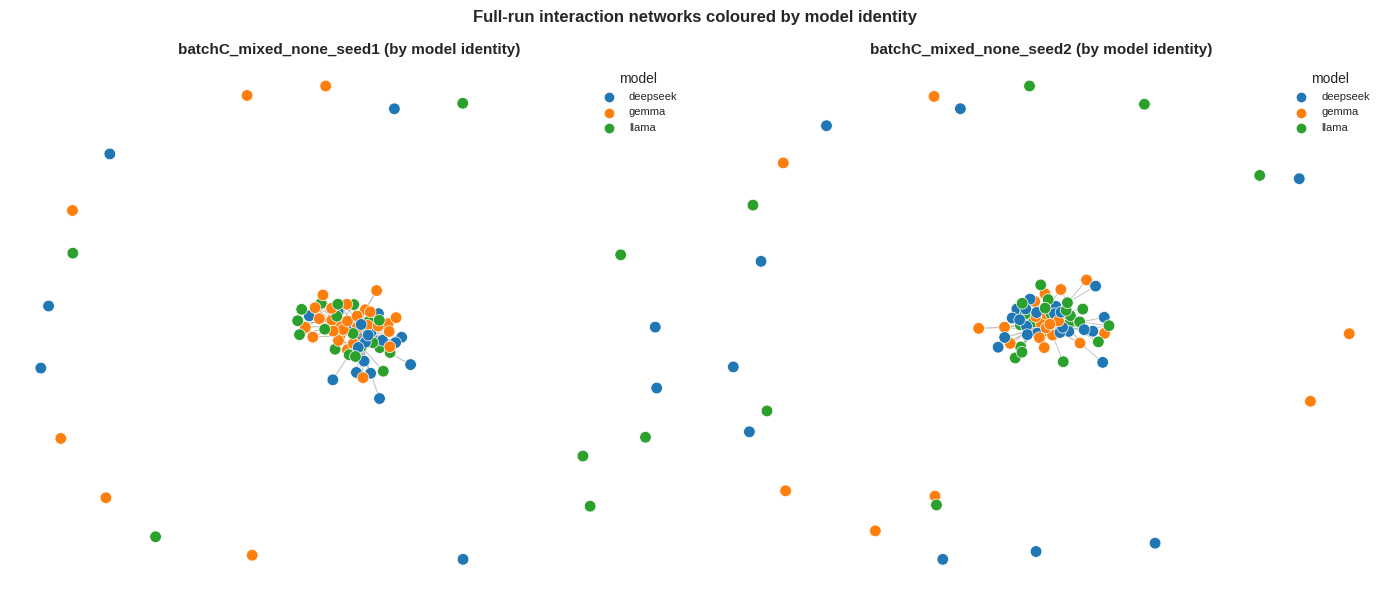

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

draw_network('batchC_mixed_none_seed1', color_by='model', ax=axes[0], title='batchC_mixed_none_seed1 (by model identity)')
draw_network('batchC_mixed_none_seed2', color_by='model', ax=axes[1], title='batchC_mixed_none_seed2 (by model identity)')

plt.suptitle('Full-run interaction networks coloured by model identity', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'network_h3_comparison_by_model.png', dpi=150, bbox_inches='tight')
plt.show()

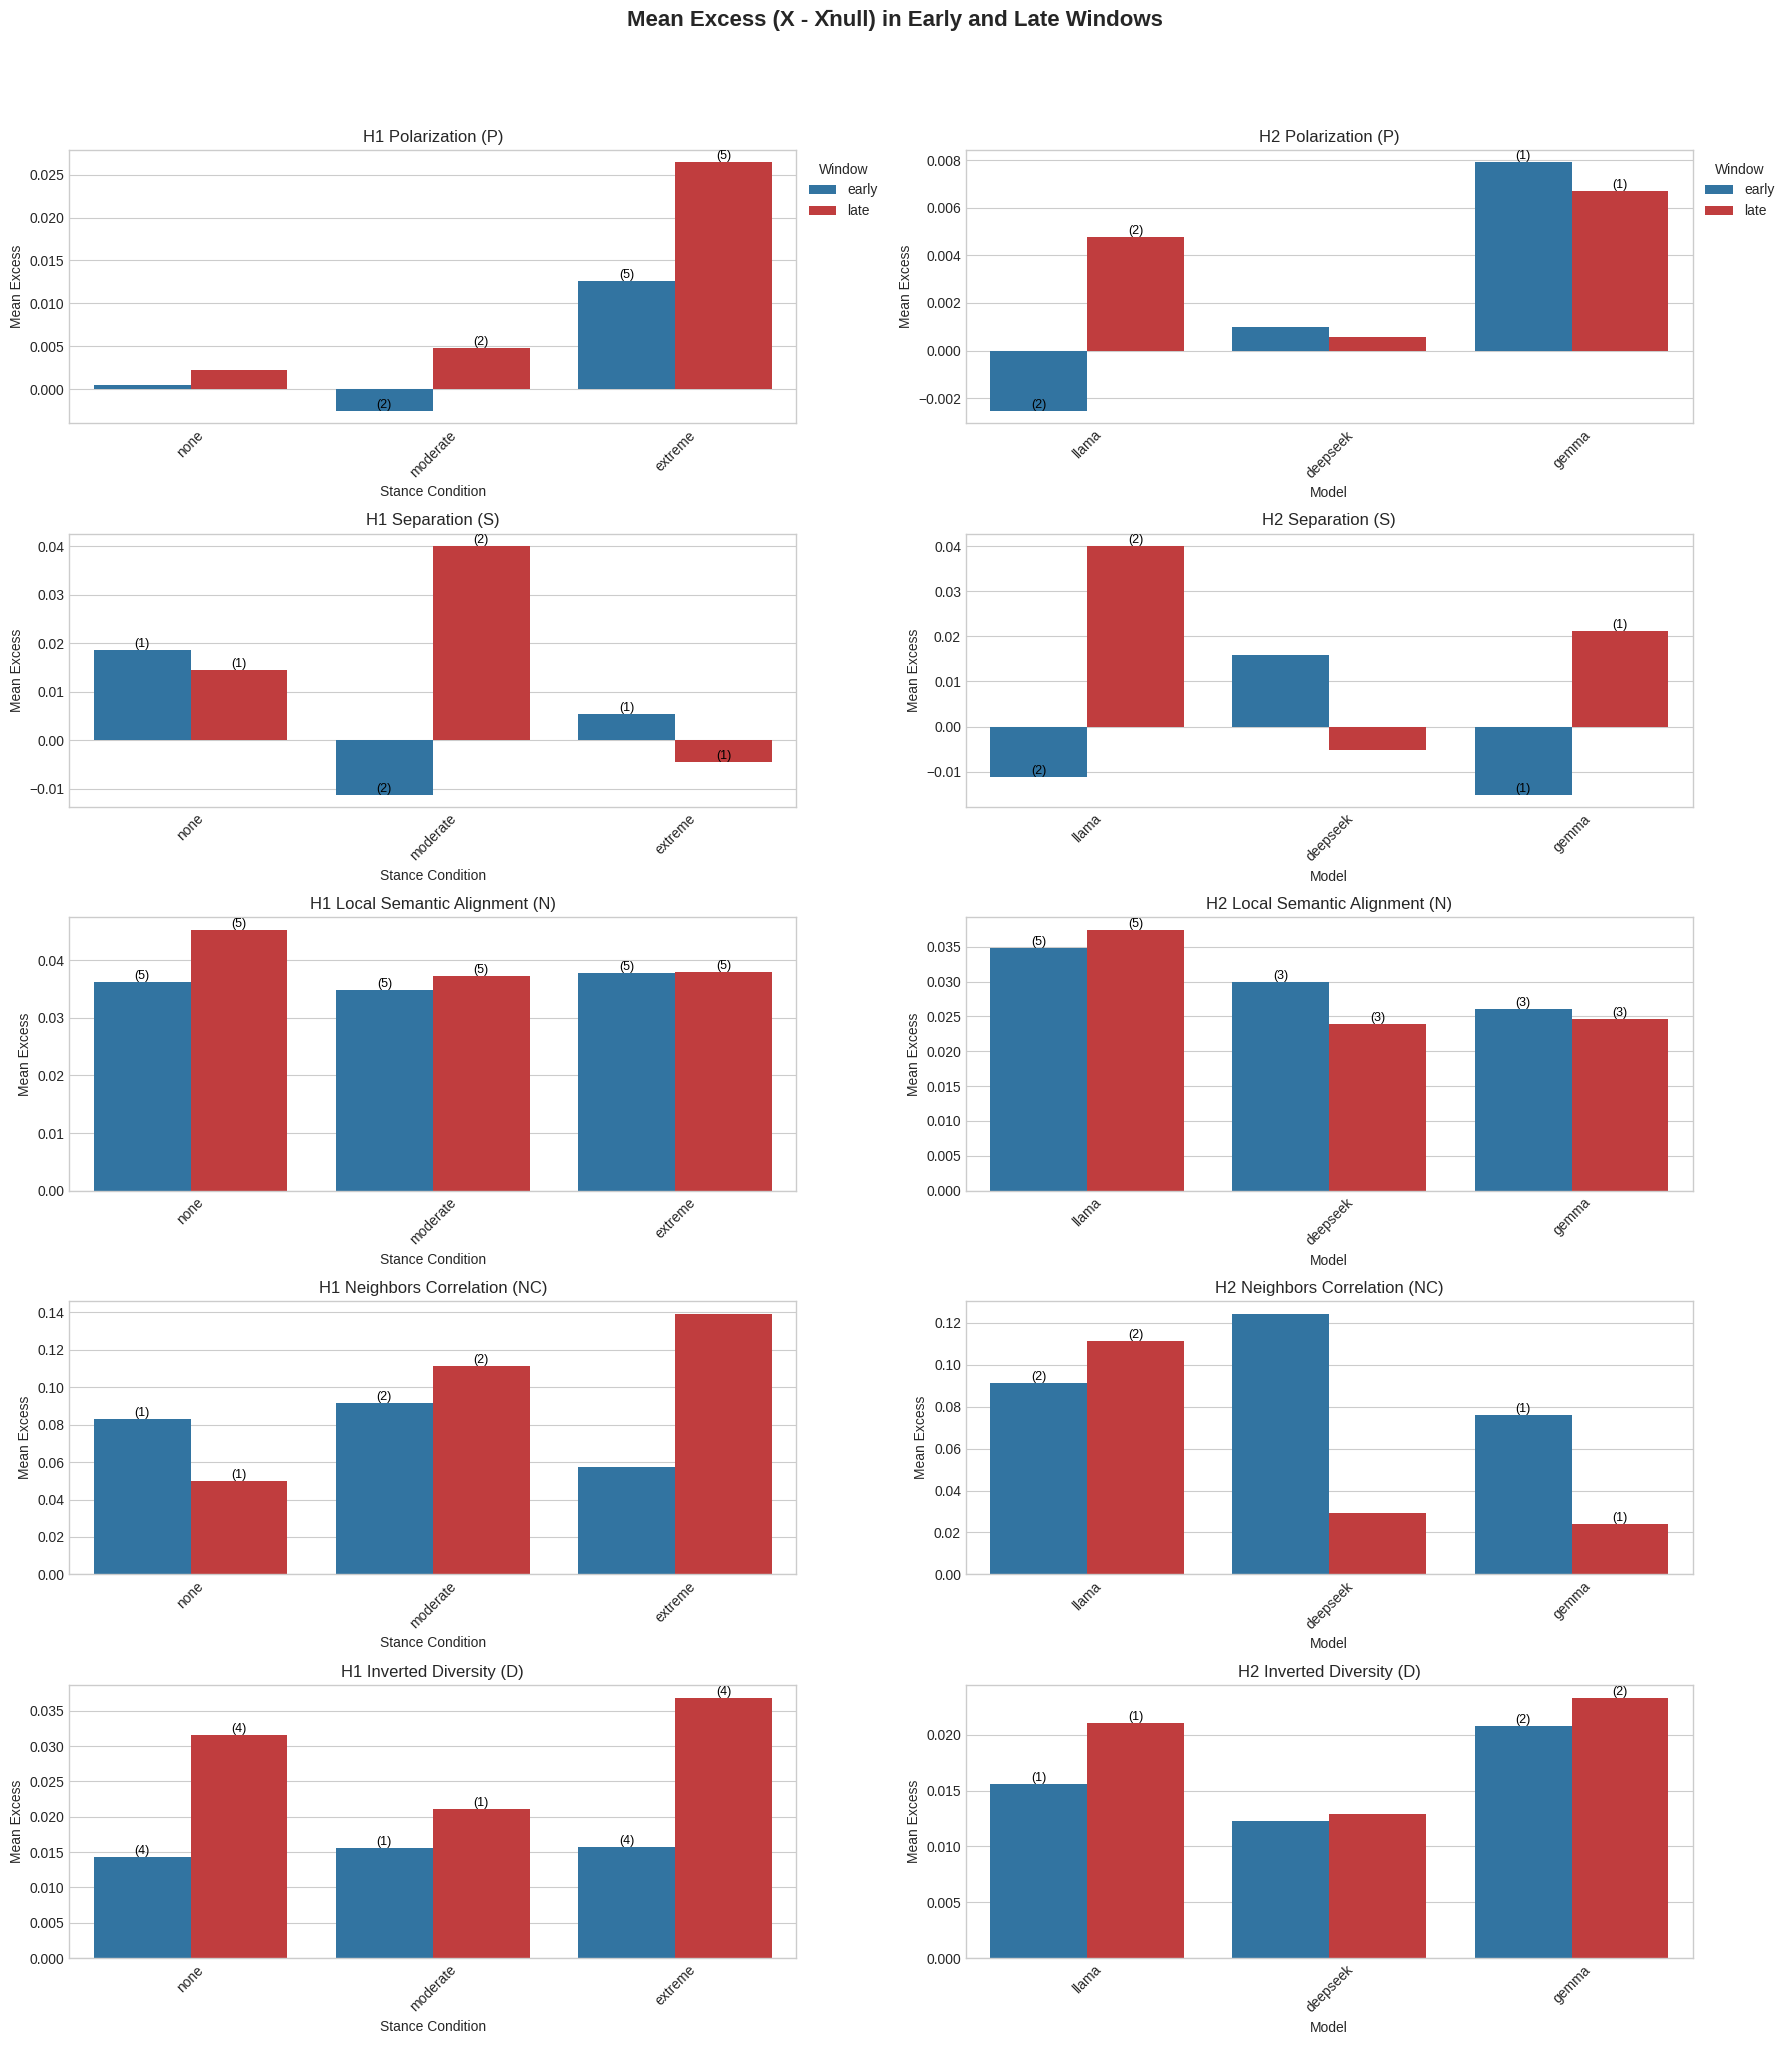

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for H1 (stance conditions)
h1_plot_data = h1_existence[h1_existence['window'].isin(PRIMARY_WINDOWS)].copy()
h1_plot_data['group'] = h1_plot_data['stance_condition']
h1_plot_data['group_type'] = 'H1 Stance Condition'

# Prepare data for H2 (models)
h2_plot_data = h2_existence[h2_existence['window'].isin(PRIMARY_WINDOWS)].copy()
h2_plot_data['group'] = h2_plot_data['model']
h2_plot_data['group_type'] = 'H2 Model'

# Combine data
plot_data = pd.concat([h1_plot_data, h2_plot_data], ignore_index=True)

# Define plot components and order
plot_components = ['P', 'S', 'N', 'NC', 'D']
window_order = ['early', 'late']
h1_group_order = ['none', 'moderate', 'extreme']
h2_group_order = MODEL_ORDER

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(len(plot_components), 2, figsize=(18, 4 * len(plot_components)), sharey=False)
fig.suptitle('Mean Excess (X - X̄null) in Early and Late Windows', fontsize=16, fontweight='bold', y=1.02)

for i, component_short in enumerate(plot_components):
    component_full = [c for c, s in COMPONENT_SHORT.items() if s == component_short][0]
    row_axes = axes[i]

    # H1 plot
    h1_comp_data = plot_data[(plot_data['component'] == component_short) & (plot_data['group_type'] == 'H1 Stance Condition')]
    sns.barplot(data=h1_comp_data, x='group', y='mean_excess', hue='window', ax=row_axes[0], palette={'early': 'tab:blue', 'late': 'tab:red'}, order=h1_group_order, hue_order=window_order, errorbar=None)
    row_axes[0].set_title(f'H1 {COMPONENT_LABELS[component_full]}', fontsize=12)
    row_axes[0].set_xlabel('Stance Condition')
    row_axes[0].set_ylabel('Mean Excess')
    row_axes[0].tick_params(axis='x', rotation=45)

    # Annotate H1 bars with n_runs_p<0.05
    for container in row_axes[0].containers:
        for bar in container:
            group = bar.get_x() + bar.get_width() / 2
            # Map bar position back to x-axis labels
            group_name = h1_group_order[int(round(group))]
            window_name = 'early' if bar.get_facecolor() == tuple(plt.cm.tab10(0)) else 'late'

            n_sig = h1_comp_data[(h1_comp_data['group'] == group_name) & (h1_comp_data['window'] == window_name)]['n_runs_p<0.05'].iloc[0]
            if n_sig > 0:
                row_axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                                  f'({int(n_sig)})', ha='center', va='bottom', fontsize=9, color='black')

    # H2 plot
    h2_comp_data = plot_data[(plot_data['component'] == component_short) & (plot_data['group_type'] == 'H2 Model')]
    sns.barplot(data=h2_comp_data, x='group', y='mean_excess', hue='window', ax=row_axes[1], palette={'early': 'tab:blue', 'late': 'tab:red'}, order=h2_group_order, hue_order=window_order, errorbar=None)
    row_axes[1].set_title(f'H2 {COMPONENT_LABELS[component_full]}', fontsize=12)
    row_axes[1].set_xlabel('Model')
    row_axes[1].set_ylabel('Mean Excess')
    row_axes[1].tick_params(axis='x', rotation=45)

    # Annotate H2 bars with n_runs_p<0.05
    for container in row_axes[1].containers:
        for bar in container:
            group = bar.get_x() + bar.get_width() / 2
            group_name = h2_group_order[int(round(group))]
            window_name = 'early' if bar.get_facecolor() == tuple(plt.cm.tab10(0)) else 'late'

            n_sig = h2_comp_data[(h2_comp_data['group'] == group_name) & (h2_comp_data['window'] == window_name)]['n_runs_p<0.05'].iloc[0]
            if n_sig > 0:
                row_axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                                  f'({int(n_sig)})', ha='center', va='bottom', fontsize=9, color='black')

    # Remove duplicate legends
    if i > 0:
        row_axes[0].legend().remove()
        row_axes[1].legend().remove()
    else:
        row_axes[0].legend(title='Window', loc='upper left', bbox_to_anchor=(1, 1))
        row_axes[1].legend(title='Window', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig(SAVE_DIR / 'mean_excess_over_null_comparison.png', dpi=150, bbox_inches='tight')
plt.show()